# Developed CNN Architecture (No Improving CNN Architecture + Bicubic Grayscale PNG + 5-Fold))

### 1.1 Libraries

In [1]:
%%time

import os
import pickle
import shutil
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Importar librerias de tensorflow
import tensorflow as tf
from tensorflow.keras.models import load_model
#from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

2025-05-28 03:31:33.218044: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-28 03:31:33.367006: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-28 03:31:33.367102: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-28 03:31:33.371080: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-28 03:31:33.391679: I tensorflow/core/platform/cpu_feature_guar

CPU times: user 12.5 s, sys: 3.88 s, total: 16.4 s
Wall time: 10.4 s


In [2]:
!nvidia-smi

Wed May 28 03:31:40 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.107.02             Driver Version: 550.107.02     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5500               Off |   00000000:1D:00.0 Off |                  Off |
| 30%   35C    P8             22W /  230W |       4MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
print(tf.config.experimental.get_visible_devices())


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 1.2. Sound and Source

In [4]:
from IPython.display import Audio
import time

def sound():
    beep_07a_path = '/notebooks/beep-07a.wav'
    beep_08b_path = '/notebooks/beep-08b.wav'

    for _ in range(2):
        sound_beep_07a = Audio(beep_07a_path, autoplay=True)
        display(sound_beep_07a)
        time.sleep(0.3)
        sound_beep_08b = Audio(beep_08b_path, autoplay=True)
        display(sound_beep_08b)
        time.sleep(0.3)
sound()

### 1.3. Create a dictionary to store samples by malware families

In [5]:
source = '/notebooks/train3/'
# Inicializar un diccionario para almacenar la cantidad de muestras por familia
malware_families_train, malware_families_valid, malware_families_test, malware_families = {}, {}, {}, {}
train_data_dir = os.path.join(source, 'centum_1500/train/')
valid_data_dir = os.path.join(source, 'centum_1500/valid/')
test_data_dir = os.path.join(source, 'centum_1500/test/')
# Recorrer los directorios de las familias de malware
for familia in os.listdir(train_data_dir):
    # Comprobar si es un directorio
    if os.path.isdir(os.path.join(train_data_dir, familia)):
        # Contar la cantidad de archivos en el directorio de la familia
        cantidad_muestras_train = len(os.listdir(os.path.join(train_data_dir, familia)))
        cantidad_muestras_valid = len(os.listdir(os.path.join(valid_data_dir, familia)))
        cantidad_muestras_test = len(os.listdir(os.path.join(test_data_dir, familia)))
        # Agregar la cantidad al diccionario con el nombre de la familia como clave
        malware_families_train[familia] = cantidad_muestras_train
        malware_families_valid[familia] = cantidad_muestras_valid
        malware_families_test[familia] = cantidad_muestras_test

for d in (malware_families_train, malware_families_valid, malware_families_test):
    for key, value in d.items():
        if key in malware_families:
            malware_families[key] += value
        else:
            malware_families[key] = value

# Ordenar las familias de mayor a menor según la cantidad de muestras
sorted_families = sorted(malware_families.items(), key=lambda x: x[1], reverse=True)
# Imprimir el diccionario resultante
sorted_families

[('sfone', 1500),
 ('sillyp2p', 1500),
 ('Allaple.A', 1500),
 ('Ramnit', 1500),
 ('wabot', 1500),
 ('mira', 1500),
 ('Kelihos_ver3', 1500),
 ('ganelp', 1500),
 ('Allaple.L', 1500),
 ('wacatac', 1500),
 ('dinwod', 1500),
 ('Lollipop', 1500),
 ('berbew', 1500),
 ('small', 1500),
 ('upatre', 1500)]

### 1.3. Create a dictionary to store samples by malware families

In [6]:
%%time

def copy_malware_families(source, num_experiments, sorted_families):
    
    # Crea el directorio que contendrá el malware
    experiment_dir = os.path.join(source, "all_malware", str(num_experiments))
    os.makedirs(experiment_dir, exist_ok=True)

    # Ordenar las familias de mayor a menor según la cantidad de muestras
    #sorted_families = sorted(malware_families.items(), key=lambda x: x[1], reverse=True)

    # Crear directorios train, test, y valid del experimento
    for data_type in ['train', 'test', 'valid']:
        data_dir = os.path.join(experiment_dir, data_type)
        os.makedirs(data_dir, exist_ok=True)
        
        # Copiar las familias correspondientes
        for j in range(num_experiments):
            family_name, num_samples = sorted_families[j]
            family_dir = os.path.join(data_dir, family_name)
            os.makedirs(family_dir, exist_ok=True)
            source_dir = os.path.join(source, 'centum_1500', data_type, family_name)
            
            # Copiar las num_samples muestras de cada familia
            for filename in os.listdir(source_dir)[:num_samples]:
                source_path = os.path.join(source_dir, filename)
                dest_path = os.path.join(family_dir, filename)
                shutil.copy(source_path, dest_path)
    print("Familias de malware copiadas")
    #sound()

def delete_experiment_dir(source, num_experiments):
    experiment_dir = os.path.join(source, "all_malware", str(num_experiments))
    shutil.rmtree(experiment_dir)
    print(f"La carpeta {str(num_experiments)} fue eliminada.")

CPU times: user 0 ns, sys: 17 µs, total: 17 µs
Wall time: 27.9 µs


## 2. Convolutional Neural Network Decay Evaluation Metrics by Increase in Malware Families

### 2.1. Calculate Weights by Class

In [7]:
%%time

def weights_by_class(train_generator):
    # Calculate class weights using compute_class_weight
    class_weights = compute_class_weight(class_weight = 'balanced',
                         classes = np.unique(train_generator.classes), 
                         y = train_generator.classes)
    # Create a dictionary of class weights
    class_weight_dict = dict(enumerate(class_weights))
    # Print class weights
    print("Class Weights:", class_weight_dict)
    return class_weight_dict

CPU times: user 31 µs, sys: 9 µs, total: 40 µs
Wall time: 71.8 µs


### 2.2. Image generator (Training, validation, and testing)

In [8]:
%%time

def data_gen(source_cnn, train_data_dir, validation_data_dir, test_data_dir):
    # Settings for Data Generator
    train_datagen = ImageDataGenerator(rescale=1./255)
    validation_datagen = ImageDataGenerator(rescale=1./255)
    test_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(
            train_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')

    validation_generator = validation_datagen.flow_from_directory(
            validation_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')

    test_generator = test_datagen.flow_from_directory(
            test_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')
    return (train_generator, validation_generator, test_generator)

CPU times: user 6 µs, sys: 0 ns, total: 6 µs
Wall time: 11.4 µs


### 2.3. Creation of the Model Based on the Architecture
Descongelamos 5 capas de MobileNet para esta versión, pero para más adelante, version optimizada,podemos desconger 10 capas.

In [9]:
%%time

def new_model(num_classes):
    # Use MobileNet architecture with imagenet weights by transfer Learning 
    base_model = MobileNet(weights='imagenet',
                           include_top=False,
                           input_shape=(img_width, img_height, 3))

    # Freeze the convolutional layers of the pretrained model
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze the last 10 layers of the MobileNet base model
    for layer in base_model.layers[-5:]:
        layer.trainable = True

    # Malware classification head
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    #x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x) # Probar con 0.5 si no mejora los resultados
    x = layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)  # Nueva capa adicional
    x = Dropout(0.3)(x) # Nueva capa adicional
    predictions = layers.Dense(num_classes, activation='softmax')(x)

    # Combining the pretrained model with the malware classification layer
    model = models.Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with an optimizer and learning rate
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    
    # Calculate the total # parameters
    total_params = model.count_params()
    trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable_params = total_params - trainable_params
    # Print request info paramers
    print("Total params: {}".format(total_params))
    print("Trainable params: {}".format(trainable_params))
    print("Non-trainable params: {}".format(non_trainable_params))

    
    return model

CPU times: user 3 µs, sys: 1 µs, total: 4 µs
Wall time: 6.44 µs


### 2.4. Evaluate the model and graphs

#### 2.4.1. Get the accuracy and log loss of the model (Train, Validation and Test)

In [10]:
%%time

def prediction(model, train_generator, validation_generator, test_generator):
    # Obtener la precisión y la pérdida en el conjunto de datos de entrenamiento
    train_loss, train_acc = model.evaluate(train_generator, verbose=1)
    print('Train Accuracy:', train_acc)
    print('Train Log Loss:', train_loss)

    # Obtener la precisión y la pérdida en el conjunto de datos de validación
    val_loss, val_acc = model.evaluate(validation_generator, verbose=1)
    print('Validation Accuracy:', val_acc)
    print('Validation Log Loss:', val_loss)

    # Obtener la precisión y la pérdida en el conjunto de datos de prueba
    test_loss, test_acc = model.evaluate(test_generator, verbose=1)
    print('Test Accuracy:', test_acc)
    print('Test Log Loss:', test_loss)
    
    # Return test_loss and test_acc
    return(test_acc, test_loss)

CPU times: user 11 µs, sys: 0 ns, total: 11 µs
Wall time: 18.1 µs


#### 2.4.2. Precision, Recall, Confusion Matrix and  AUC

In [11]:
%%time

def confu_matrix(model, test_generator):
# Get the total number of samples in the test builder
    total_samples = len(test_generator)
    print(f"Test labels: {test_generator.class_indices}")

    # Get test builder batch size
    batch_size = test_generator.batch_size

    # Create lists to store the actual and predicted labels
    true_labels = []
    predicted_labels = []

    # Iterate over all batches in the test builder
    for batch_index in range(total_samples):
        # Get a batch of data from the test builder
        batch_images, batch_labels = test_generator[batch_index]

        # Make predictions on the current batch
        batch_predictions = model.predict_on_batch(batch_images)

        # Get the actual labels of the current batch
        true_labels.extend(np.argmax(batch_labels, axis=1))

        # Get the predicted labels of the current batch
        predicted_labels.extend(np.argmax(batch_predictions, axis=1))

    # Convert lists of labels to numpy arrays
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)

    # Calculate the confusion matrix
    confusion_mtx = confusion_matrix(true_labels, predicted_labels)

    print("\nMatriz de Confusión:")
    print(confusion_mtx)
    print(f"True labels: {len(true_labels)}")
    print(f"Predicted labels: len(predicted_labels)")

    # Get the classification report
    class_report = classification_report(true_labels, predicted_labels)

    # Print the classification report
    print('\nClassification report:')
    print(class_report)

    # Get the predictions for the test dataset
    y_test_pred = model.predict(test_generator)

    # Get the AUC
    #test_auc = roc_auc_score(true_labels, y_test_pred, multi_class='ovr')
    #print('AUC:', test_auc)
    
    # Normalize the confusion matrix
    cm_norm = confusion_mtx.astype('float') / confusion_mtx.sum(axis=1)[:, np.newaxis]

    # Set up plot with 12x12 inch figure
    plt.figure(figsize=(12, 12))
    sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
    plt.show()
    
    crd = classification_report(true_labels, predicted_labels, output_dict=True)
    
    return crd['macro avg']['precision'], crd['macro avg']['recall'], crd['macro avg']['f1-score']
    

CPU times: user 16 µs, sys: 0 ns, total: 16 µs
Wall time: 19.3 µs


## 3. Decay Evaluation Metrics by Increase in Malware Families

### 3.1. Settings (Configurar)

In [12]:
%%time

# Experiment dir 
source = '/notebooks/train3/'

# Cambiar el nombre del modelo, empieza con ´fusion_'
nombre_modelo = 'fusion_'+'MobileNet_tf_optimized '
save_model = source + 'layer_contribution/MobileNet_tf_optimized /'
os.makedirs(save_model, exist_ok=True)

# Resize all images to 224x224
img_width, img_height = 224, 224

# Configuring the hyperparameters
batch_size = 32
num_epochs = 50
learning_rate = 0.0001
num_folds = 5

test_acc_list_all = []
test_loss_list_all = []
precision_list_all = []
recall_list_all = []
f1_score_list_all = []

sound()

CPU times: user 24.8 ms, sys: 4.41 ms, total: 29.2 ms
Wall time: 1.22 s


In [13]:
%%time

def exp(num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precission_list_all, recall_list_all, f1_score_list_all):
    # Copiar las familias a ser clasificadas
    copy_malware_families(source, num_classes, sorted_families)
    
    ### SETTINGS ###
    source2 = os.path.join(source, 'all_malware',str(num_classes))
    print(f"source2: {source2}")
    name_save_model = nombre_modelo + str(num_classes)
    print(f"name_save_model: {name_save_model}")
    
    train_data_dir = source2 + '/train/'
    validation_data_dir = source2 + '/valid/'
    test_data_dir = source2 + '/test/'

    # Settings for Data Generator
    train_generator, validation_generator, test_generator = data_gen(source2, train_data_dir, 
                                                                     validation_data_dir, test_data_dir)

    # Print the familias to be classified
    print("Lista de clases de malware a ser analizadas:")
    source_dir = os.path.join(source2, 'train/')
    for  dir in os.listdir(source_dir):
        print("- "+dir)

    # Calculate class weights using compute_class_weight
    #class_weight_dict = weights_by_class(train_generator)

    # Callbacks configuration
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=30, restore_best_weights=True)

    # Calculate the callback ReduceLROnPlateau
    reduce_lr = ReduceLROnPlateau(factor=0.2, patience=10, min_lr=1e-6,)

    # Defines the number of folds for cross validation
    num_folds = 5

    # Split the data set into folds
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

    # Lists to store the metrics of each fold
    fold_train_histories, fold_val_histories = [], []
    test_loss_list, test_acc_list = [], []
    precision_list, recall_list, f1_score_list = [], [], []

    for fold_idx, (train_index, val_index) in enumerate(skf.split(train_generator.filenames, train_generator.classes)):
        print('')
        print('=' * 100)
        print(f'TRAINING AND EVALUATING FOLD {fold_idx + 1}/{num_folds}...\n')

        # Create and Compile Xception model with an optimizer and learning rate
        model = new_model(num_classes)

        # Training the malware classification layer with the ReduceLROnPlateau callback
        history_model = model.fit(
            train_generator,
            steps_per_epoch=train_generator.samples // batch_size,
            epochs=num_epochs,
            validation_data=validation_generator,
            validation_steps=validation_generator.samples // batch_size,
            #class_weight=class_weight_dict,
            #verbose=0,
            callbacks=[early_stopping, reduce_lr],
        )

        sound()

        ##### SAVE MODEL, HISTORY AND METRICS #####
        #model.save(save_model+name_save_model+'_'+str(fold_idx + 1)+'.h5')
        # Save history
        with open(save_model+'history_'+name_save_model+'_'+str(fold_idx + 1)+'.pkl', 'wb') as file:
            pickle.dump(history_model.history, file)
        print("Model and History saved...")

        # Store training and validation metrics for this fold
        fold_train_histories.append(history_model.history['accuracy'])
        fold_val_histories.append(history_model.history['val_accuracy'])

        # Store Metrics
        test_acc, test_loss = prediction(model, train_generator, validation_generator, test_generator)
        test_acc_list.append(test_acc)
        test_loss_list.append(test_loss)
        precision, recall, f1_score = confu_matrix(model, test_generator)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_score_list.append(f1_score)

    # Calcula el promedio de las métricas de todos los pliegues
    avg_train_accuracy = sum([max(hist) for hist in fold_train_histories]) / num_folds
    avg_val_accuracy = sum([max(hist) for hist in fold_val_histories]) / num_folds
    # Imprime el promedio de las métricas de entrenamiento y validación
    print(f'Average training accuracy in {num_folds}-fold: {avg_train_accuracy}')
    print(f'Average validation precision in {num_folds}-fold: {avg_val_accuracy}')

    print("/nTest Metrics")
    print(f"test_acc_list: {test_acc_list}")
    print(f'Average Test Accuracy with {num_folds}-fold: {sum(test_acc_list)/len(test_acc_list)}')
    print(f"test_loss_list: {test_loss_list}")
    print(f'Average Test Log Loss with {num_folds}-fold: {sum(test_loss_list)/len(test_loss_list)}')
    print(f'\nPrecision List: {precision_list}')
    print(f'Average Precision List with {num_folds}-fold: {sum(precision_list)/len(precision_list)}')
    print(f'Recall List: {recall_list}')
    print(f'Average Recall List with {num_folds}-fold: {sum(recall_list)/len(recall_list)}')
    print(f'F1 Score List: {f1_score_list}')
    print(f'Average F1 Score List with {num_folds}-fold: {sum(f1_score_list)/len(f1_score_list)}')

    print("\nMetrics List Store")
    test_acc_list_all.append(sum(test_acc_list)/len(test_acc_list))
    print(f'\ntest_acc_list_all = {test_acc_list_all}')
    test_loss_list_all.append(sum(test_loss_list)/len(test_loss_list))
    print(f'test_loss_list_all = {test_loss_list_all}')
    precission_list_all.append(sum(precision_list)/len(precision_list))
    print(f'precision_list_all = {precission_list_all}')
    recall_list_all.append(sum(recall_list)/len(recall_list))
    print(f'recall_list_all = {recall_list_all}')
    f1_score_list_all.append(sum(f1_score_list)/len(f1_score_list))
    print(f'f1_score_list_all = {f1_score_list_all}')

    # Eliminamos el directorio del experimento
    delete_experiment_dir(source, num_classes)

    return test_acc_list_all, test_loss_list_all, precission_list_all, recall_list_all, f1_score_list_all


CPU times: user 61 µs, sys: 19 µs, total: 80 µs
Wall time: 107 µs


## 4. Experiments

Familias de malware copiadas
source2: /notebooks/train3/all_malware/2
name_save_model: fusion_MobileNet_tf_optimized 2
Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p

TRAINING AND EVALUATING FOLD 1/5...



2025-05-28 03:32:07.565801: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22449 MB memory:  -> device: 0, name: NVIDIA RTX A5500, pci bus id: 0000:1d:00.0, compute capability: 8.6


Total params: 3821634
Trainable params: 1644418
Non-trainable params: 2177216
Epoch 1/50


2025-05-28 03:32:20.552204: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-05-28 03:32:26.957035: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f32f1a84210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-05-28 03:32:26.957118: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5500, Compute Capability 8.6
2025-05-28 03:32:26.974350: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748403147.269472     383 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


65/65 [==============================] - 33s 221ms/step - loss: 0.9484 - accuracy: 0.9768 - val_loss: 0.9805 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 2/50
65/65 [==============================] - 11s 168ms/step - loss: 0.8648 - accuracy: 0.9985 - val_loss: 0.8816 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 3/50
65/65 [==============================] - 11s 160ms/step - loss: 0.8411 - accuracy: 0.9995 - val_loss: 0.8369 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 4/50
65/65 [==============================] - 10s 156ms/step - loss: 0.8197 - accuracy: 0.9990 - val_loss: 0.8088 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 5/50
65/65 [==============================] - 11s 163ms/step - loss: 0.7993 - accuracy: 0.9990 - val_loss: 0.7865 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 6/50
65/65 [==============================] - 11s 165ms/step - loss: 0.7761 - accuracy: 1.0000 - val_loss: 0.7645 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 7/50
65/65 [==============================] -

Model and History saved...
66/66 [==============================] - 11s 158ms/step - loss: 0.8797 - accuracy: 0.9995
Train Accuracy: 0.9995238184928894
Train Log Loss: 0.8796998858451843
15/15 [==============================] - 2s 139ms/step - loss: 0.8818 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.8818328380584717
15/15 [==============================] - 2s 144ms/step - loss: 0.8832 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.883240818977356
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450

15/15 [=================

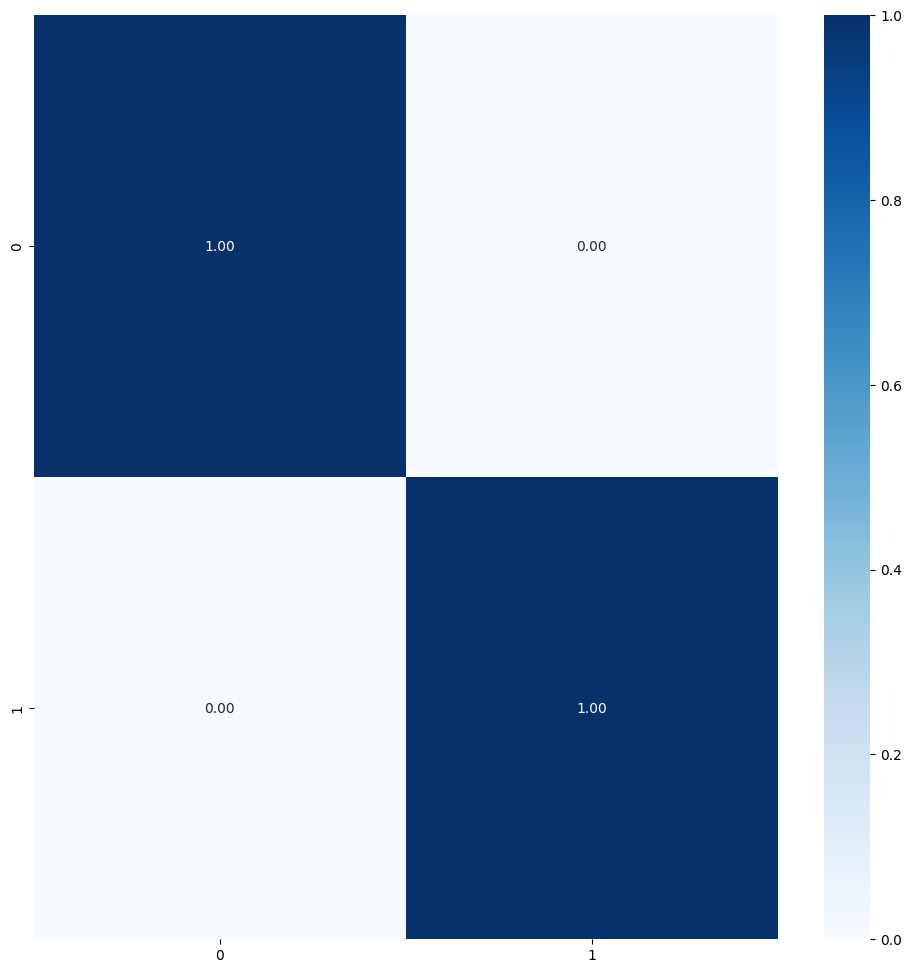


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3821634
Trainable params: 1644418
Non-trainable params: 2177216
Epoch 1/50
65/65 [==============================] - 27s 223ms/step - loss: 0.9256 - accuracy: 0.9797 - val_loss: 0.9468 - val_accuracy: 0.9978 - lr: 1.0000e-04
Epoch 2/50
65/65 [==============================] - 11s 164ms/step - loss: 0.8661 - accuracy: 0.9981 - val_loss: 0.8685 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 3/50
65/65 [==============================] - 12s 181ms/step - loss: 0.8440 - accuracy: 0.9976 - val_loss: 0.8313 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 4/50
65/65 [==============================] - 11s 161ms/step - loss: 0.8191 - accuracy: 0.9995 - val_loss: 0.8075 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 5/50
65/65 [==============================] - 11s 166ms/step - loss: 0.7969 - accuracy: 1.0000 - val_loss: 0.7853 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 6/50
65/65 [==============================] - 10s 162ms/step - loss: 0.7747 - 

Model and History saved...
66/66 [==============================] - 8s 124ms/step - loss: 0.8672 - accuracy: 0.9995
Train Accuracy: 0.9995238184928894
Train Log Loss: 0.8672175407409668
15/15 [==============================] - 2s 119ms/step - loss: 0.8685 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.8684623837471008
15/15 [==============================] - 2s 118ms/step - loss: 0.8712 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.8711802363395691
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[224   1]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450

15/15 [==

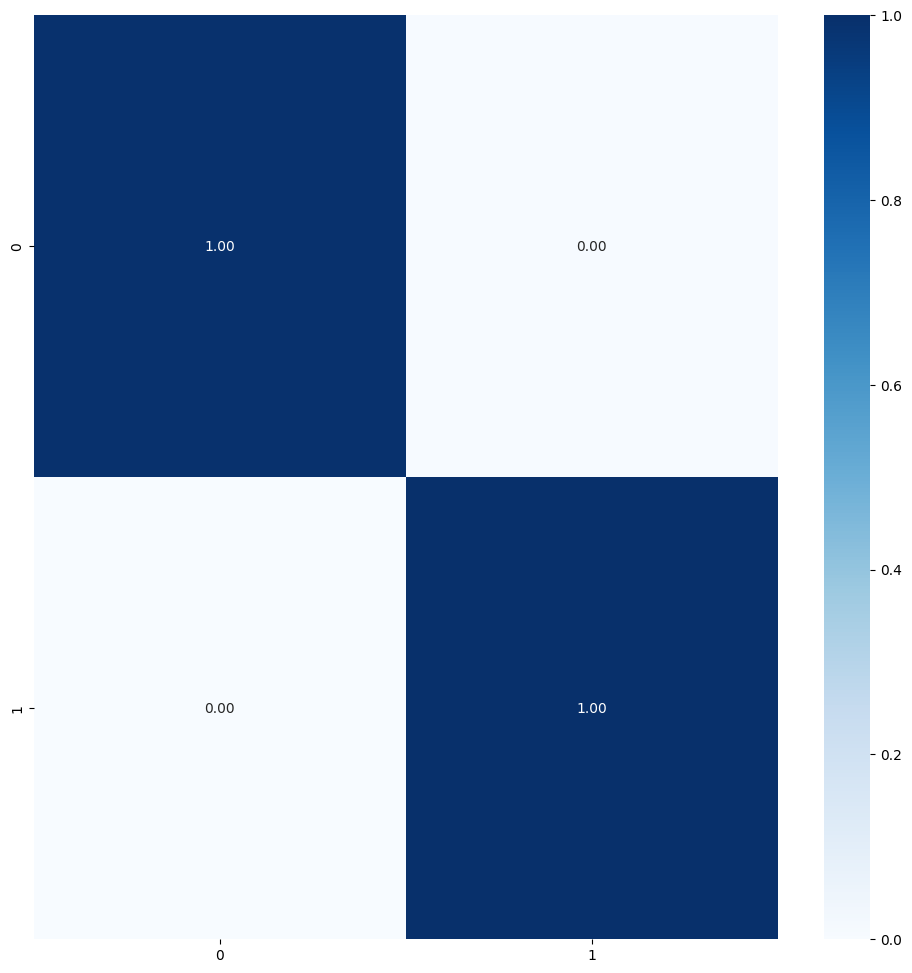


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3821634
Trainable params: 1644418
Non-trainable params: 2177216
Epoch 1/50
65/65 [==============================] - 23s 192ms/step - loss: 0.9397 - accuracy: 0.9811 - val_loss: 0.9952 - val_accuracy: 0.9978 - lr: 1.0000e-04
Epoch 2/50
65/65 [==============================] - 12s 176ms/step - loss: 0.8684 - accuracy: 0.9990 - val_loss: 0.9048 - val_accuracy: 0.9978 - lr: 1.0000e-04
Epoch 3/50
65/65 [==============================] - 11s 169ms/step - loss: 0.8531 - accuracy: 0.9990 - val_loss: 0.8474 - val_accuracy: 0.9978 - lr: 1.0000e-04
Epoch 4/50
65/65 [==============================] - 11s 175ms/step - loss: 0.8292 - accuracy: 0.9995 - val_loss: 0.8222 - val_accuracy: 0.9978 - lr: 1.0000e-04
Epoch 5/50
65/65 [==============================] - 11s 162ms/step - loss: 0.8100 - accuracy: 0.9995 - val_loss: 0.8005 - val_accuracy: 0.9978 - lr: 1.0000e-04
Epoch 6/50
65/65 [==============================] - 11s 164ms/step - loss: 0.7918 - 

Model and History saved...
66/66 [==============================] - 8s 118ms/step - loss: 0.7793 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.7792977094650269
15/15 [==============================] - 2s 117ms/step - loss: 0.7795 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.7794946432113647
15/15 [==============================] - 3s 122ms/step - loss: 0.7793 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.7792905569076538
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450

15/15 [==============================] 

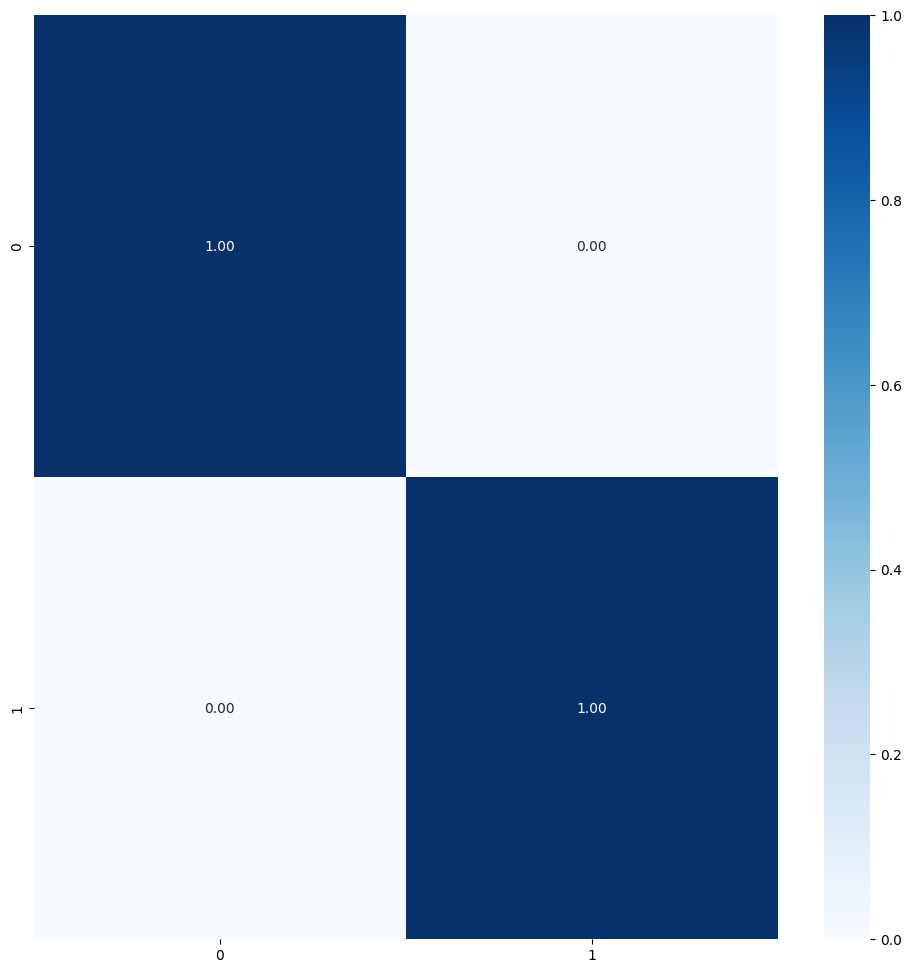


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3821634
Trainable params: 1644418
Non-trainable params: 2177216
Epoch 1/50
65/65 [==============================] - 25s 212ms/step - loss: 0.9536 - accuracy: 0.9729 - val_loss: 0.9725 - val_accuracy: 0.9933 - lr: 1.0000e-04
Epoch 2/50
65/65 [==============================] - 11s 160ms/step - loss: 0.8668 - accuracy: 0.9990 - val_loss: 0.8829 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 3/50
65/65 [==============================] - 11s 162ms/step - loss: 0.8467 - accuracy: 0.9985 - val_loss: 0.8390 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 4/50
65/65 [==============================] - 10s 144ms/step - loss: 0.8250 - accuracy: 1.0000 - val_loss: 0.8147 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 5/50
65/65 [==============================] - 10s 159ms/step - loss: 0.8047 - accuracy: 1.0000 - val_loss: 0.7930 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 6/50
65/65 [==============================] - 11s 163ms/step - loss: 0.7828 - 

Model and History saved...
66/66 [==============================] - 9s 114ms/step - loss: 0.8812 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.8812462687492371
15/15 [==============================] - 3s 115ms/step - loss: 0.8828 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.8828213214874268
15/15 [==============================] - 3s 114ms/step - loss: 0.8839 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.8838855624198914
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450

15/15 [==============================] 

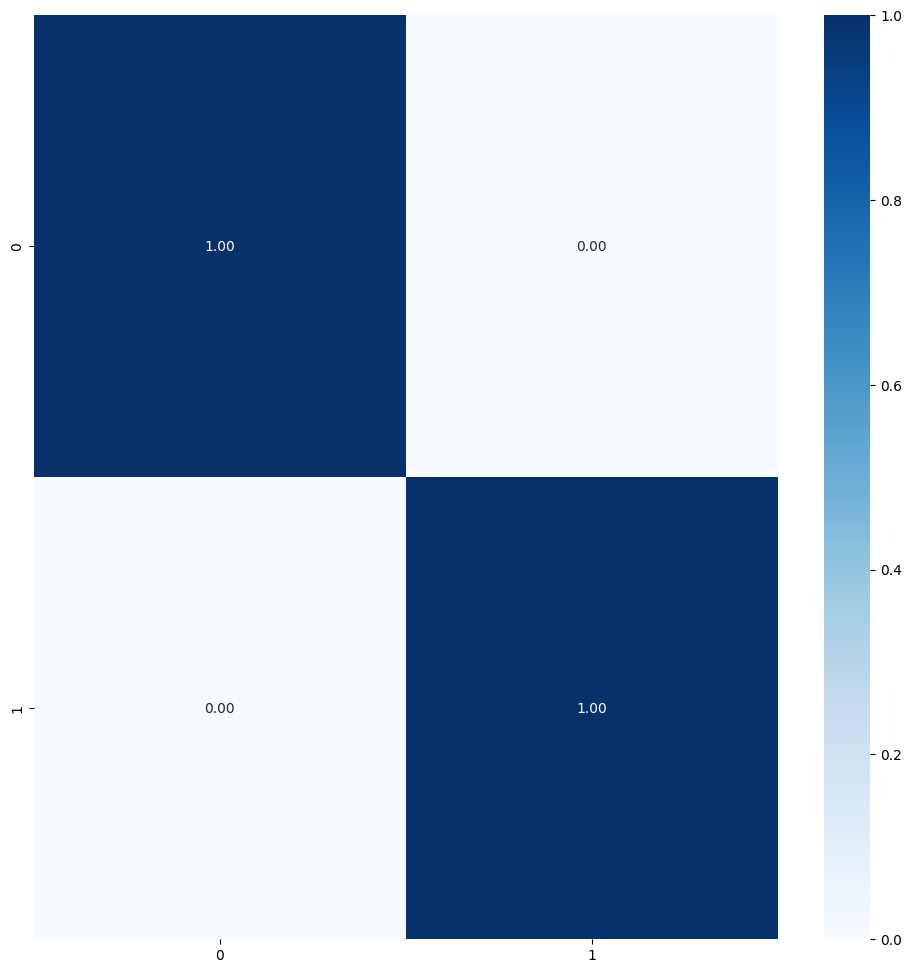


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3821634
Trainable params: 1644418
Non-trainable params: 2177216
Epoch 1/50
65/65 [==============================] - 22s 192ms/step - loss: 0.9335 - accuracy: 0.9840 - val_loss: 0.9762 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 2/50
65/65 [==============================] - 10s 153ms/step - loss: 0.8658 - accuracy: 0.9985 - val_loss: 0.8742 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 3/50
65/65 [==============================] - 11s 160ms/step - loss: 0.8418 - accuracy: 1.0000 - val_loss: 0.8353 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 4/50
65/65 [==============================] - 10s 147ms/step - loss: 0.8224 - accuracy: 0.9990 - val_loss: 0.8111 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 5/50
65/65 [==============================] - 10s 149ms/step - loss: 0.7997 - accuracy: 0.9995 - val_loss: 0.7884 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 6/50
65/65 [==============================] - 10s 151ms/step - loss: 0.7781 - 

Model and History saved...
66/66 [==============================] - 9s 133ms/step - loss: 0.8744 - accuracy: 0.9995
Train Accuracy: 0.9995238184928894
Train Log Loss: 0.8743910789489746
15/15 [==============================] - 3s 134ms/step - loss: 0.8742 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.8741971254348755
15/15 [==============================] - 2s 129ms/step - loss: 0.8764 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.8764215111732483
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[224   1]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450

15/15 [==

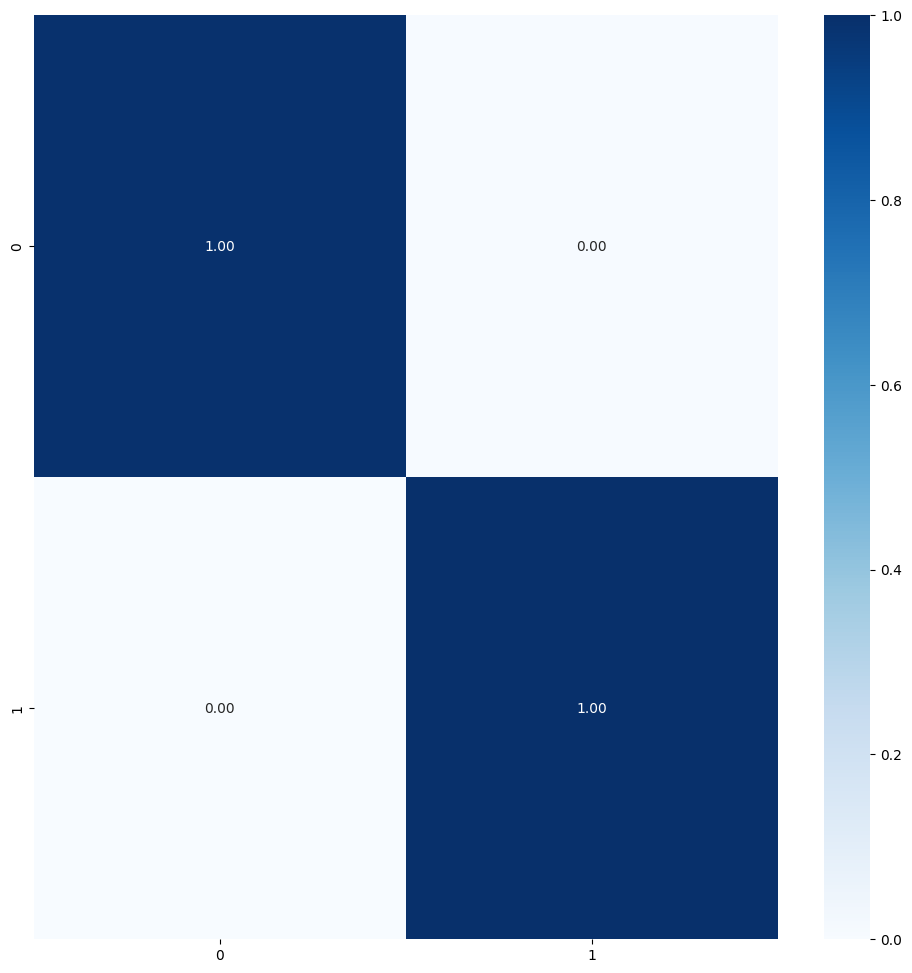

Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 1.0
/nTest Metrics
test_acc_list: [1.0, 0.9977777600288391, 1.0, 1.0, 0.9977777600288391]
Average Test Accuracy with 5-fold: 0.9991111040115357
test_loss_list: [0.883240818977356, 0.8711802363395691, 0.7792905569076538, 0.8838855624198914, 0.8764215111732483]
Average Test Log Loss with 5-fold: 0.8588037371635437

Precision List: [1.0, 0.997787610619469, 1.0, 1.0, 0.997787610619469]
Average Precision List with 5-fold: 0.9991150442477876
Recall List: [1.0, 0.9977777777777778, 1.0, 1.0, 0.9977777777777778]
Average Recall List with 5-fold: 0.9991111111111112
F1 Score List: [1.0, 0.9977777668037867, 1.0, 1.0, 0.9977777668037867]
Average F1 Score List with 5-fold: 0.9991111067215147

Metrics List Store

test_acc_list_all = [0.9991111040115357]
test_loss_list_all = [0.8588037371635437]
precision_list_all = [0.9991150442477876]
recall_list_all = [0.9991111111111112]
f1_score_list_all = [0.9991111067215147]
La carp

In [14]:
%%time
###################################### Probar Dropout 0.4
num_classes = 2
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/3
name_save_model: fusion_MobileNet_tf_optimized 3
Found 3150 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3821763
Trainable params: 1644547
Non-trainable params: 2177216
Epoch 1/50
98/98 [==============================] - 32s 210ms/step - loss: 0.9861 - accuracy: 0.9634 - val_loss: 0.9734 - val_accuracy: 0.9926 - lr: 1.0000e-04
Epoch 2/50
98/98 [==============================] - 18s 182ms/step - loss: 0.8767 - accuracy: 0.9981 - val_loss: 0.8703 - val_accuracy: 0.9985 - lr: 1.0000e-04
Epoch 3/50
98/98 [==============================] - 18s 184ms/step - loss: 0.8565 - accuracy: 0.9987 - val_loss: 0.8458 - val_accuracy: 0.9985 - lr: 1.0000e-04
Epoch 4/50
98/98 [==============================] - 18s 179ms/step - loss: 0.8384 - a

Model and History saved...
99/99 [==============================] - 17s 166ms/step - loss: 0.8248 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.8248178362846375
22/22 [==============================] - 3s 140ms/step - loss: 0.8254 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.8253836631774902
22/22 [==============================] - 3s 133ms/step - loss: 0.8249 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.8248828053474426
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1.00       675
   macro avg       1.00      1.00      1.00       675


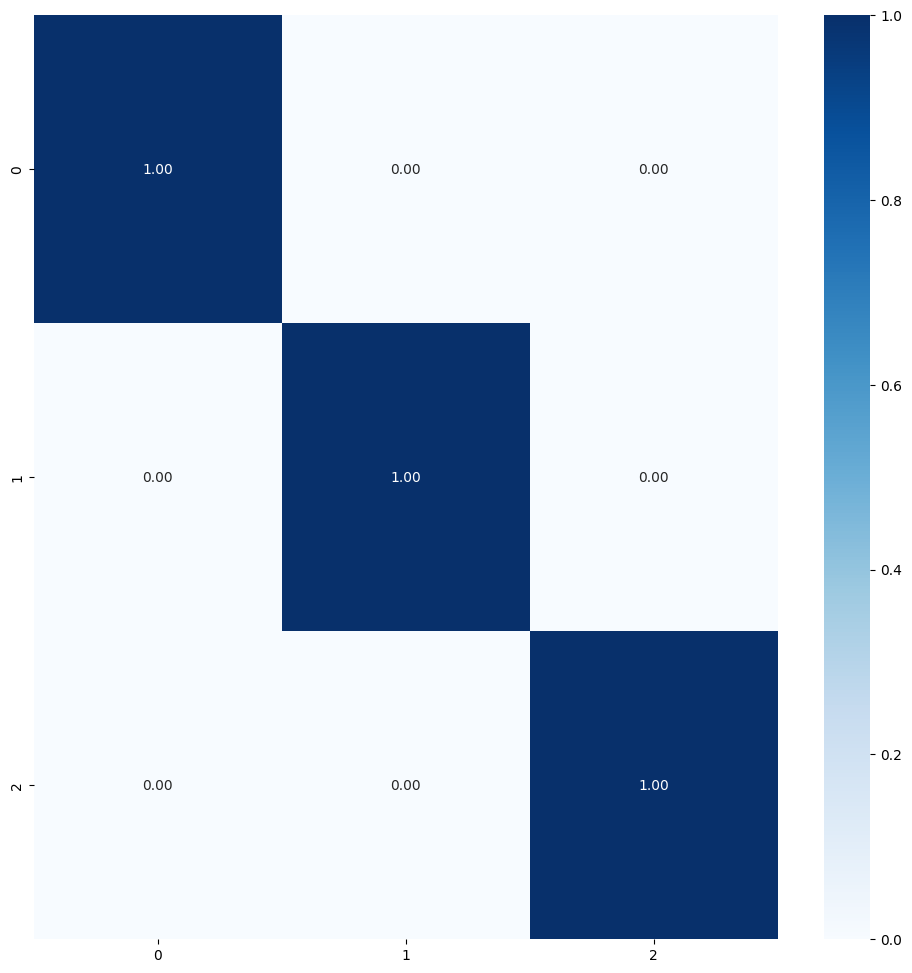


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3821763
Trainable params: 1644547
Non-trainable params: 2177216
Epoch 1/50
98/98 [==============================] - 30s 196ms/step - loss: 0.9859 - accuracy: 0.9631 - val_loss: 0.9913 - val_accuracy: 0.9866 - lr: 1.0000e-04
Epoch 2/50
98/98 [==============================] - 18s 172ms/step - loss: 0.8731 - accuracy: 0.9994 - val_loss: 0.8759 - val_accuracy: 0.9970 - lr: 1.0000e-04
Epoch 3/50
98/98 [==============================] - 19s 195ms/step - loss: 0.8579 - accuracy: 0.9987 - val_loss: 0.8491 - val_accuracy: 0.9970 - lr: 1.0000e-04
Epoch 4/50
98/98 [==============================] - 15s 147ms/step - loss: 0.8377 - accuracy: 0.9994 - val_loss: 0.8311 - val_accuracy: 0.9970 - lr: 1.0000e-04
Epoch 5/50
98/98 [==============================] - 13s 127ms/step - loss: 0.8183 - accuracy: 0.9990 - val_loss: 0.8100 - val_accuracy: 0.9985 - lr: 1.0000e-04
Epoch 6/50
98/98 [==============================] - 6s 64ms/step - loss: 0.7965 - ac

Model and History saved...
99/99 [==============================] - 13s 123ms/step - loss: 0.6209 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.6209496855735779
22/22 [==============================] - 3s 125ms/step - loss: 0.6219 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.6218770742416382
22/22 [==============================] - 3s 126ms/step - loss: 0.6210 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.6209504008293152
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1.00       675
   macro avg       1.00      1.00      1.00       675


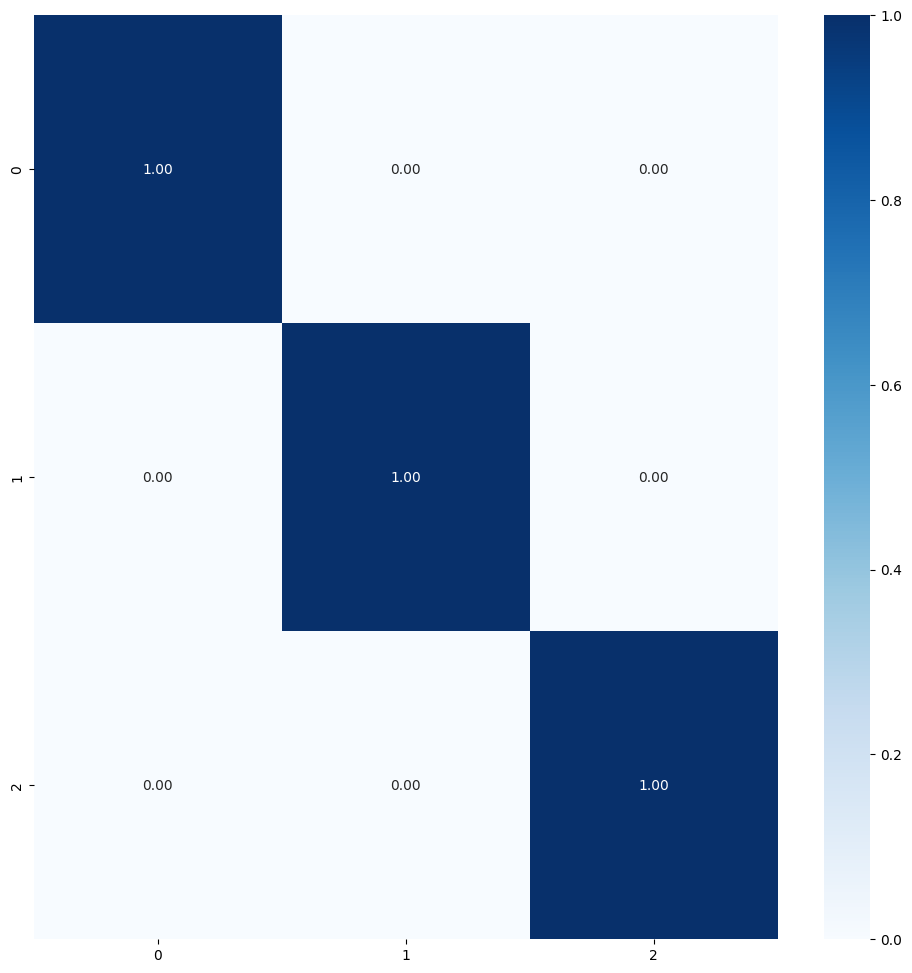


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3821763
Trainable params: 1644547
Non-trainable params: 2177216
Epoch 1/50
98/98 [==============================] - 28s 192ms/step - loss: 0.9743 - accuracy: 0.9679 - val_loss: 1.0104 - val_accuracy: 0.9926 - lr: 1.0000e-04
Epoch 2/50
98/98 [==============================] - 18s 183ms/step - loss: 0.8734 - accuracy: 0.9978 - val_loss: 0.8684 - val_accuracy: 0.9985 - lr: 1.0000e-04
Epoch 3/50
98/98 [==============================] - 19s 188ms/step - loss: 0.8492 - accuracy: 0.9981 - val_loss: 0.8415 - val_accuracy: 0.9970 - lr: 1.0000e-04
Epoch 4/50
98/98 [==============================] - 19s 196ms/step - loss: 0.8260 - accuracy: 0.9997 - val_loss: 0.8200 - val_accuracy: 0.9985 - lr: 1.0000e-04
Epoch 5/50
98/98 [==============================] - 18s 186ms/step - loss: 0.8047 - accuracy: 0.9994 - val_loss: 0.7922 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 6/50
98/98 [==============================] - 18s 179ms/step - loss: 0.7799 - 

Model and History saved...
99/99 [==============================] - 13s 123ms/step - loss: 0.7905 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.790477454662323
22/22 [==============================] - 3s 118ms/step - loss: 0.7922 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.7921754121780396
22/22 [==============================] - 3s 126ms/step - loss: 0.7907 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.7907312512397766
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1.00       675
   macro avg       1.00      1.00      1.00       675
w

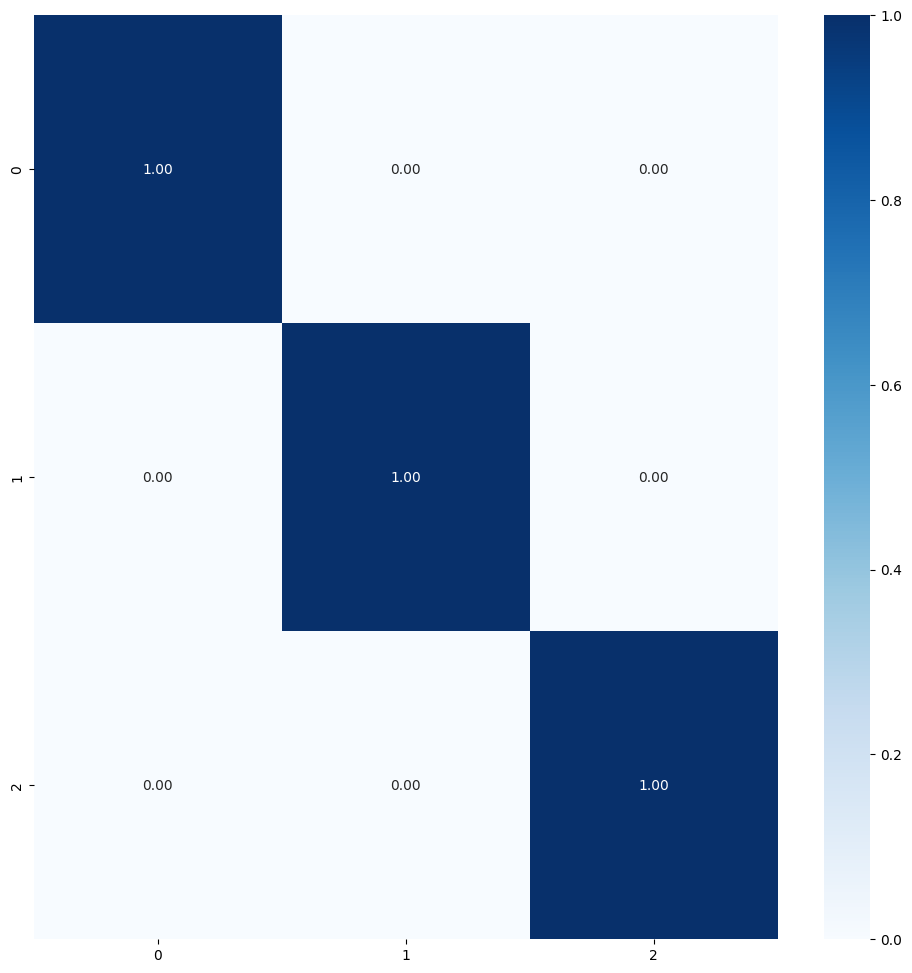


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3821763
Trainable params: 1644547
Non-trainable params: 2177216
Epoch 1/50
98/98 [==============================] - 29s 175ms/step - loss: 1.0049 - accuracy: 0.9615 - val_loss: 0.9997 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 2/50
98/98 [==============================] - 16s 159ms/step - loss: 0.8809 - accuracy: 0.9974 - val_loss: 0.8725 - val_accuracy: 0.9985 - lr: 1.0000e-04
Epoch 3/50
98/98 [==============================] - 17s 170ms/step - loss: 0.8545 - accuracy: 0.9978 - val_loss: 0.8453 - val_accuracy: 0.9985 - lr: 1.0000e-04
Epoch 4/50
98/98 [==============================] - 17s 170ms/step - loss: 0.8319 - accuracy: 0.9997 - val_loss: 0.8242 - val_accuracy: 0.9985 - lr: 1.0000e-04
Epoch 5/50
98/98 [==============================] - 15s 153ms/step - loss: 0.8116 - accuracy: 0.9994 - val_loss: 0.8026 - val_accuracy: 0.9985 - lr: 1.0000e-04
Epoch 6/50
98/98 [==============================] - 16s 160ms/step - loss: 0.7892 - 

Model and History saved...
99/99 [==============================] - 14s 126ms/step - loss: 0.5790 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.579029381275177
22/22 [==============================] - 3s 117ms/step - loss: 0.5793 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.5793128609657288
22/22 [==============================] - 3s 119ms/step - loss: 0.5790 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.5790339708328247
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1.00       675
   macro avg       1.00      1.00      1.00       675
w

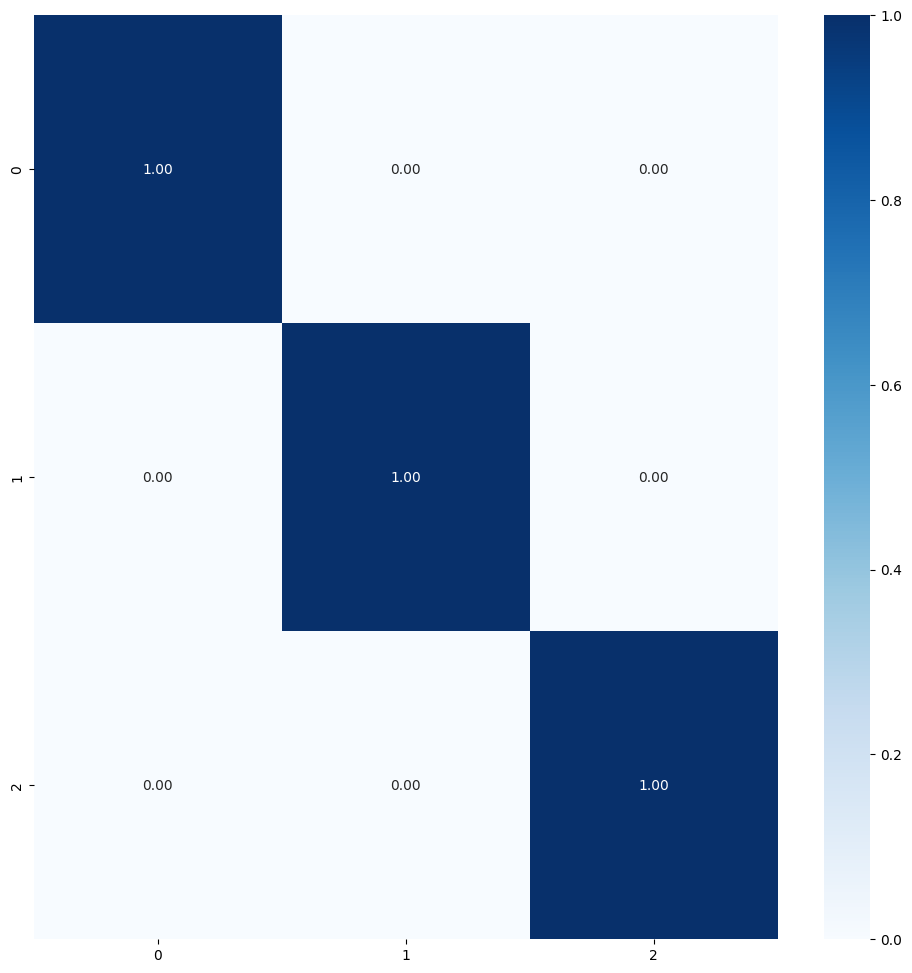


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3821763
Trainable params: 1644547
Non-trainable params: 2177216
Epoch 1/50
98/98 [==============================] - 30s 209ms/step - loss: 0.9578 - accuracy: 0.9740 - val_loss: 0.9416 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 2/50
98/98 [==============================] - 16s 160ms/step - loss: 0.8657 - accuracy: 0.9987 - val_loss: 0.8634 - val_accuracy: 0.9970 - lr: 1.0000e-04
Epoch 3/50
98/98 [==============================] - 15s 152ms/step - loss: 0.8429 - accuracy: 0.9994 - val_loss: 0.8339 - val_accuracy: 0.9970 - lr: 1.0000e-04
Epoch 4/50
98/98 [==============================] - 15s 157ms/step - loss: 0.8204 - accuracy: 0.9990 - val_loss: 0.8101 - val_accuracy: 0.9970 - lr: 1.0000e-04
Epoch 5/50
98/98 [==============================] - 19s 182ms/step - loss: 0.7967 - accuracy: 0.9994 - val_loss: 0.7869 - val_accuracy: 0.9985 - lr: 1.0000e-04
Epoch 6/50
98/98 [==============================] - 16s 161ms/step - loss: 0.7704 - 

Model and History saved...
99/99 [==============================] - 14s 124ms/step - loss: 0.5952 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.5951768755912781
22/22 [==============================] - 3s 120ms/step - loss: 0.5961 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.5961374044418335
22/22 [==============================] - 3s 122ms/step - loss: 0.5952 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.5951587557792664
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1.00       675
   macro avg       1.00      1.00      1.00       675


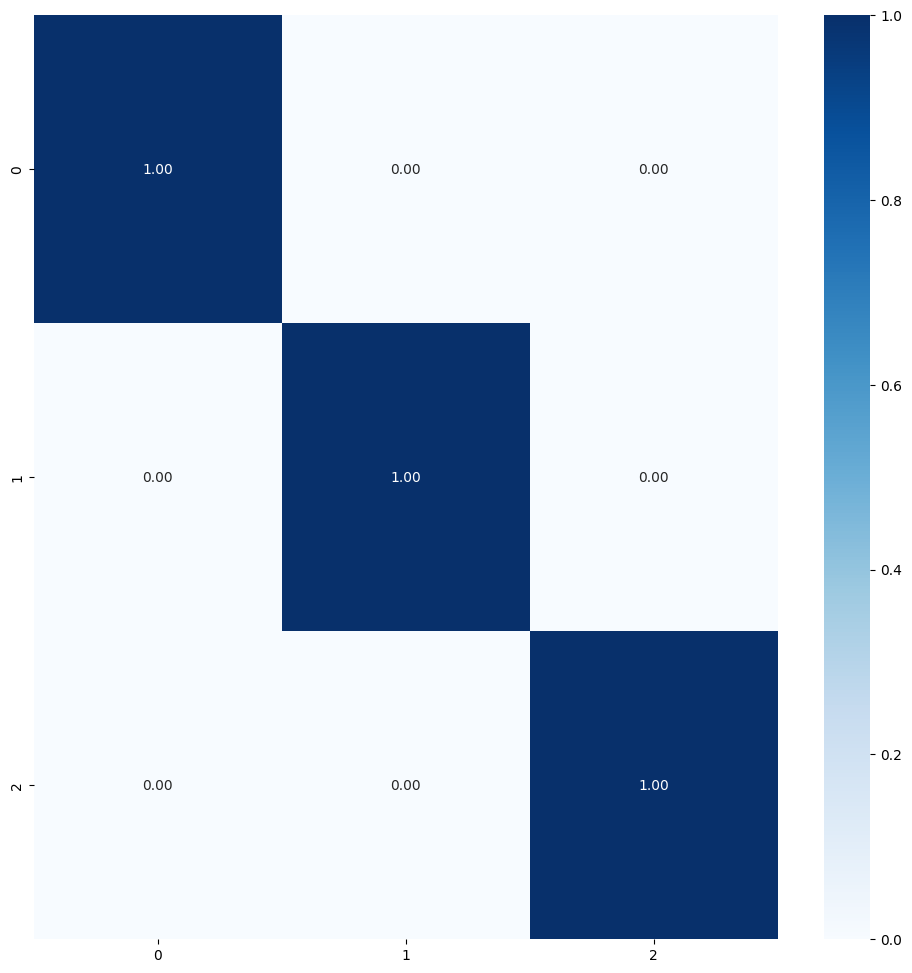

Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 1.0
/nTest Metrics
test_acc_list: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Test Accuracy with 5-fold: 1.0
test_loss_list: [0.8248828053474426, 0.6209504008293152, 0.7907312512397766, 0.5790339708328247, 0.5951587557792664]
Average Test Log Loss with 5-fold: 0.6821514368057251

Precision List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Precision List with 5-fold: 1.0
Recall List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Recall List with 5-fold: 1.0
F1 Score List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average F1 Score List with 5-fold: 1.0

Metrics List Store

test_acc_list_all = [0.9991111040115357, 1.0]
test_loss_list_all = [0.8588037371635437, 0.6821514368057251]
precision_list_all = [0.9991150442477876, 1.0]
recall_list_all = [0.9991111111111112, 1.0]
f1_score_list_all = [0.9991111067215147, 1.0]
La carpeta 3 fue eliminada.
CPU times: user 1h 5min 46s, sys: 6min 7s, total: 1h 11min 53s
Wall time: 1h 3min 11s


In [15]:
%%time

num_classes = 3
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/4
name_save_model: fusion_MobileNet_tf_optimized 4
Found 4200 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3821892
Trainable params: 1644676
Non-trainable params: 2177216
Epoch 1/50
131/131 [==============================] - 34s 186ms/step - loss: 1.0019 - accuracy: 0.9602 - val_loss: 0.9383 - val_accuracy: 0.9911 - lr: 1.0000e-04
Epoch 2/50
131/131 [==============================] - 25s 191ms/step - loss: 0.8910 - accuracy: 0.9935 - val_loss: 0.8809 - val_accuracy: 0.9944 - lr: 1.0000e-04
Epoch 3/50
131/131 [==============================] - 22s 163ms/step - loss: 0.8641 - accuracy: 0.9959 - val_loss: 0.8562 - val_accuracy: 0.9967 - lr: 1.0000e-04
Epoch 4/50
131/131 [==============================] - 23s 170ms/step -

Model and History saved...
132/132 [==============================] - 18s 134ms/step - loss: 0.7246 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.7246145606040955
29/29 [==============================] - 5s 140ms/step - loss: 0.7407 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.7406828999519348
29/29 [==============================] - 5s 138ms/step - loss: 0.7460 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.7459560632705688
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00      1.00      1.00       225
           3       1.00      0.99 

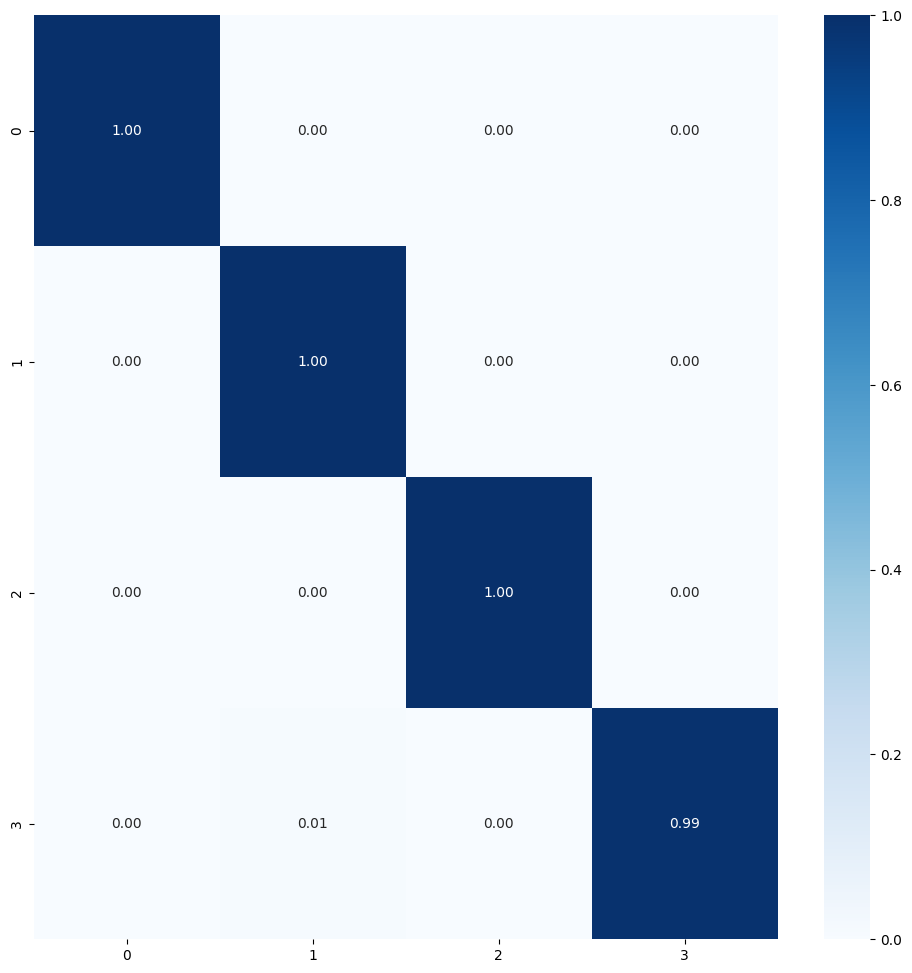


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3821892
Trainable params: 1644676
Non-trainable params: 2177216
Epoch 1/50
131/131 [==============================] - 34s 179ms/step - loss: 1.0639 - accuracy: 0.9405 - val_loss: 0.9901 - val_accuracy: 0.9810 - lr: 1.0000e-04
Epoch 2/50
131/131 [==============================] - 22s 169ms/step - loss: 0.8992 - accuracy: 0.9930 - val_loss: 0.8858 - val_accuracy: 0.9944 - lr: 1.0000e-04
Epoch 3/50
131/131 [==============================] - 26s 193ms/step - loss: 0.8693 - accuracy: 0.9971 - val_loss: 0.8689 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 4/50
131/131 [==============================] - 24s 170ms/step - loss: 0.8493 - accuracy: 0.9976 - val_loss: 0.8545 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 5/50
131/131 [==============================] - 22s 167ms/step - loss: 0.8277 - accuracy: 0.9986 - val_loss: 0.8320 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 6/50
131/131 [==============================] - 22s 164ms/step - los

Model and History saved...
132/132 [==============================] - 20s 148ms/step - loss: 0.7677 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.7677279710769653
29/29 [==============================] - 4s 141ms/step - loss: 0.7837 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.7837191820144653
29/29 [==============================] - 5s 148ms/step - loss: 0.7773 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.7773396372795105
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00      1.00      1.00       225
           3       1.00      0.99 

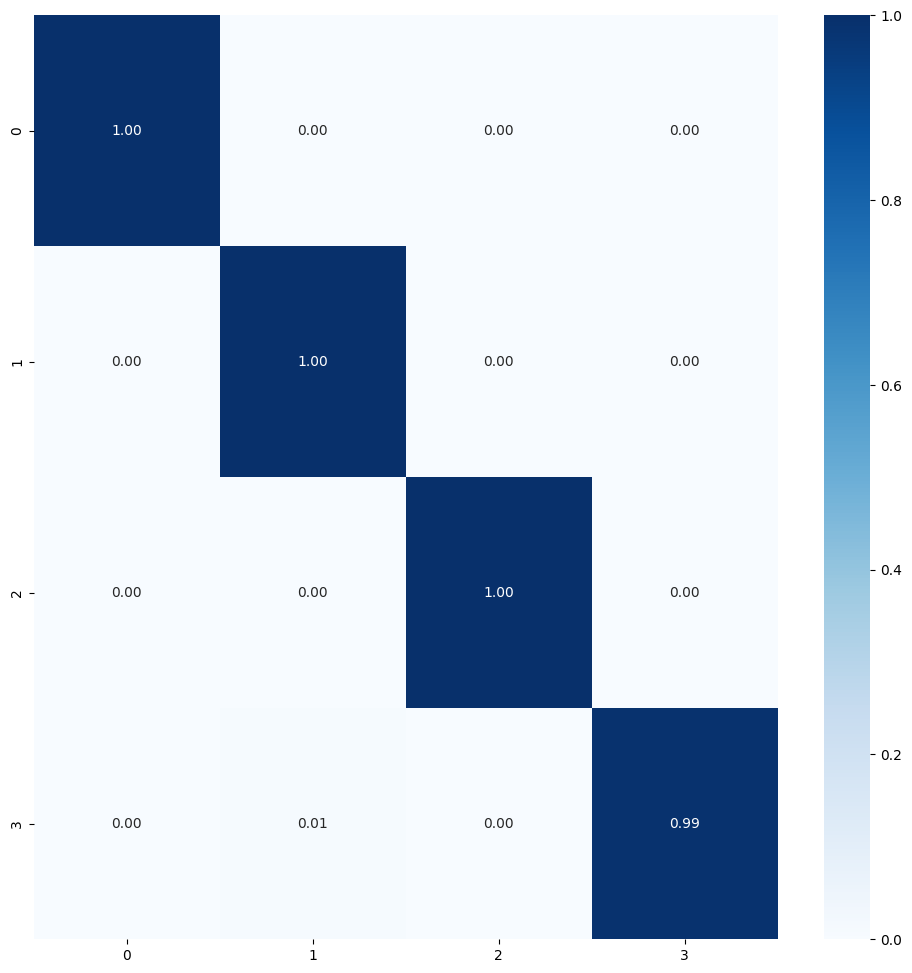


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3821892
Trainable params: 1644676
Non-trainable params: 2177216
Epoch 1/50
131/131 [==============================] - 37s 199ms/step - loss: 1.0179 - accuracy: 0.9568 - val_loss: 0.9532 - val_accuracy: 0.9900 - lr: 1.0000e-04
Epoch 2/50
131/131 [==============================] - 24s 179ms/step - loss: 0.8927 - accuracy: 0.9945 - val_loss: 0.8835 - val_accuracy: 0.9922 - lr: 1.0000e-04
Epoch 3/50
131/131 [==============================] - 24s 182ms/step - loss: 0.8660 - accuracy: 0.9969 - val_loss: 0.8628 - val_accuracy: 0.9967 - lr: 1.0000e-04
Epoch 4/50
131/131 [==============================] - 23s 174ms/step - loss: 0.8433 - accuracy: 0.9986 - val_loss: 0.8377 - val_accuracy: 0.9967 - lr: 1.0000e-04
Epoch 5/50
131/131 [==============================] - 25s 186ms/step - loss: 0.8188 - accuracy: 0.9981 - val_loss: 0.8122 - val_accuracy: 0.9967 - lr: 1.0000e-04
Epoch 6/50
131/131 [==============================] - 24s 183ms/step - los

Model and History saved...
132/132 [==============================] - 18s 134ms/step - loss: 0.6404 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.6403911113739014
29/29 [==============================] - 4s 118ms/step - loss: 0.6543 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.6542908549308777
29/29 [==============================] - 4s 139ms/step - loss: 0.6479 - accuracy: 0.9967
Test Accuracy: 0.996666669845581
Test Log Loss: 0.6479469537734985
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 224   0   1]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       1.00      1.00      1.00       225
           3       1.00      0.99  

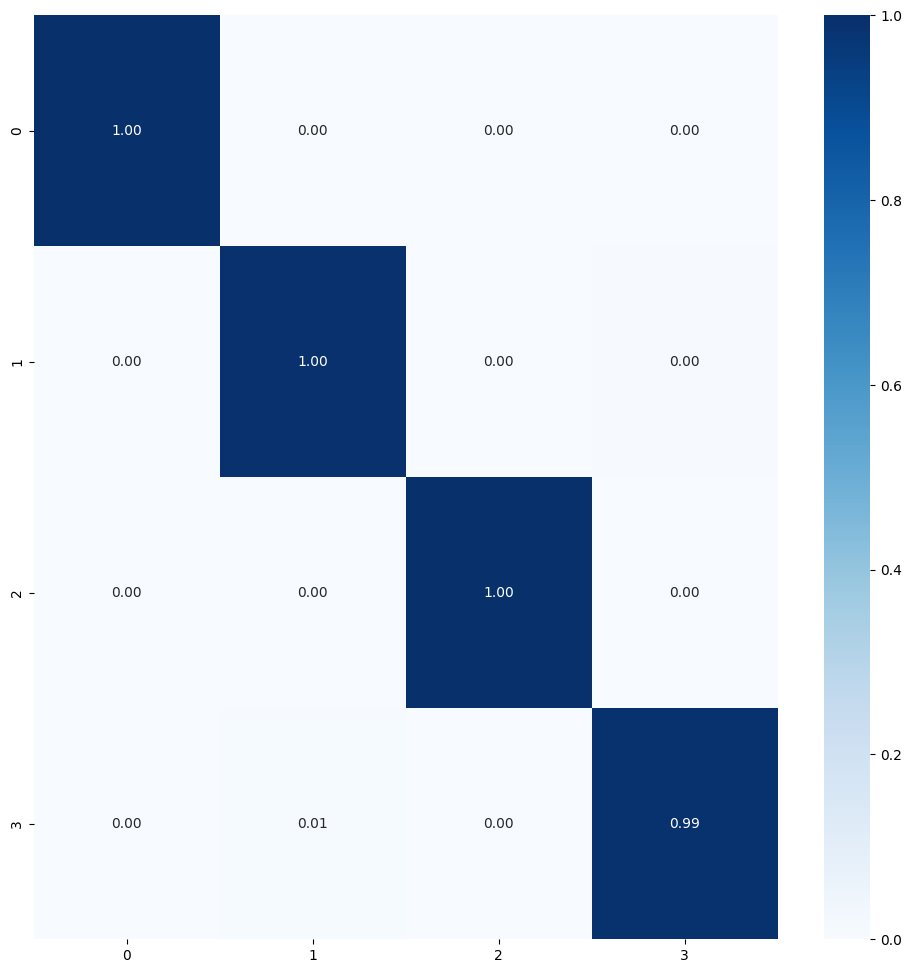


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3821892
Trainable params: 1644676
Non-trainable params: 2177216
Epoch 1/50
131/131 [==============================] - 36s 192ms/step - loss: 1.0095 - accuracy: 0.9559 - val_loss: 0.9424 - val_accuracy: 0.9900 - lr: 1.0000e-04
Epoch 2/50
131/131 [==============================] - 21s 162ms/step - loss: 0.8889 - accuracy: 0.9938 - val_loss: 0.8772 - val_accuracy: 0.9944 - lr: 1.0000e-04
Epoch 3/50
131/131 [==============================] - 23s 168ms/step - loss: 0.8583 - accuracy: 0.9978 - val_loss: 0.8545 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 4/50
131/131 [==============================] - 20s 155ms/step - loss: 0.8402 - accuracy: 0.9964 - val_loss: 0.8329 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 5/50
131/131 [==============================] - 21s 163ms/step - loss: 0.8167 - accuracy: 0.9981 - val_loss: 0.8099 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 6/50
131/131 [==============================] - 23s 163ms/step - los

Model and History saved...
132/132 [==============================] - 17s 129ms/step - loss: 0.5325 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.5324957966804504
29/29 [==============================] - 4s 120ms/step - loss: 0.5484 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.5483539700508118
29/29 [==============================] - 4s 129ms/step - loss: 0.5460 - accuracy: 0.9967
Test Accuracy: 0.996666669845581
Test Log Loss: 0.5460039973258972
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 224   0   1]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       1.00      1.00      1.00       225
           3       1.00      0.99  

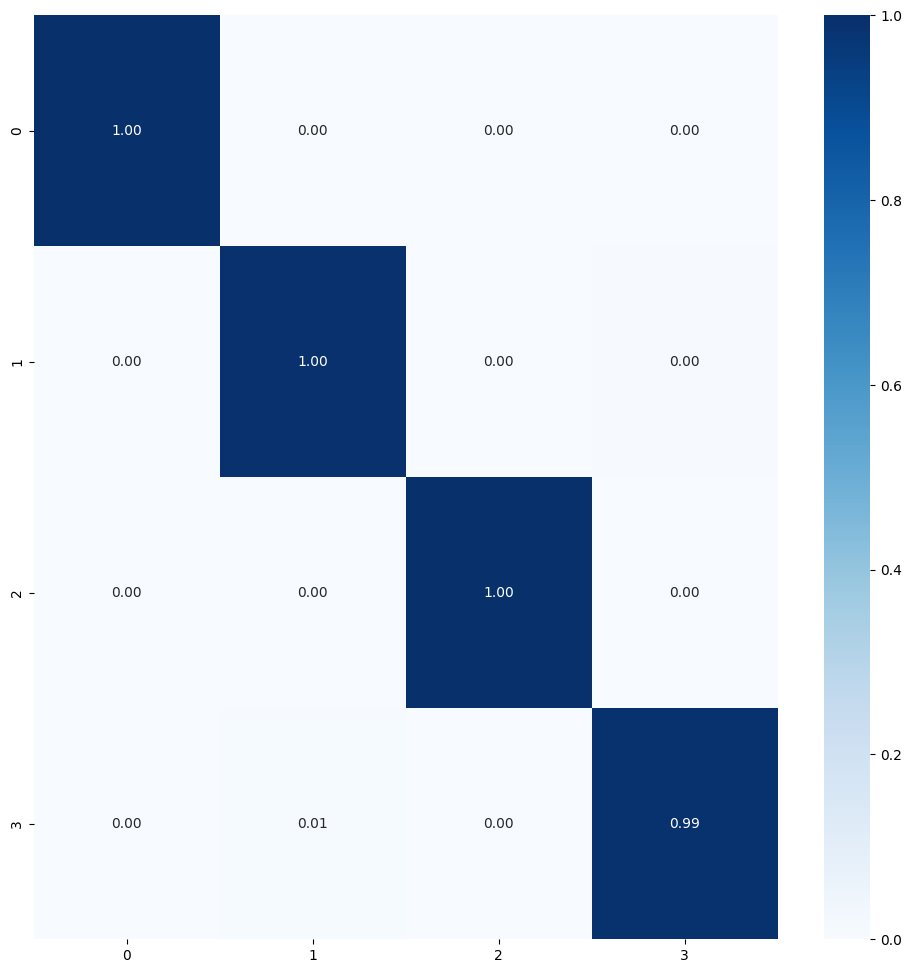


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3821892
Trainable params: 1644676
Non-trainable params: 2177216
Epoch 1/50
131/131 [==============================] - 36s 186ms/step - loss: 1.0650 - accuracy: 0.9398 - val_loss: 0.9437 - val_accuracy: 0.9888 - lr: 1.0000e-04
Epoch 2/50
131/131 [==============================] - 20s 154ms/step - loss: 0.8950 - accuracy: 0.9947 - val_loss: 0.8854 - val_accuracy: 0.9944 - lr: 1.0000e-04
Epoch 3/50
131/131 [==============================] - 22s 168ms/step - loss: 0.8716 - accuracy: 0.9969 - val_loss: 0.8649 - val_accuracy: 0.9944 - lr: 1.0000e-04
Epoch 4/50
131/131 [==============================] - 21s 162ms/step - loss: 0.8538 - accuracy: 0.9964 - val_loss: 0.8461 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 5/50
131/131 [==============================] - 21s 161ms/step - loss: 0.8302 - accuracy: 0.9978 - val_loss: 0.8273 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 6/50
131/131 [==============================] - 20s 153ms/step - los

Model and History saved...
132/132 [==============================] - 18s 131ms/step - loss: 0.0427 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.042725563049316406
29/29 [==============================] - 3s 112ms/step - loss: 0.0632 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.06323013454675674
29/29 [==============================] - 4s 121ms/step - loss: 0.0571 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.05708811804652214
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00      1.00      1.00       225
           3       1.00      0

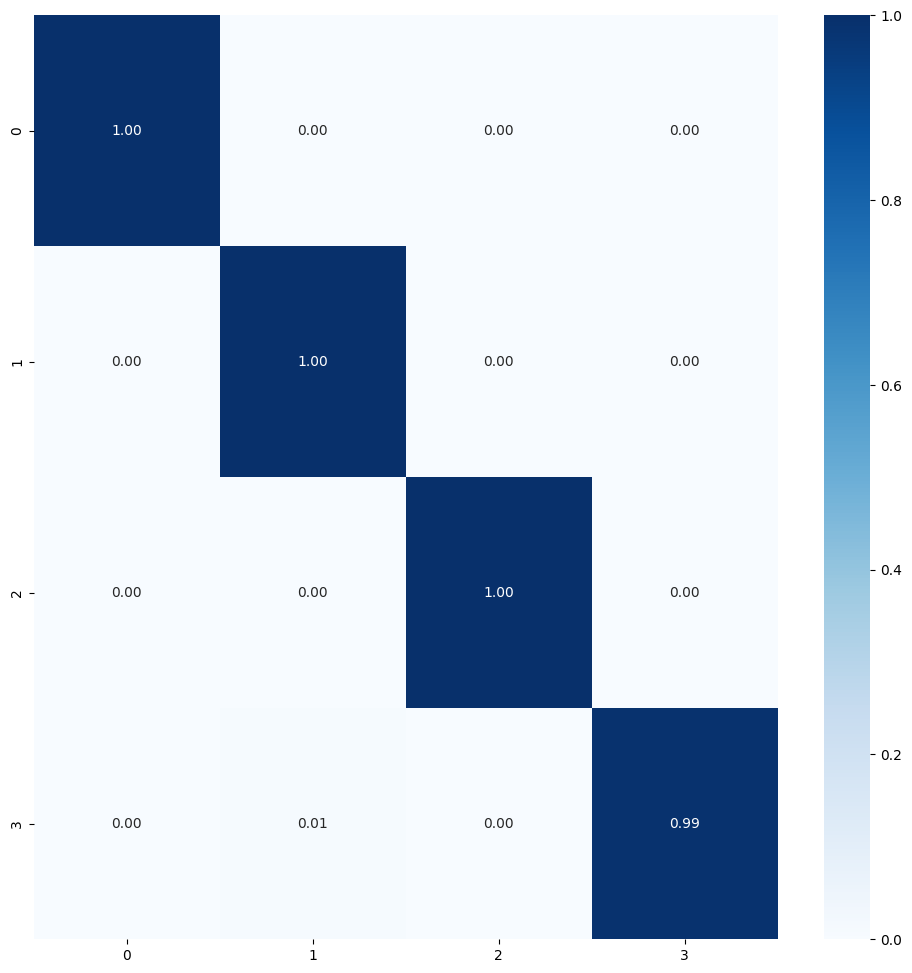

Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9975446462631226
/nTest Metrics
test_acc_list: [0.9977777600288391, 0.9977777600288391, 0.996666669845581, 0.996666669845581, 0.9977777600288391]
Average Test Accuracy with 5-fold: 0.9973333239555359
test_loss_list: [0.7459560632705688, 0.7773396372795105, 0.6479469537734985, 0.5460039973258972, 0.05708811804652214]
Average Test Log Loss with 5-fold: 0.5548669539391995

Precision List: [0.9977973568281938, 0.9977973568281938, 0.9966715391908976, 0.9966715391908976, 0.9977973568281938]
Average Precision List with 5-fold: 0.9973470297732753
Recall List: [0.9977777777777778, 0.9977777777777778, 0.9966666666666667, 0.9966666666666667, 0.9977777777777778]
Average Recall List with 5-fold: 0.9973333333333333
F1 Score List: [0.9977777338811631, 0.9977777338811631, 0.99666665020568, 0.99666665020568, 0.9977777338811631]
Average F1 Score List with 5-fold: 0.9973333004109698

Metrics List Store

test_acc_list_all =

In [16]:
%%time

num_classes = 4
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/5
name_save_model: fusion_MobileNet_tf_optimized 5
Found 5250 images belonging to 5 classes.
Found 1125 images belonging to 5 classes.
Found 1125 images belonging to 5 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3822021
Trainable params: 1644805
Non-trainable params: 2177216
Epoch 1/50
164/164 [==============================] - 38s 175ms/step - loss: 1.2227 - accuracy: 0.8850 - val_loss: 1.0445 - val_accuracy: 0.9536 - lr: 1.0000e-04
Epoch 2/50
164/164 [==============================] - 26s 157ms/step - loss: 0.9539 - accuracy: 0.9743 - val_loss: 0.9050 - val_accuracy: 0.9920 - lr: 1.0000e-04
Epoch 3/50
164/164 [==============================] - 25s 151ms/step - loss: 0.9051 - accuracy: 0.9864 - val_loss: 0.8783 - val_accuracy: 0.9920 - lr: 1.0000e-04
Epoch 4/50
164/164 [==============================] - 27s 16

Model and History saved...
165/165 [==============================] - 21s 125ms/step - loss: 0.1837 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.1837417632341385
36/36 [==============================] - 5s 128ms/step - loss: 0.2103 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.21029458940029144
36/36 [==============================] - 5s 125ms/step - loss: 0.2079 - accuracy: 0.9947
Test Accuracy: 0.9946666955947876
Test Log Loss: 0.20786979794502258
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 224   0   1   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   1   0 223]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       1.00      1.00 

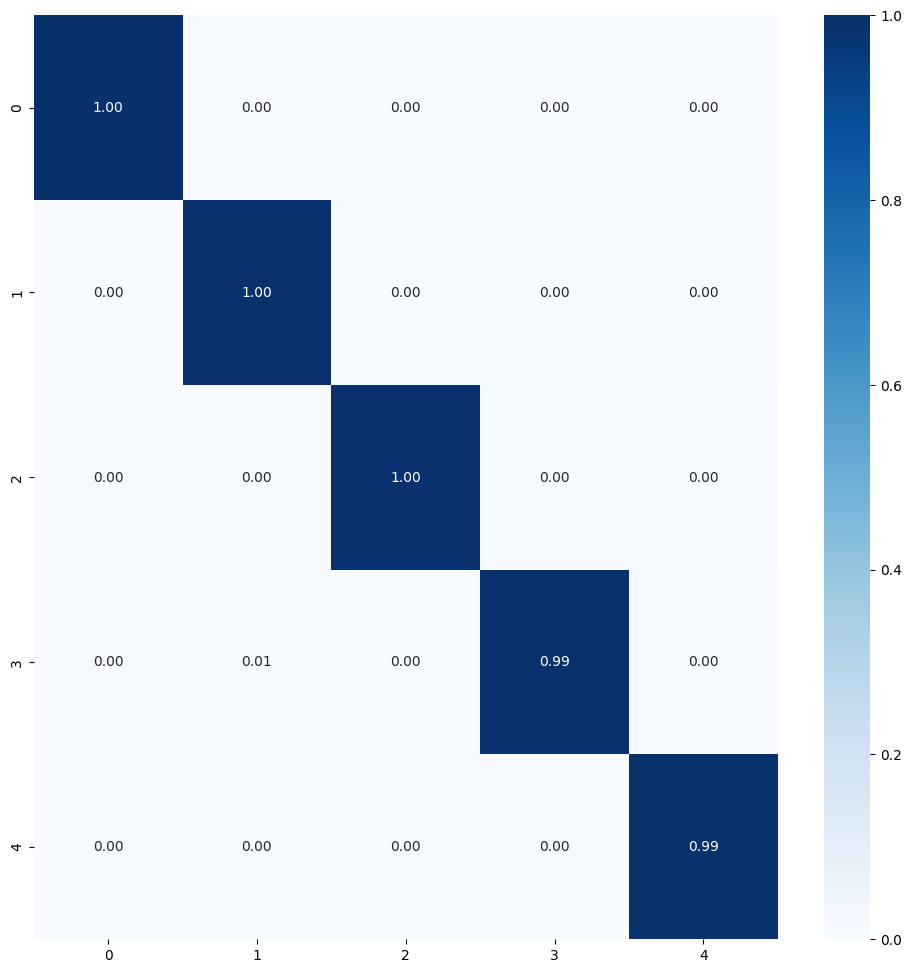


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3822021
Trainable params: 1644805
Non-trainable params: 2177216
Epoch 1/50
164/164 [==============================] - 41s 187ms/step - loss: 1.2549 - accuracy: 0.8756 - val_loss: 1.0827 - val_accuracy: 0.9187 - lr: 1.0000e-04
Epoch 2/50
164/164 [==============================] - 28s 165ms/step - loss: 0.9694 - accuracy: 0.9697 - val_loss: 0.9242 - val_accuracy: 0.9812 - lr: 1.0000e-04
Epoch 3/50
164/164 [==============================] - 27s 165ms/step - loss: 0.9181 - accuracy: 0.9828 - val_loss: 0.8831 - val_accuracy: 0.9929 - lr: 1.0000e-04
Epoch 4/50
164/164 [==============================] - 29s 177ms/step - loss: 0.8834 - accuracy: 0.9898 - val_loss: 0.9507 - val_accuracy: 0.9634 - lr: 1.0000e-04
Epoch 5/50
164/164 [==============================] - 29s 178ms/step - loss: 0.8583 - accuracy: 0.9918 - val_loss: 0.8449 - val_accuracy: 0.9937 - lr: 1.0000e-04
Epoch 6/50
164/164 [==============================] - 29s 178ms/step - los

Model and History saved...
165/165 [==============================] - 22s 135ms/step - loss: 0.1652 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.16520948708057404
36/36 [==============================] - 5s 137ms/step - loss: 0.1945 - accuracy: 0.9947
Validation Accuracy: 0.9946666955947876
Validation Log Loss: 0.1945212036371231
36/36 [==============================] - 5s 129ms/step - loss: 0.1880 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.18800029158592224
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 225   0   0   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   1   0 223]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       1.00      1.00 

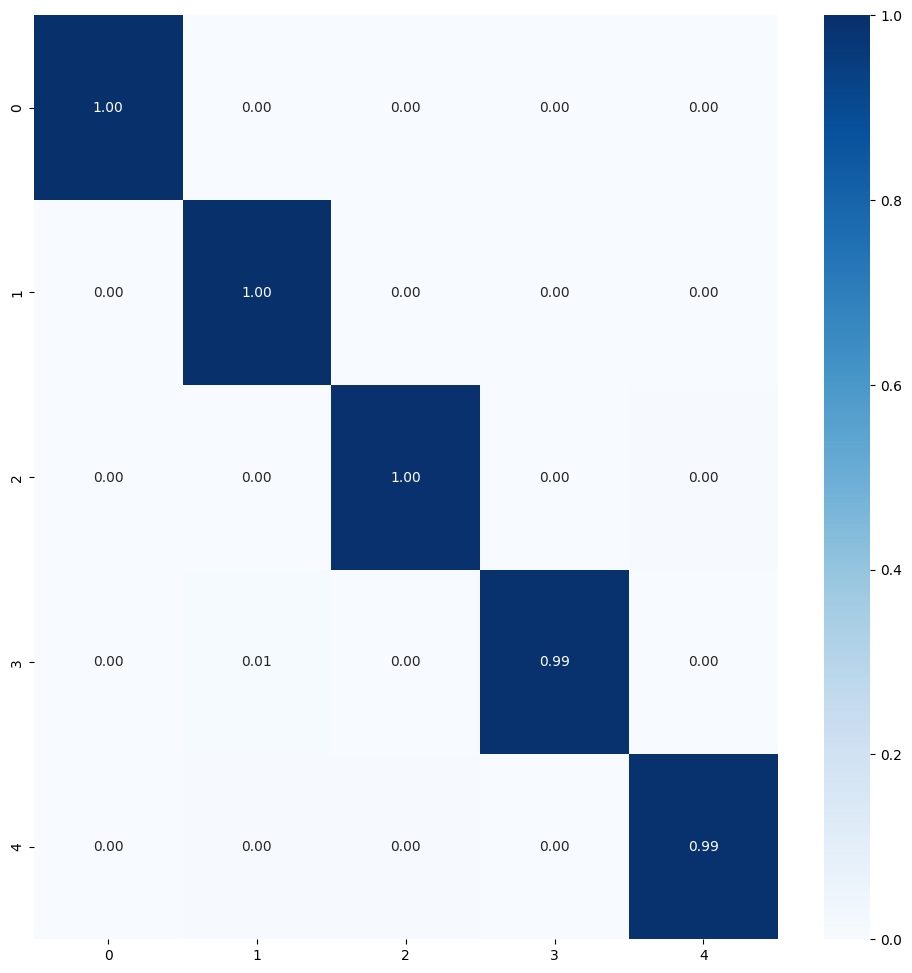


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3822021
Trainable params: 1644805
Non-trainable params: 2177216
Epoch 1/50
164/164 [==============================] - 38s 170ms/step - loss: 1.2291 - accuracy: 0.8787 - val_loss: 1.0829 - val_accuracy: 0.9259 - lr: 1.0000e-04
Epoch 2/50
164/164 [==============================] - 27s 163ms/step - loss: 0.9587 - accuracy: 0.9720 - val_loss: 0.9138 - val_accuracy: 0.9857 - lr: 1.0000e-04
Epoch 3/50
164/164 [==============================] - 25s 155ms/step - loss: 0.9108 - accuracy: 0.9829 - val_loss: 0.8794 - val_accuracy: 0.9937 - lr: 1.0000e-04
Epoch 4/50
164/164 [==============================] - 26s 156ms/step - loss: 0.8782 - accuracy: 0.9900 - val_loss: 0.9165 - val_accuracy: 0.9723 - lr: 1.0000e-04
Epoch 5/50
164/164 [==============================] - 26s 156ms/step - loss: 0.8537 - accuracy: 0.9923 - val_loss: 0.8378 - val_accuracy: 0.9937 - lr: 1.0000e-04
Epoch 6/50
164/164 [==============================] - 28s 170ms/step - los

Model and History saved...
165/165 [==============================] - 22s 134ms/step - loss: 0.1771 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.17709189653396606
36/36 [==============================] - 4s 119ms/step - loss: 0.2078 - accuracy: 0.9964
Validation Accuracy: 0.9964444637298584
Validation Log Loss: 0.20778995752334595
36/36 [==============================] - 5s 123ms/step - loss: 0.2102 - accuracy: 0.9938
Test Accuracy: 0.9937777519226074
Test Log Loss: 0.21016782522201538
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 224   0   1   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   2   0 222]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       0.99      1.0

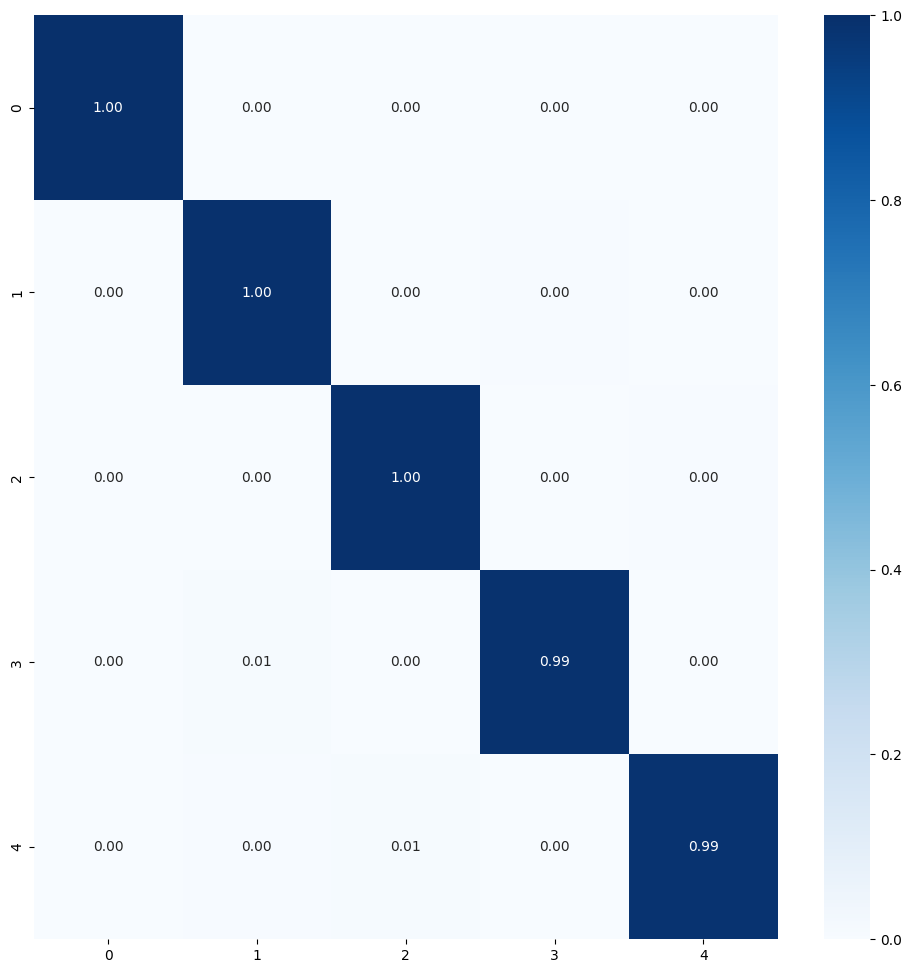


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3822021
Trainable params: 1644805
Non-trainable params: 2177216
Epoch 1/50
164/164 [==============================] - 39s 178ms/step - loss: 1.2291 - accuracy: 0.8829 - val_loss: 1.0386 - val_accuracy: 0.9688 - lr: 1.0000e-04
Epoch 2/50
164/164 [==============================] - 27s 165ms/step - loss: 0.9711 - accuracy: 0.9699 - val_loss: 0.9137 - val_accuracy: 0.9911 - lr: 1.0000e-04
Epoch 3/50
164/164 [==============================] - 26s 158ms/step - loss: 0.9210 - accuracy: 0.9805 - val_loss: 0.8928 - val_accuracy: 0.9920 - lr: 1.0000e-04
Epoch 4/50
164/164 [==============================] - 27s 161ms/step - loss: 0.8869 - accuracy: 0.9893 - val_loss: 0.8682 - val_accuracy: 0.9937 - lr: 1.0000e-04
Epoch 5/50
164/164 [==============================] - 28s 161ms/step - loss: 0.8574 - accuracy: 0.9923 - val_loss: 0.8537 - val_accuracy: 0.9946 - lr: 1.0000e-04
Epoch 6/50
164/164 [==============================] - 28s 170ms/step - los

Model and History saved...
165/165 [==============================] - 21s 128ms/step - loss: 0.1847 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.18472853302955627
36/36 [==============================] - 5s 123ms/step - loss: 0.2145 - accuracy: 0.9947
Validation Accuracy: 0.9946666955947876
Validation Log Loss: 0.2144687920808792
36/36 [==============================] - 5s 123ms/step - loss: 0.2127 - accuracy: 0.9947
Test Accuracy: 0.9946666955947876
Test Log Loss: 0.2127317637205124
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 224   0   1   0]
 [  0   0 225   0   0]
 [  0   2   0 223   0]
 [  0   1   2   0 222]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       0.99      1.00 

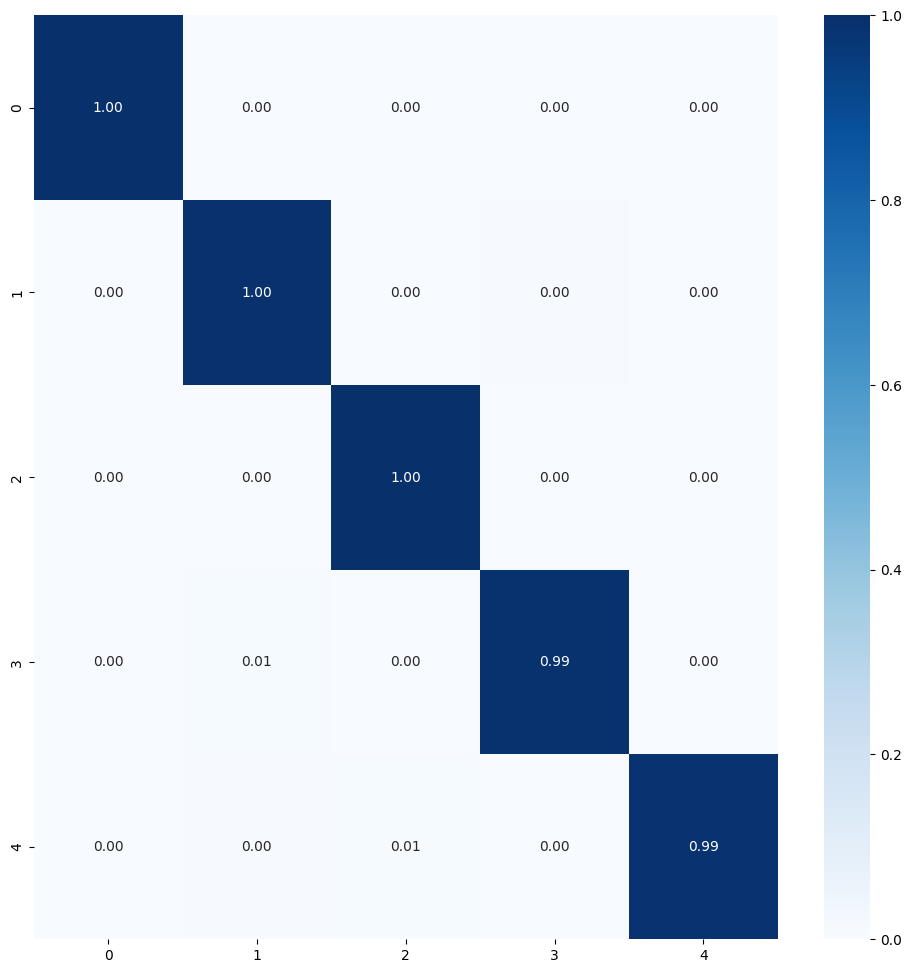


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3822021
Trainable params: 1644805
Non-trainable params: 2177216
Epoch 1/50
164/164 [==============================] - 39s 175ms/step - loss: 1.1996 - accuracy: 0.8915 - val_loss: 1.0618 - val_accuracy: 0.9196 - lr: 1.0000e-04
Epoch 2/50
164/164 [==============================] - 27s 166ms/step - loss: 0.9584 - accuracy: 0.9718 - val_loss: 0.9107 - val_accuracy: 0.9929 - lr: 1.0000e-04
Epoch 3/50
164/164 [==============================] - 27s 160ms/step - loss: 0.9117 - accuracy: 0.9852 - val_loss: 0.8961 - val_accuracy: 0.9866 - lr: 1.0000e-04
Epoch 4/50
164/164 [==============================] - 27s 162ms/step - loss: 0.8872 - accuracy: 0.9885 - val_loss: 0.8568 - val_accuracy: 0.9946 - lr: 1.0000e-04
Epoch 5/50
164/164 [==============================] - 27s 156ms/step - loss: 0.8570 - accuracy: 0.9914 - val_loss: 0.8805 - val_accuracy: 0.9777 - lr: 1.0000e-04
Epoch 6/50
164/164 [==============================] - 26s 157ms/step - los

Model and History saved...
165/165 [==============================] - 23s 134ms/step - loss: 0.2149 - accuracy: 0.9922
Train Accuracy: 0.9921904802322388
Train Log Loss: 0.21485914289951324
36/36 [==============================] - 5s 136ms/step - loss: 0.2755 - accuracy: 0.9796
Validation Accuracy: 0.9795555472373962
Validation Log Loss: 0.27551135420799255
36/36 [==============================] - 5s 128ms/step - loss: 0.2954 - accuracy: 0.9760
Test Accuracy: 0.9760000109672546
Test Log Loss: 0.2954143285751343
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 225   0   0   0]
 [  0   0 225   0   0]
 [  0   2   0 223   0]
 [  1   1  23   0 200]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2      

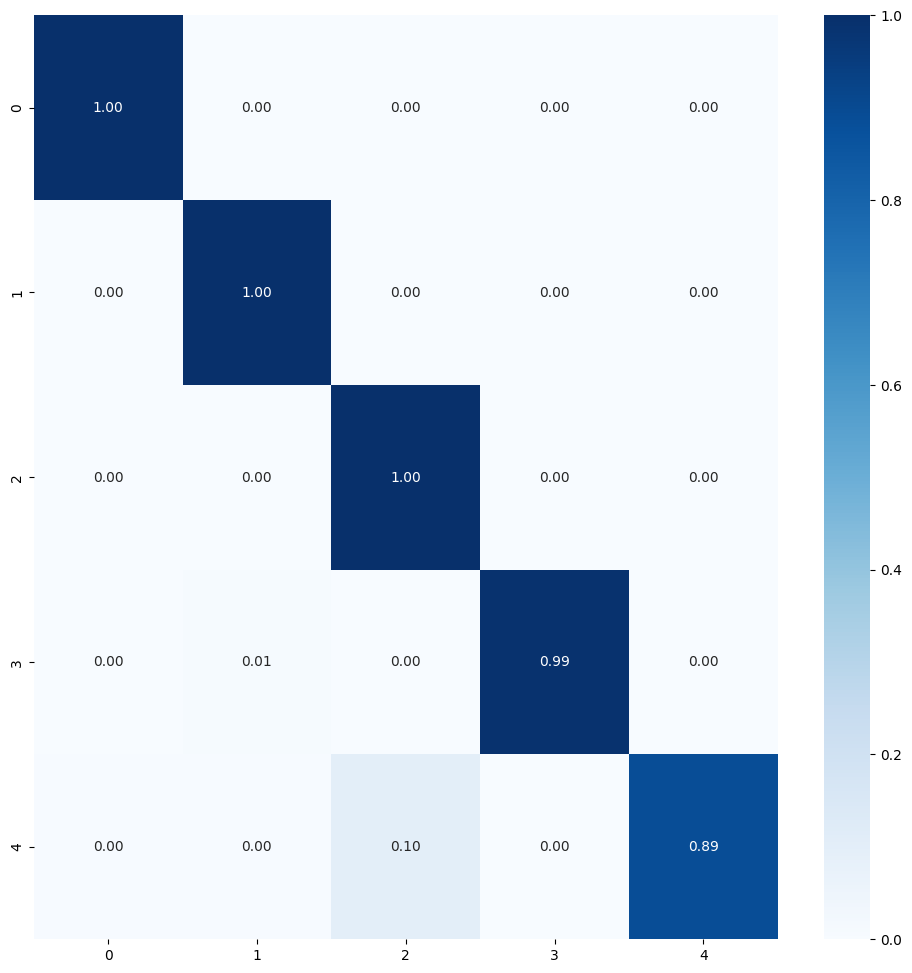

Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9973214268684387
/nTest Metrics
test_acc_list: [0.9946666955947876, 0.995555579662323, 0.9937777519226074, 0.9946666955947876, 0.9760000109672546]
Average Test Accuracy with 5-fold: 0.9909333467483521
test_loss_list: [0.20786979794502258, 0.18800029158592224, 0.21016782522201538, 0.2127317637205124, 0.2954143285751343]
Average Test Log Loss with 5-fold: 0.22283680140972137

Precision List: [0.9946822250192294, 0.9955866750208855, 0.9937971985600036, 0.9947018565135306, 0.9779350782036449]
Average Precision List with 5-fold: 0.9913406066634588
Recall List: [0.9946666666666667, 0.9955555555555555, 0.9937777777777776, 0.9946666666666667, 0.976]
Average Recall List with 5-fold: 0.9909333333333332
F1 Score List: [0.9946685938160404, 0.9955574477616727, 0.993777694374405, 0.9946665479688453, 0.9758493161211195]
Average F1 Score List with 5-fold: 0.9909039200084166

Metrics List Store

test_acc_list_all = [0.99

In [17]:
%%time

num_classes = 5
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/6
name_save_model: fusion_MobileNet_tf_optimized 6
Found 6300 images belonging to 6 classes.
Found 1350 images belonging to 6 classes.
Found 1350 images belonging to 6 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3822150
Trainable params: 1644934
Non-trainable params: 2177216
Epoch 1/50
196/196 [==============================] - 46s 180ms/step - loss: 1.2586 - accuracy: 0.8724 - val_loss: 1.0260 - val_accuracy: 0.9501 - lr: 1.0000e-04
Epoch 2/50
196/196 [==============================] - 33s 169ms/step - loss: 0.9663 - accuracy: 0.9697 - val_loss: 0.9095 - val_accuracy: 0.9851 - lr: 1.0000e-04
Epoch 3/50
196/196 [==============================] - 37s 190ms/step - loss: 0.9136 - accuracy: 0.9797 - val_loss: 0.8734 - val_accuracy: 0.9948 - lr: 1.0000e-04
Epoch 4/50
196/196 [==============================] -

Model and History saved...
197/197 [==============================] - 26s 132ms/step - loss: 0.0264 - accuracy: 0.9998
Train Accuracy: 0.9998412728309631
Train Log Loss: 0.026389194652438164
43/43 [==============================] - 6s 128ms/step - loss: 0.0625 - accuracy: 0.9933
Validation Accuracy: 0.9933333396911621
Validation Log Loss: 0.0624622143805027
43/43 [==============================] - 6s 137ms/step - loss: 0.0705 - accuracy: 0.9941
Test Accuracy: 0.9940740466117859
Test Log Loss: 0.07053716480731964
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 224   1   0   0   0]
 [  0   0 224   0   0   1]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1 

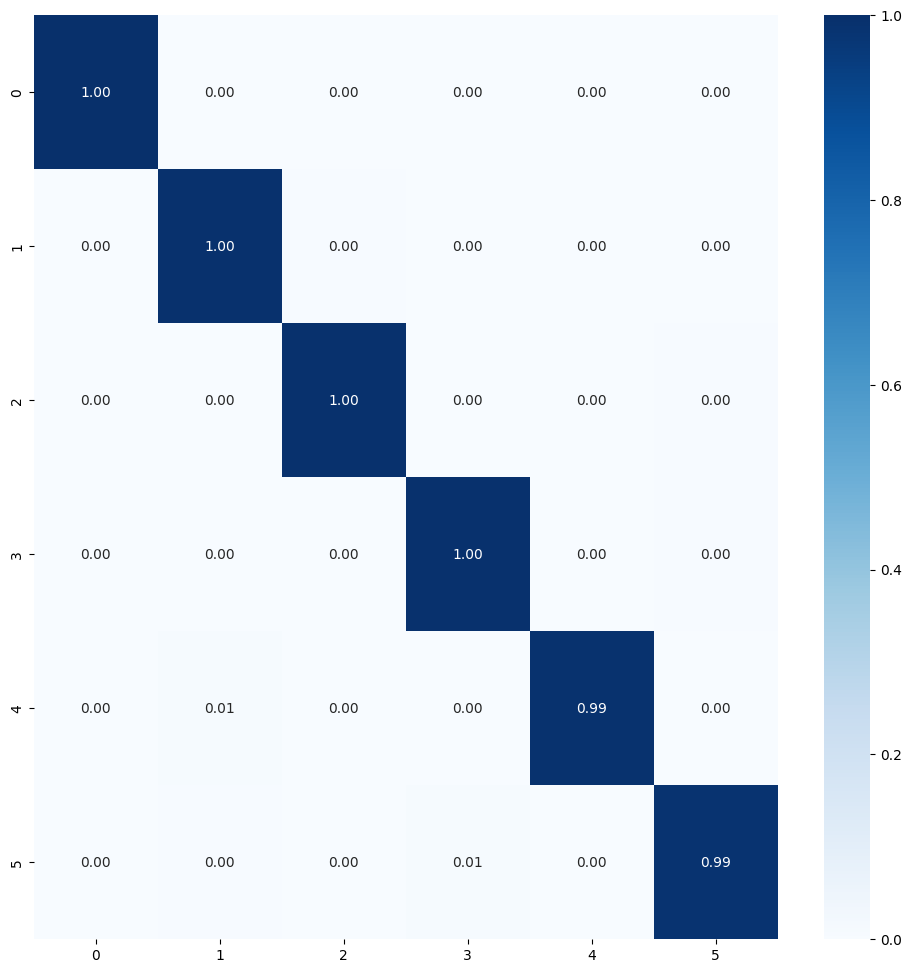


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3822150
Trainable params: 1644934
Non-trainable params: 2177216
Epoch 1/50
196/196 [==============================] - 47s 190ms/step - loss: 1.2879 - accuracy: 0.8661 - val_loss: 1.0725 - val_accuracy: 0.9144 - lr: 1.0000e-04
Epoch 2/50
196/196 [==============================] - 32s 163ms/step - loss: 0.9744 - accuracy: 0.9652 - val_loss: 0.9076 - val_accuracy: 0.9881 - lr: 1.0000e-04
Epoch 3/50
196/196 [==============================] - 33s 170ms/step - loss: 0.9162 - accuracy: 0.9834 - val_loss: 0.8810 - val_accuracy: 0.9933 - lr: 1.0000e-04
Epoch 4/50
196/196 [==============================] - 32s 161ms/step - loss: 0.8809 - accuracy: 0.9882 - val_loss: 0.8617 - val_accuracy: 0.9926 - lr: 1.0000e-04
Epoch 5/50
196/196 [==============================] - 32s 164ms/step - loss: 0.8462 - accuracy: 0.9943 - val_loss: 0.8403 - val_accuracy: 0.9940 - lr: 1.0000e-04
Epoch 6/50
196/196 [==============================] - 33s 166ms/step - los

Model and History saved...
197/197 [==============================] - 27s 131ms/step - loss: 0.0214 - accuracy: 0.9998
Train Accuracy: 0.9998412728309631
Train Log Loss: 0.021362701430916786
43/43 [==============================] - 7s 149ms/step - loss: 0.0558 - accuracy: 0.9919
Validation Accuracy: 0.9918518662452698
Validation Log Loss: 0.05575348436832428
43/43 [==============================] - 6s 124ms/step - loss: 0.0570 - accuracy: 0.9919
Test Accuracy: 0.9918518662452698
Test Log Loss: 0.05702655762434006
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 224   1   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 220   0   5]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1

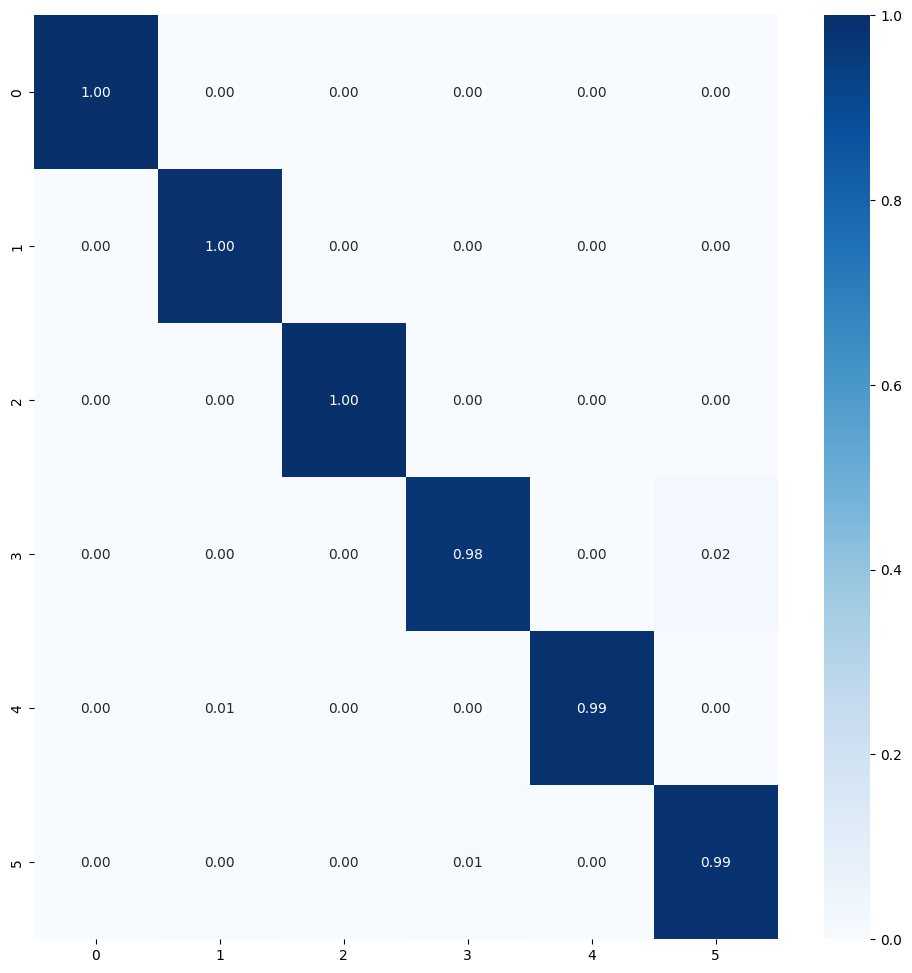


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3822150
Trainable params: 1644934
Non-trainable params: 2177216
Epoch 1/50
196/196 [==============================] - 47s 193ms/step - loss: 1.2903 - accuracy: 0.8641 - val_loss: 1.0050 - val_accuracy: 0.9606 - lr: 1.0000e-04
Epoch 2/50
196/196 [==============================] - 31s 159ms/step - loss: 0.9691 - accuracy: 0.9676 - val_loss: 0.9256 - val_accuracy: 0.9814 - lr: 1.0000e-04
Epoch 3/50
196/196 [==============================] - 34s 168ms/step - loss: 0.9116 - accuracy: 0.9837 - val_loss: 0.8892 - val_accuracy: 0.9881 - lr: 1.0000e-04
Epoch 4/50
196/196 [==============================] - 37s 183ms/step - loss: 0.8842 - accuracy: 0.9872 - val_loss: 0.8592 - val_accuracy: 0.9948 - lr: 1.0000e-04
Epoch 5/50
196/196 [==============================] - 34s 176ms/step - loss: 0.8493 - accuracy: 0.9920 - val_loss: 0.8362 - val_accuracy: 0.9926 - lr: 1.0000e-04
Epoch 6/50
196/196 [==============================] - 36s 183ms/step - los

Model and History saved...
197/197 [==============================] - 28s 138ms/step - loss: 0.0242 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.024196302518248558
43/43 [==============================] - 6s 138ms/step - loss: 0.0540 - accuracy: 0.9948
Validation Accuracy: 0.9948148131370544
Validation Log Loss: 0.05400721728801727
43/43 [==============================] - 5s 93ms/step - loss: 0.0602 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.0601632297039032
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 225   0   0]
 [  0   2   0   0 223   0]
 [  0   1   0   3   0 221]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1

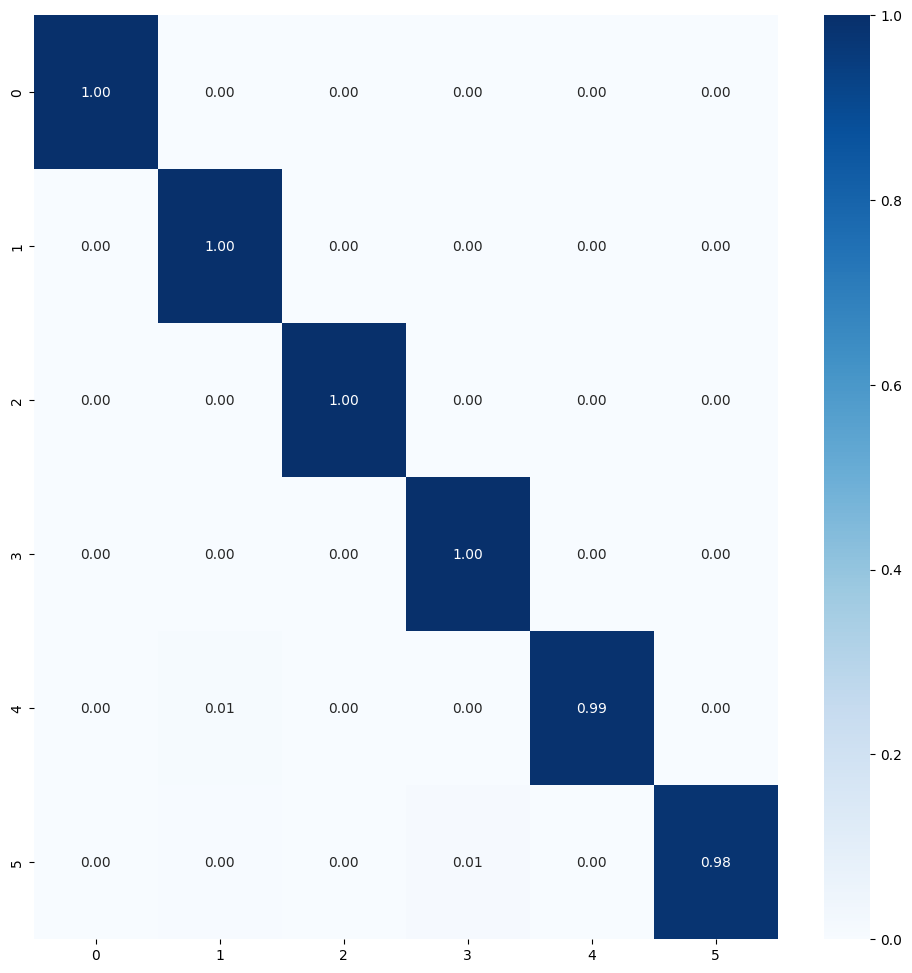


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3822150
Trainable params: 1644934
Non-trainable params: 2177216
Epoch 1/50
196/196 [==============================] - 51s 205ms/step - loss: 1.2522 - accuracy: 0.8714 - val_loss: 1.0341 - val_accuracy: 0.9375 - lr: 1.0000e-04
Epoch 2/50
196/196 [==============================] - 29s 145ms/step - loss: 0.9646 - accuracy: 0.9711 - val_loss: 0.9233 - val_accuracy: 0.9799 - lr: 1.0000e-04
Epoch 3/50
196/196 [==============================] - 27s 137ms/step - loss: 0.9129 - accuracy: 0.9821 - val_loss: 0.8955 - val_accuracy: 0.9814 - lr: 1.0000e-04
Epoch 4/50
196/196 [==============================] - 33s 169ms/step - loss: 0.8781 - accuracy: 0.9876 - val_loss: 0.8531 - val_accuracy: 0.9948 - lr: 1.0000e-04
Epoch 5/50
196/196 [==============================] - 33s 168ms/step - loss: 0.8432 - accuracy: 0.9922 - val_loss: 0.8333 - val_accuracy: 0.9948 - lr: 1.0000e-04
Epoch 6/50
196/196 [==============================] - 31s 154ms/step - los

Model and History saved...
197/197 [==============================] - 26s 127ms/step - loss: 0.0255 - accuracy: 0.9995
Train Accuracy: 0.9995238184928894
Train Log Loss: 0.02554686926305294
43/43 [==============================] - 6s 131ms/step - loss: 0.0716 - accuracy: 0.9926
Validation Accuracy: 0.9925925731658936
Validation Log Loss: 0.07157522439956665
43/43 [==============================] - 6s 129ms/step - loss: 0.0815 - accuracy: 0.9919
Test Accuracy: 0.9918518662452698
Test Log Loss: 0.08148716390132904
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 225   0   0]
 [  0   2   0   0 223   0]
 [  0   1   0   8   0 216]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1 

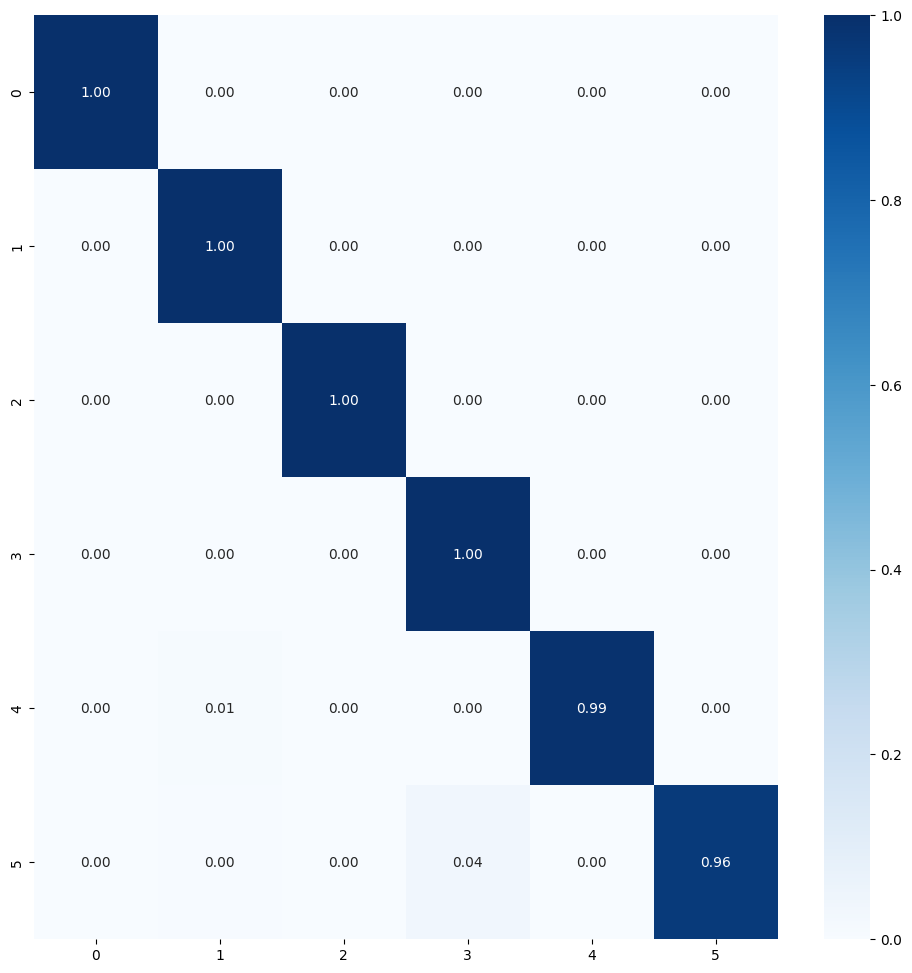


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3822150
Trainable params: 1644934
Non-trainable params: 2177216
Epoch 1/50
196/196 [==============================] - 44s 177ms/step - loss: 1.2828 - accuracy: 0.8647 - val_loss: 1.0513 - val_accuracy: 0.9330 - lr: 1.0000e-04
Epoch 2/50
196/196 [==============================] - 34s 171ms/step - loss: 0.9713 - accuracy: 0.9710 - val_loss: 0.9664 - val_accuracy: 0.9621 - lr: 1.0000e-04
Epoch 3/50
196/196 [==============================] - 36s 185ms/step - loss: 0.9193 - accuracy: 0.9802 - val_loss: 0.8786 - val_accuracy: 0.9926 - lr: 1.0000e-04
Epoch 4/50
196/196 [==============================] - 32s 164ms/step - loss: 0.8799 - accuracy: 0.9887 - val_loss: 0.8567 - val_accuracy: 0.9933 - lr: 1.0000e-04
Epoch 5/50
196/196 [==============================] - 32s 161ms/step - loss: 0.8500 - accuracy: 0.9914 - val_loss: 0.8374 - val_accuracy: 0.9948 - lr: 1.0000e-04
Epoch 6/50
196/196 [==============================] - 32s 161ms/step - los

Model and History saved...
197/197 [==============================] - 27s 136ms/step - loss: 0.7420 - accuracy: 0.9997
Train Accuracy: 0.9996825456619263
Train Log Loss: 0.7419863939285278
43/43 [==============================] - 6s 136ms/step - loss: 0.7638 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.7638408541679382
43/43 [==============================] - 6s 136ms/step - loss: 0.7597 - accuracy: 0.9933
Test Accuracy: 0.9933333396911621
Test Log Loss: 0.759724497795105
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 222   0   3]
 [  0   2   0   0 223   0]
 [  0   1   0   3   0 221]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1      

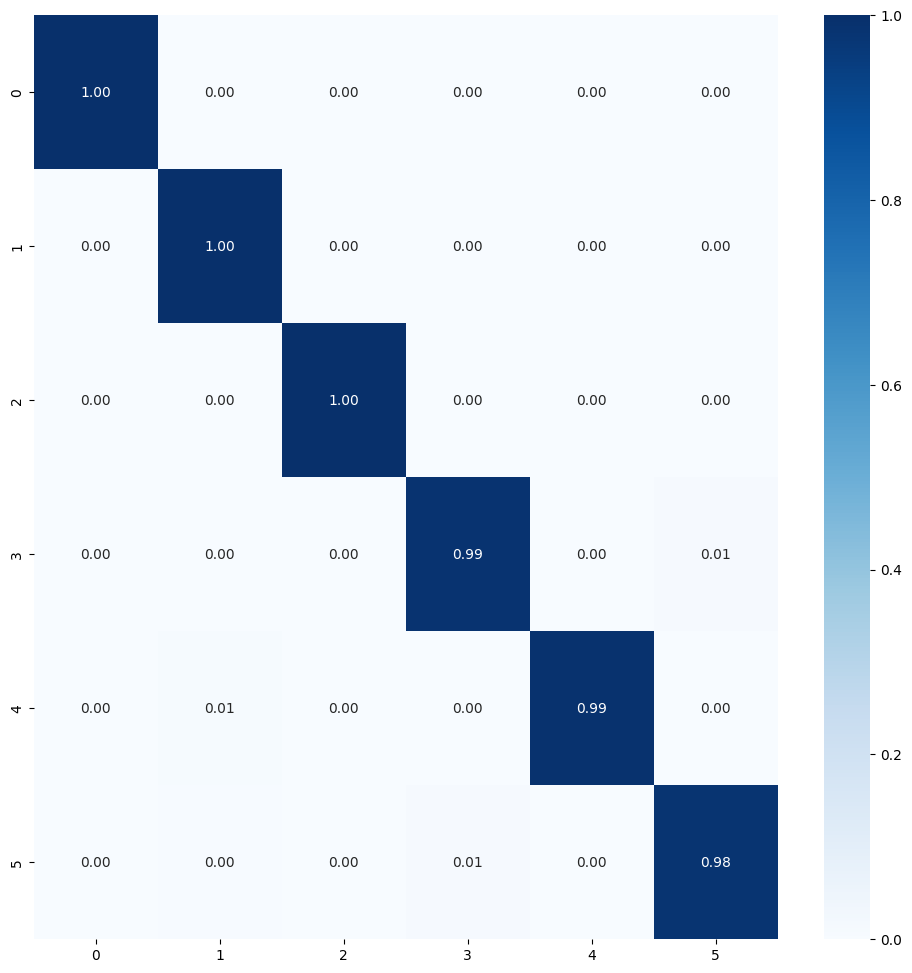

Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.996279776096344
/nTest Metrics
test_acc_list: [0.9940740466117859, 0.9918518662452698, 0.995555579662323, 0.9918518662452698, 0.9933333396911621]
Average Test Accuracy with 5-fold: 0.9933333396911621
test_loss_list: [0.07053716480731964, 0.05702655762434006, 0.0601632297039032, 0.08148716390132904, 0.759724497795105]
Average Test Log Loss with 5-fold: 0.2057877227663994

Precision List: [0.9940935945956705, 0.9918873202468385, 0.9956140350877193, 0.9920845568857767, 0.9933526524644947]
Average Precision List with 5-fold: 0.9934064318560999
Recall List: [0.994074074074074, 0.9918518518518519, 0.9955555555555556, 0.9918518518518519, 0.9933333333333333]
Average Recall List with 5-fold: 0.9933333333333334
F1 Score List: [0.9940756616929094, 0.9918516319269749, 0.995553678551277, 0.9918396309259699, 0.9933316106584426]
Average F1 Score List with 5-fold: 0.9933304427511148

Metrics List Store

test_acc_list_al

In [18]:
%%time

num_classes = 6
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/7
name_save_model: fusion_MobileNet_tf_optimized 7
Found 7350 images belonging to 7 classes.
Found 1575 images belonging to 7 classes.
Found 1575 images belonging to 7 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3822279
Trainable params: 1645063
Non-trainable params: 2177216
Epoch 1/50
229/229 [==============================] - 53s 189ms/step - loss: 1.2635 - accuracy: 0.8767 - val_loss: 1.0748 - val_accuracy: 0.9171 - lr: 1.0000e-04
Epoch 2/50
229/229 [==============================] - 39s 171ms/step - loss: 0.9495 - accuracy: 0.9735 - val_loss: 0.9152 - val_accuracy: 0.9860 - lr: 1.0000e-04
Epoch 3/50
229/229 [==============================] - 38s 167ms/step - loss: 0.8997 - accuracy: 0.9835 - val_loss: 0.8791 - val_accuracy: 0.9923 - lr: 1.0000e-04
Epoch 4/50
229/229 [==================

Model and History saved...
230/230 [==============================] - 30s 131ms/step - loss: 0.1382 - accuracy: 0.9638
Train Accuracy: 0.9638095498085022
Train Log Loss: 0.1382223516702652
50/50 [==============================] - 7s 142ms/step - loss: 0.1988 - accuracy: 0.9575
Validation Accuracy: 0.957460343837738
Validation Log Loss: 0.19881464540958405
50/50 [==============================] - 7s 132ms/step - loss: 0.2091 - accuracy: 0.9511
Test Accuracy: 0.9511111378669739
Test Log Loss: 0.20906442403793335
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 224   1   0   0   0]
 [  0   0   0 223   0   0   2]
 [  0   0   0   0 155   0  70]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   0   0 224]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   supp

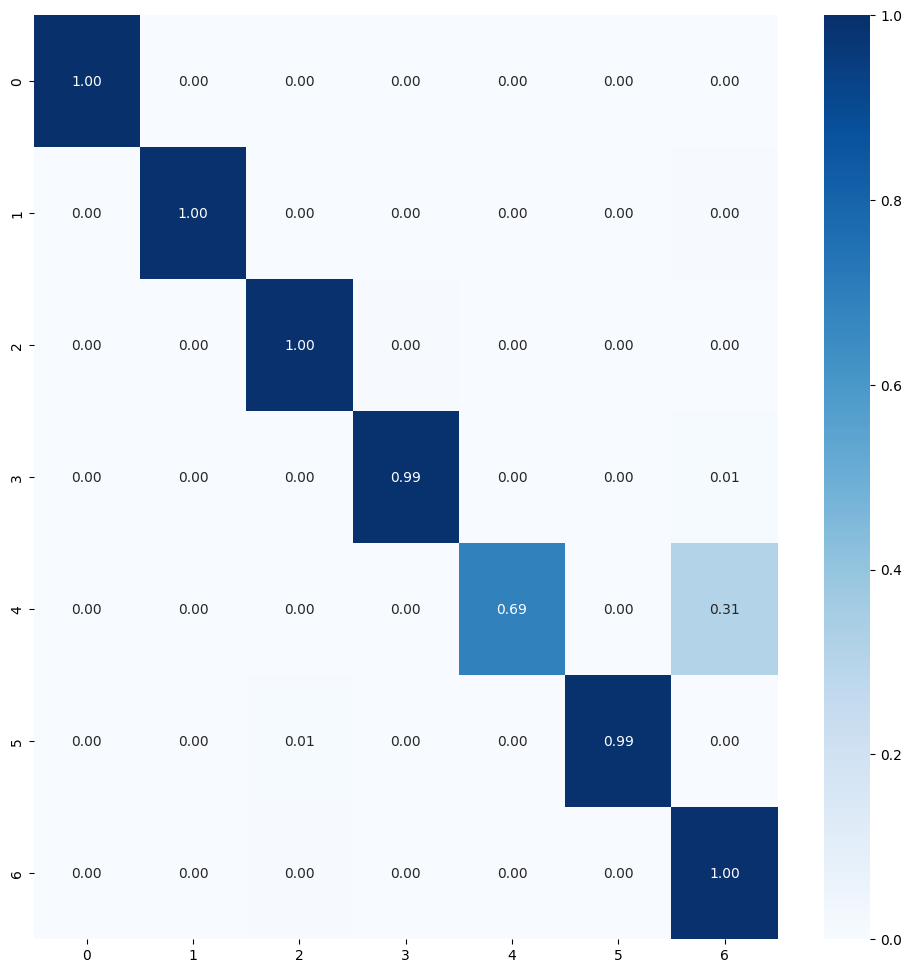


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3822279
Trainable params: 1645063
Non-trainable params: 2177216
Epoch 1/50
229/229 [==============================] - 51s 177ms/step - loss: 1.2863 - accuracy: 0.8713 - val_loss: 0.9952 - val_accuracy: 0.9713 - lr: 1.0000e-04
Epoch 2/50
229/229 [==============================] - 38s 164ms/step - loss: 0.9606 - accuracy: 0.9686 - val_loss: 0.9133 - val_accuracy: 0.9879 - lr: 1.0000e-04
Epoch 3/50
229/229 [==============================] - 37s 162ms/step - loss: 0.8974 - accuracy: 0.9876 - val_loss: 0.8837 - val_accuracy: 0.9917 - lr: 1.0000e-04
Epoch 4/50
229/229 [==============================] - 38s 162ms/step - loss: 0.8613 - accuracy: 0.9917 - val_loss: 0.8539 - val_accuracy: 0.9930 - lr: 1.0000e-04
Epoch 5/50
229/229 [==============================] - 37s 159ms/step - loss: 0.8334 - accuracy: 0.9930 - val_loss: 0.8284 - val_accuracy: 0.9923 - lr: 1.0000e-04
Epoch 6/50
229/229 [==============================] - 37s 160ms/step - los

Model and History saved...
230/230 [==============================] - 34s 139ms/step - loss: 0.0127 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.012651456519961357
50/50 [==============================] - 8s 132ms/step - loss: 0.0580 - accuracy: 0.9930
Validation Accuracy: 0.9930158853530884
Validation Log Loss: 0.057968445122241974
50/50 [==============================] - 7s 143ms/step - loss: 0.0455 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.045479755848646164
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 225   0   0]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   3   0 221]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

      

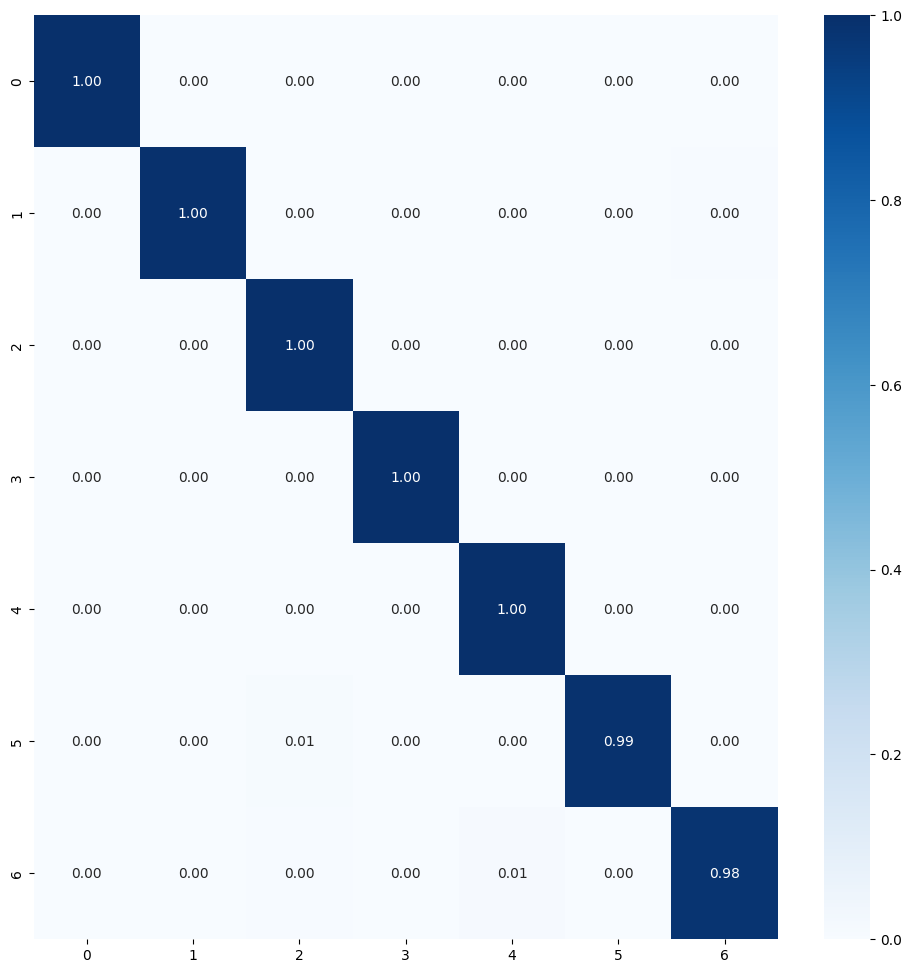


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3822279
Trainable params: 1645063
Non-trainable params: 2177216
Epoch 1/50
229/229 [==============================] - 52s 183ms/step - loss: 1.2969 - accuracy: 0.8609 - val_loss: 1.0096 - val_accuracy: 0.9541 - lr: 1.0000e-04
Epoch 2/50
229/229 [==============================] - 38s 161ms/step - loss: 0.9679 - accuracy: 0.9701 - val_loss: 0.9127 - val_accuracy: 0.9904 - lr: 1.0000e-04
Epoch 3/50
229/229 [==============================] - 39s 172ms/step - loss: 0.9039 - accuracy: 0.9855 - val_loss: 0.8775 - val_accuracy: 0.9923 - lr: 1.0000e-04
Epoch 4/50
229/229 [==============================] - 38s 166ms/step - loss: 0.8699 - accuracy: 0.9885 - val_loss: 0.8511 - val_accuracy: 0.9936 - lr: 1.0000e-04
Epoch 5/50
229/229 [==============================] - 43s 188ms/step - loss: 0.8368 - accuracy: 0.9936 - val_loss: 0.8382 - val_accuracy: 0.9866 - lr: 1.0000e-04
Epoch 6/50
229/229 [==============================] - 38s 166ms/step - los

Model and History saved...
230/230 [==============================] - 31s 135ms/step - loss: 0.7457 - accuracy: 0.9997
Train Accuracy: 0.9997279047966003
Train Log Loss: 0.7457441687583923
50/50 [==============================] - 7s 132ms/step - loss: 0.7695 - accuracy: 0.9949
Validation Accuracy: 0.9949206113815308
Validation Log Loss: 0.7694514989852905
50/50 [==============================] - 8s 141ms/step - loss: 0.7716 - accuracy: 0.9943
Test Accuracy: 0.9942857027053833
Test Log Loss: 0.7716050744056702
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 223   2   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   0   0   3   0 222]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   suppo

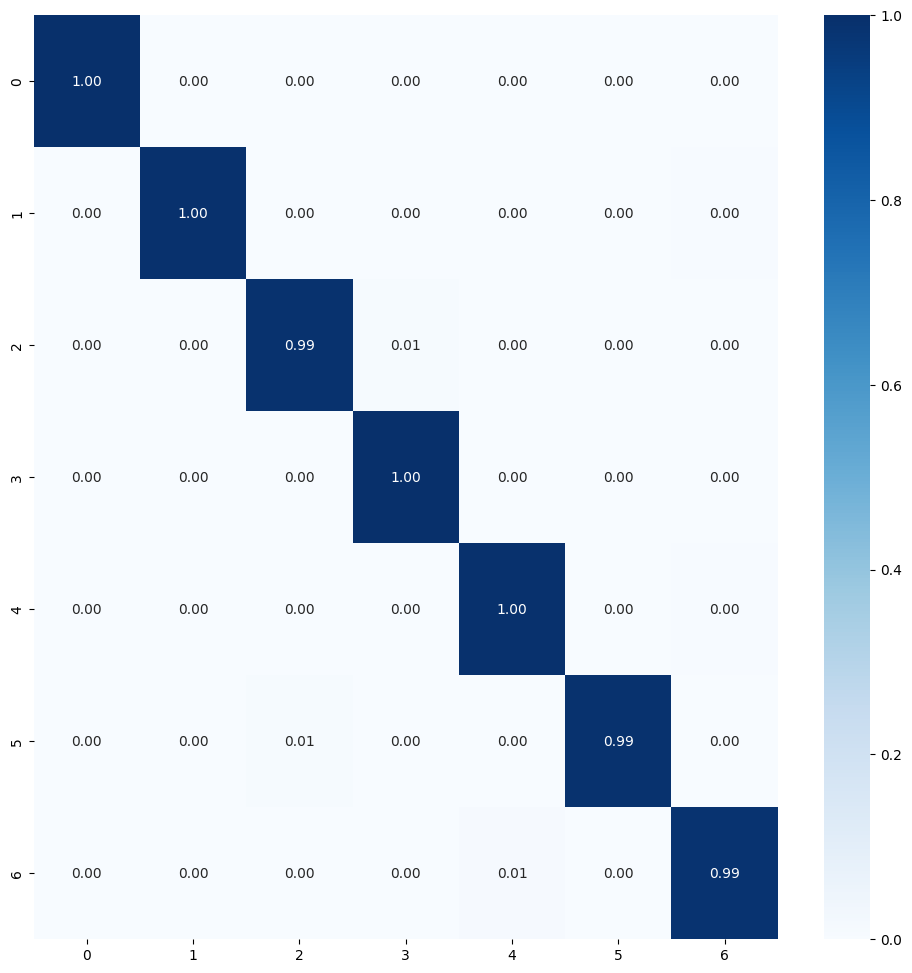


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3822279
Trainable params: 1645063
Non-trainable params: 2177216
Epoch 1/50
229/229 [==============================] - 56s 197ms/step - loss: 1.2480 - accuracy: 0.8834 - val_loss: 1.0009 - val_accuracy: 0.9605 - lr: 1.0000e-04
Epoch 2/50
229/229 [==============================] - 44s 192ms/step - loss: 0.9563 - accuracy: 0.9732 - val_loss: 0.9124 - val_accuracy: 0.9866 - lr: 1.0000e-04
Epoch 3/50
229/229 [==============================] - 40s 169ms/step - loss: 0.9033 - accuracy: 0.9836 - val_loss: 0.8802 - val_accuracy: 0.9923 - lr: 1.0000e-04
Epoch 4/50
229/229 [==============================] - 42s 181ms/step - loss: 0.8625 - accuracy: 0.9915 - val_loss: 0.8474 - val_accuracy: 0.9936 - lr: 1.0000e-04
Epoch 5/50
229/229 [==============================] - 38s 163ms/step - loss: 0.8346 - accuracy: 0.9919 - val_loss: 0.8208 - val_accuracy: 0.9949 - lr: 1.0000e-04
Epoch 6/50
229/229 [==============================] - 38s 167ms/step - los

Model and History saved...
230/230 [==============================] - 37s 156ms/step - loss: 0.7395 - accuracy: 0.9996
Train Accuracy: 0.9995918273925781
Train Log Loss: 0.7394914627075195
50/50 [==============================] - 8s 147ms/step - loss: 0.7659 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.7658771872520447
50/50 [==============================] - 8s 152ms/step - loss: 0.7760 - accuracy: 0.9943
Test Accuracy: 0.9942857027053833
Test Log Loss: 0.7760235071182251
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 222   0   3]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   2   0 222]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   suppor

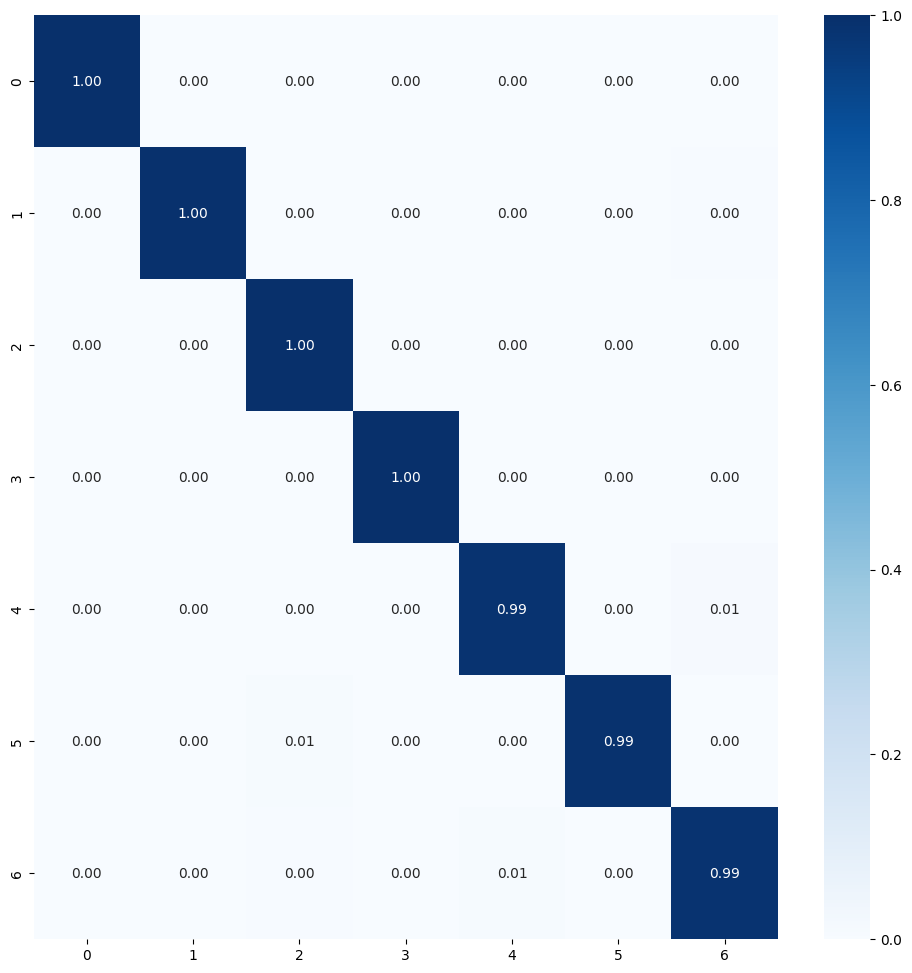


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3822279
Trainable params: 1645063
Non-trainable params: 2177216
Epoch 1/50
229/229 [==============================] - 56s 195ms/step - loss: 1.2772 - accuracy: 0.8744 - val_loss: 1.0534 - val_accuracy: 0.9222 - lr: 1.0000e-04
Epoch 2/50
229/229 [==============================] - 42s 182ms/step - loss: 0.9584 - accuracy: 0.9732 - val_loss: 0.9092 - val_accuracy: 0.9879 - lr: 1.0000e-04
Epoch 3/50
229/229 [==============================] - 43s 187ms/step - loss: 0.9079 - accuracy: 0.9835 - val_loss: 0.8824 - val_accuracy: 0.9936 - lr: 1.0000e-04
Epoch 4/50
229/229 [==============================] - 45s 193ms/step - loss: 0.8666 - accuracy: 0.9898 - val_loss: 0.8552 - val_accuracy: 0.9936 - lr: 1.0000e-04
Epoch 5/50
229/229 [==============================] - 47s 203ms/step - loss: 0.8360 - accuracy: 0.9934 - val_loss: 0.8305 - val_accuracy: 0.9949 - lr: 1.0000e-04
Epoch 6/50
229/229 [==============================] - 45s 192ms/step - los

Model and History saved...
230/230 [==============================] - 30s 126ms/step - loss: 0.4730 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.47302186489105225
50/50 [==============================] - 7s 139ms/step - loss: 0.5056 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.5055726766586304
50/50 [==============================] - 7s 121ms/step - loss: 0.5019 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.5018820762634277
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   1   0   0   0]
 [  0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 225   0   0]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   3   0 221]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0

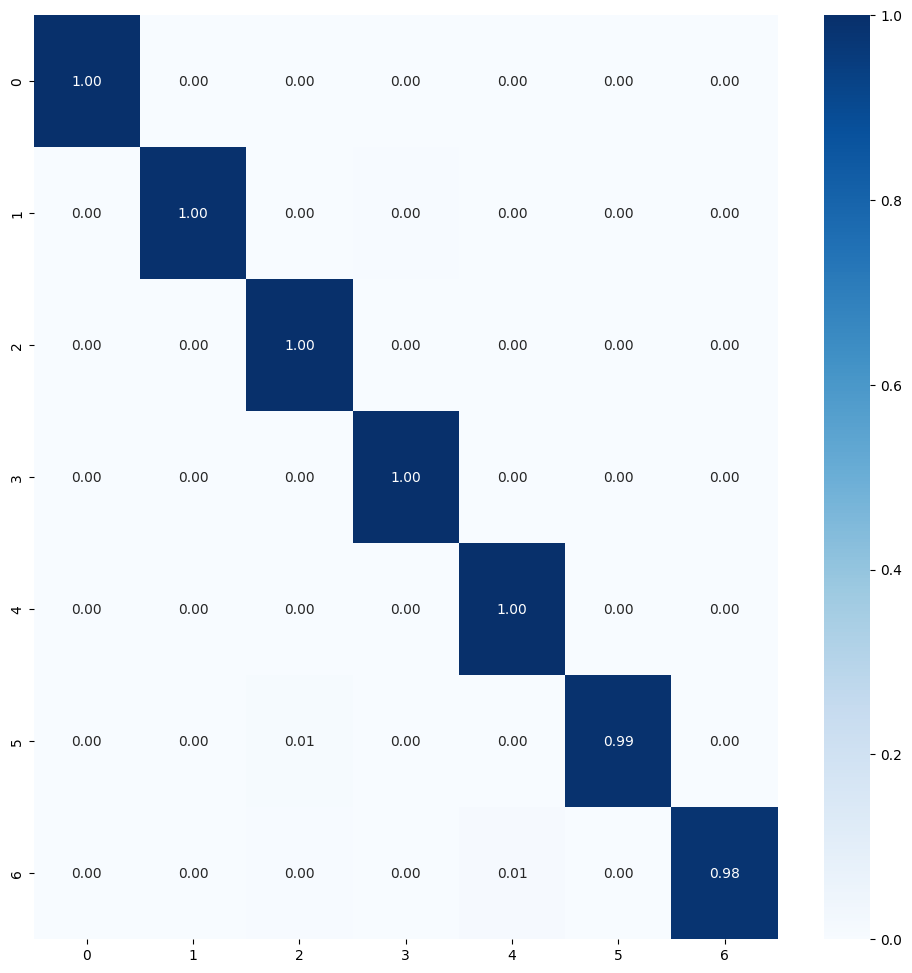

Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9952806234359741
/nTest Metrics
test_acc_list: [0.9511111378669739, 0.995555579662323, 0.9942857027053833, 0.9942857027053833, 0.995555579662323]
Average Test Accuracy with 5-fold: 0.9861587405204773
test_loss_list: [0.20906442403793335, 0.045479755848646164, 0.7716050744056702, 0.7760235071182251, 0.5018820762634277]
Average Test Log Loss with 5-fold: 0.4608109675347805

Precision List: [0.9623612299233759, 0.9955971008602588, 0.9943080154234968, 0.9943163455414769, 0.9956084902521791]
Average Precision List with 5-fold: 0.9884382364001574
Recall List: [0.9511111111111112, 0.9955555555555556, 0.9942857142857143, 0.9942857142857143, 0.9955555555555556]
Average Recall List with 5-fold: 0.9861587301587301
F1 Score List: [0.9502577846245288, 0.9955539753363293, 0.9942870657372015, 0.994289872067806, 0.9955539435593194]
Average F1 Score List with 5-fold: 0.9859885282650371

Metrics List Store

test_acc_list_

In [19]:
%%time

num_classes = 7
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/8
name_save_model: fusion_MobileNet_tf_optimized 8
Found 8400 images belonging to 8 classes.
Found 1800 images belonging to 8 classes.
Found 1800 images belonging to 8 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3822408
Trainable params: 1645192
Non-trainable params: 2177216
Epoch 1/50
262/262 [==============================] - 60s 177ms/step - loss: 1.2841 - accuracy: 0.8751 - val_loss: 1.0773 - val_accuracy: 0.9230 - lr: 1.0000e-04
Epoch 2/50
262/262 [==============================] - 40s 151ms/step - loss: 0.9598 - accuracy: 0.9726 - val_loss: 0.8952 - val_accuracy: 0.9922 - lr: 1.0000e-04
Epoch 3/50
262/262 [==============================] - 41s 152ms/step - loss: 0.9036 - accuracy: 0.9839 - val_loss: 0.8715 - val_accuracy: 0.9927 - lr: 1.0000e-04
Epoch 4/50
262/262 [=========

Model and History saved...
263/263 [==============================] - 37s 139ms/step - loss: 0.7264 - accuracy: 0.9998
Train Accuracy: 0.9997618794441223
Train Log Loss: 0.7264237999916077
57/57 [==============================] - 9s 134ms/step - loss: 0.7545 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.7545472979545593
57/57 [==============================] - 8s 138ms/step - loss: 0.7509 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.7509095668792725
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   1   0   0   0]
 [  0   0 225   0   0   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 224   0   1]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   3   0 221]]
True labels: 1800
Predicted labels: len(predicted_labels)



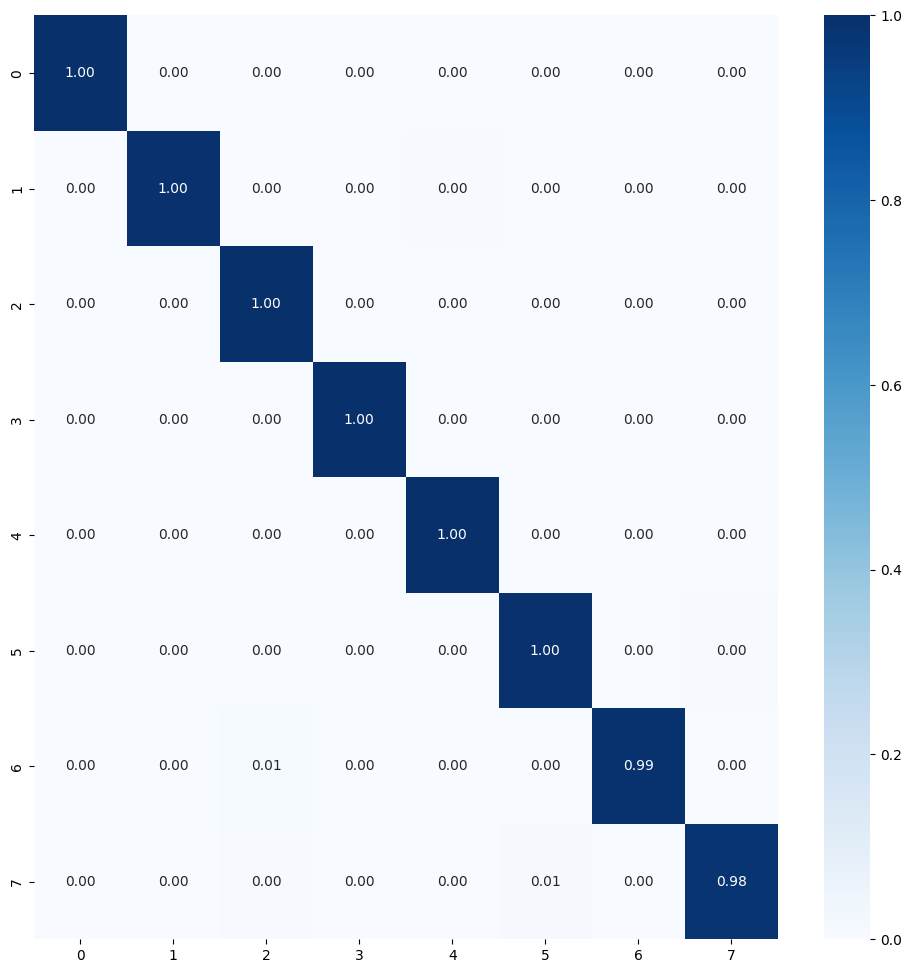


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3822408
Trainable params: 1645192
Non-trainable params: 2177216
Epoch 1/50
262/262 [==============================] - 57s 174ms/step - loss: 1.3003 - accuracy: 0.8688 - val_loss: 0.9775 - val_accuracy: 0.9721 - lr: 1.0000e-04
Epoch 2/50
262/262 [==============================] - 44s 166ms/step - loss: 0.9689 - accuracy: 0.9705 - val_loss: 0.9061 - val_accuracy: 0.9888 - lr: 1.0000e-04
Epoch 3/50
262/262 [==============================] - 44s 169ms/step - loss: 0.9096 - accuracy: 0.9823 - val_loss: 0.8720 - val_accuracy: 0.9927 - lr: 1.0000e-04
Epoch 4/50
262/262 [==============================] - 45s 172ms/step - loss: 0.8610 - accuracy: 0.9903 - val_loss: 0.8516 - val_accuracy: 0.9911 - lr: 1.0000e-04
Epoch 5/50
262/262 [==============================] - 44s 166ms/step - loss: 0.8241 - accuracy: 0.9940 - val_loss: 0.8207 - val_accuracy: 0.9950 - lr: 1.0000e-04
Epoch 6/50
262/262 [==============================] - 43s 165ms/step - los

Model and History saved...
263/263 [==============================] - 33s 125ms/step - loss: 0.5860 - accuracy: 0.9999
Train Accuracy: 0.9998809695243835
Train Log Loss: 0.5860169529914856
57/57 [==============================] - 9s 143ms/step - loss: 0.6115 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.6114926338195801
57/57 [==============================] - 8s 136ms/step - loss: 0.6093 - accuracy: 0.9950
Test Accuracy: 0.9950000047683716
Test Log Loss: 0.6092591881752014
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 224   0   1   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 224   0   1]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   3   0 221]]
True labels: 1800
Predicted labels: len(predicted_labels)


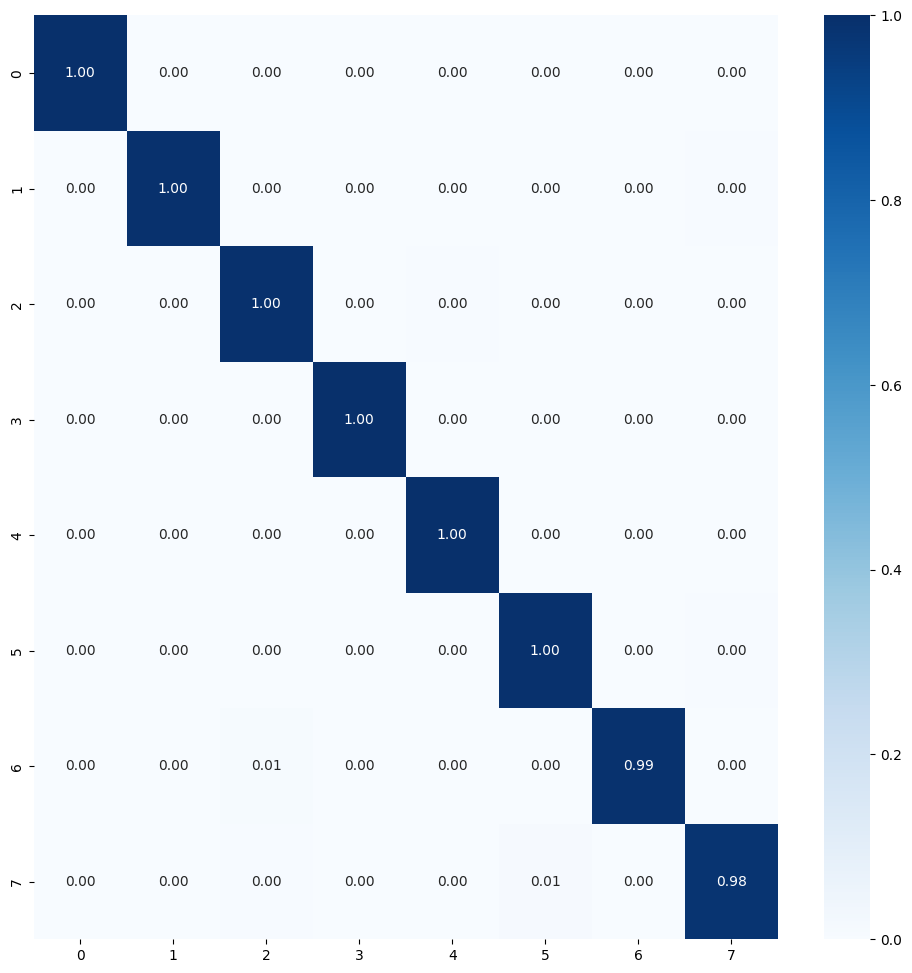


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3822408
Trainable params: 1645192
Non-trainable params: 2177216
Epoch 1/50
262/262 [==============================] - 51s 153ms/step - loss: 1.2574 - accuracy: 0.8767 - val_loss: 0.9971 - val_accuracy: 0.9537 - lr: 1.0000e-04
Epoch 2/50
262/262 [==============================] - 44s 167ms/step - loss: 0.9575 - accuracy: 0.9706 - val_loss: 0.8934 - val_accuracy: 0.9922 - lr: 1.0000e-04
Epoch 3/50
262/262 [==============================] - 44s 169ms/step - loss: 0.8966 - accuracy: 0.9859 - val_loss: 0.8612 - val_accuracy: 0.9939 - lr: 1.0000e-04
Epoch 4/50
262/262 [==============================] - 44s 165ms/step - loss: 0.8510 - accuracy: 0.9915 - val_loss: 0.8662 - val_accuracy: 0.9816 - lr: 1.0000e-04
Epoch 5/50
262/262 [==============================] - 45s 169ms/step - loss: 0.8224 - accuracy: 0.9926 - val_loss: 0.8101 - val_accuracy: 0.9933 - lr: 1.0000e-04
Epoch 6/50
262/262 [==============================] - 46s 173ms/step - los

Model and History saved...
263/263 [==============================] - 36s 134ms/step - loss: 0.0082 - accuracy: 0.9999
Train Accuracy: 0.9998809695243835
Train Log Loss: 0.008155356161296368
57/57 [==============================] - 8s 132ms/step - loss: 0.0366 - accuracy: 0.9950
Validation Accuracy: 0.9950000047683716
Validation Log Loss: 0.03659580647945404
57/57 [==============================] - 7s 116ms/step - loss: 0.0407 - accuracy: 0.9928
Test Accuracy: 0.9927777647972107
Test Log Loss: 0.04066993668675423
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   1   0   0   0]
 [  0   0 221   1   3   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   1   0 223   0   1]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   3   0 221]]
True labels: 1800
Predicted labels: len(predicted_lab

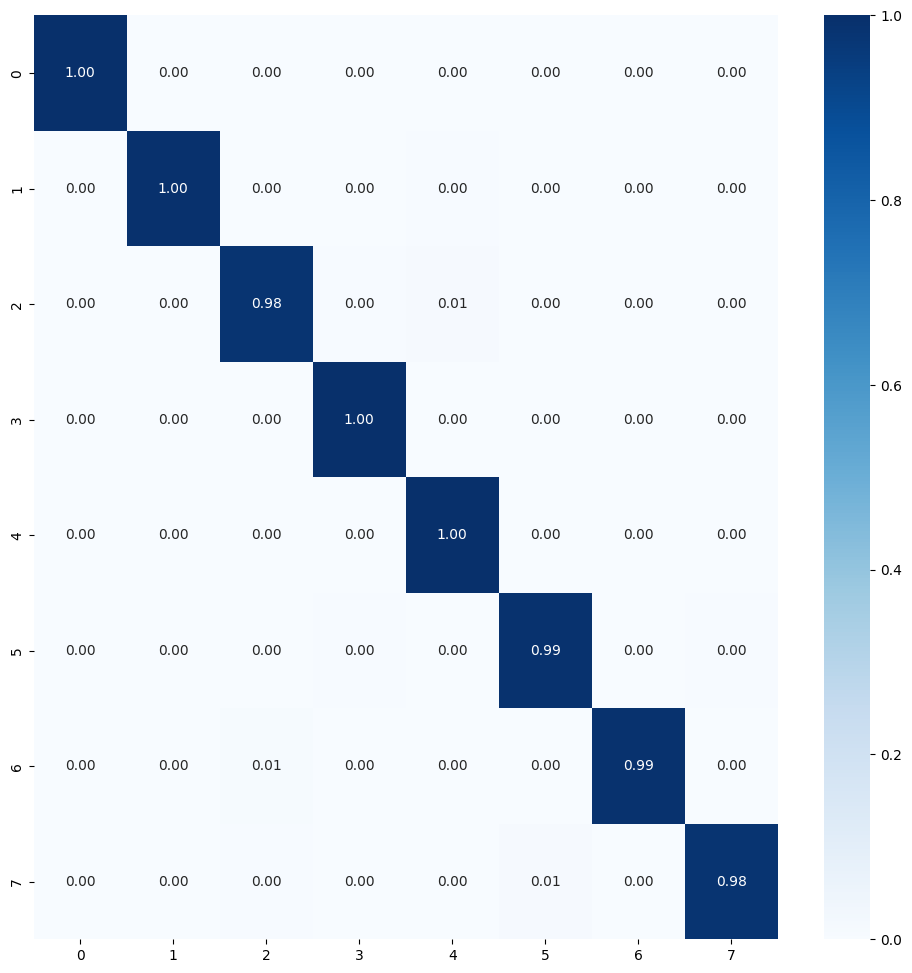


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3822408
Trainable params: 1645192
Non-trainable params: 2177216
Epoch 1/50
262/262 [==============================] - 58s 187ms/step - loss: 1.2999 - accuracy: 0.8682 - val_loss: 1.0466 - val_accuracy: 0.9369 - lr: 1.0000e-04
Epoch 2/50
262/262 [==============================] - 44s 168ms/step - loss: 0.9675 - accuracy: 0.9692 - val_loss: 0.9156 - val_accuracy: 0.9894 - lr: 1.0000e-04
Epoch 3/50
262/262 [==============================] - 40s 152ms/step - loss: 0.9021 - accuracy: 0.9842 - val_loss: 0.9167 - val_accuracy: 0.9766 - lr: 1.0000e-04
Epoch 4/50
262/262 [==============================] - 39s 147ms/step - loss: 0.8634 - accuracy: 0.9909 - val_loss: 0.8518 - val_accuracy: 0.9933 - lr: 1.0000e-04
Epoch 5/50
262/262 [==============================] - 45s 169ms/step - loss: 0.8275 - accuracy: 0.9925 - val_loss: 0.8290 - val_accuracy: 0.9911 - lr: 1.0000e-04
Epoch 6/50
262/262 [==============================] - 43s 162ms/step - los

Model and History saved...
263/263 [==============================] - 34s 124ms/step - loss: 0.5463 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.5462799072265625
57/57 [==============================] - 6s 100ms/step - loss: 0.5762 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.5761812329292297
57/57 [==============================] - 8s 130ms/step - loss: 0.5667 - accuracy: 0.9972
Test Accuracy: 0.9972222447395325
Test Log Loss: 0.5667057037353516
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 225   0   0   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   2   0   0   0 223   0]
 [  0   0   0   0   0   2   0 223]]
True labels: 1800
Predicted labels: len(predicted_labels)

Classification

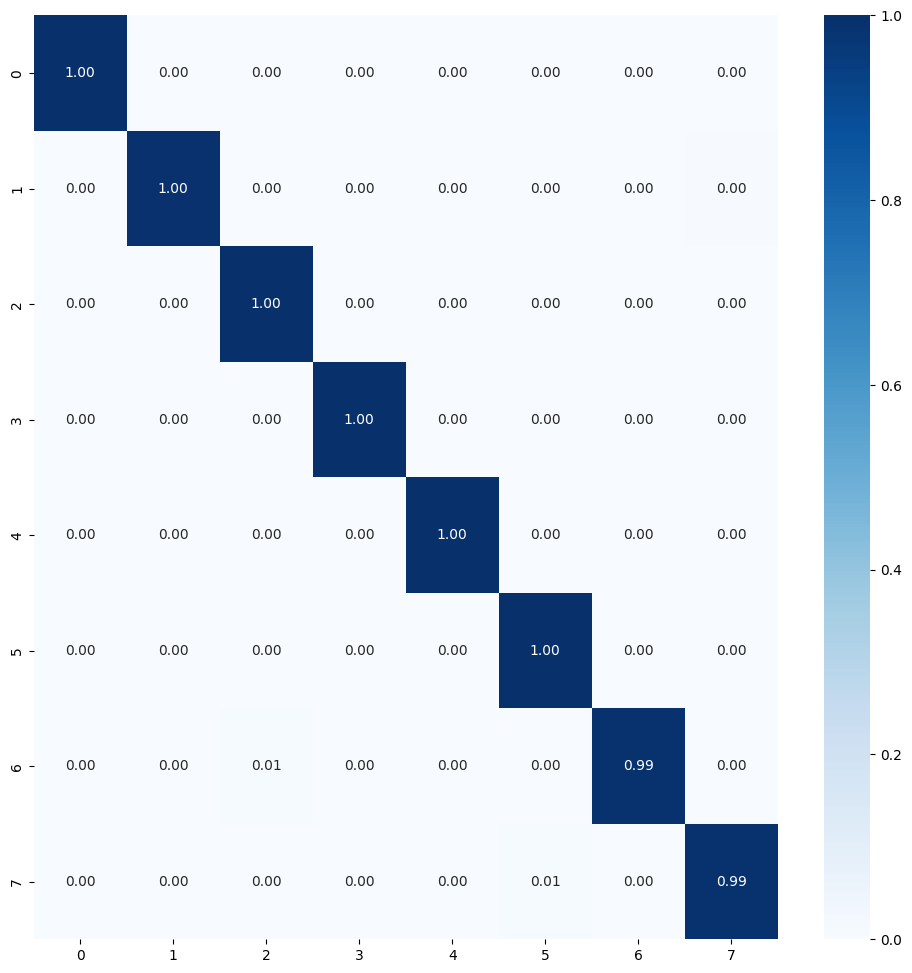


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3822408
Trainable params: 1645192
Non-trainable params: 2177216
Epoch 1/50
262/262 [==============================] - 55s 174ms/step - loss: 1.2852 - accuracy: 0.8708 - val_loss: 0.9619 - val_accuracy: 0.9788 - lr: 1.0000e-04
Epoch 2/50
262/262 [==============================] - 45s 168ms/step - loss: 0.9707 - accuracy: 0.9668 - val_loss: 0.8939 - val_accuracy: 0.9933 - lr: 1.0000e-04
Epoch 3/50
262/262 [==============================] - 48s 181ms/step - loss: 0.9013 - accuracy: 0.9855 - val_loss: 0.8697 - val_accuracy: 0.9916 - lr: 1.0000e-04
Epoch 4/50
262/262 [==============================] - 41s 154ms/step - loss: 0.8620 - accuracy: 0.9900 - val_loss: 0.8437 - val_accuracy: 0.9927 - lr: 1.0000e-04
Epoch 5/50
262/262 [==============================] - 43s 161ms/step - loss: 0.8308 - accuracy: 0.9918 - val_loss: 0.8108 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 6/50
262/262 [==============================] - 34s 126ms/step - los

Model and History saved...
263/263 [==============================] - 42s 159ms/step - loss: 0.2437 - accuracy: 0.9999
Train Accuracy: 0.9998809695243835
Train Log Loss: 0.24373795092105865
57/57 [==============================] - 9s 147ms/step - loss: 0.2700 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.2699522376060486
57/57 [==============================] - 10s 167ms/step - loss: 0.2747 - accuracy: 0.9950
Test Accuracy: 0.9950000047683716
Test Log Loss: 0.2746908664703369
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 224   0   1   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 223   0   2]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   2   0 222]]
True labels: 1800
Predicted labels: len(predicted_labels

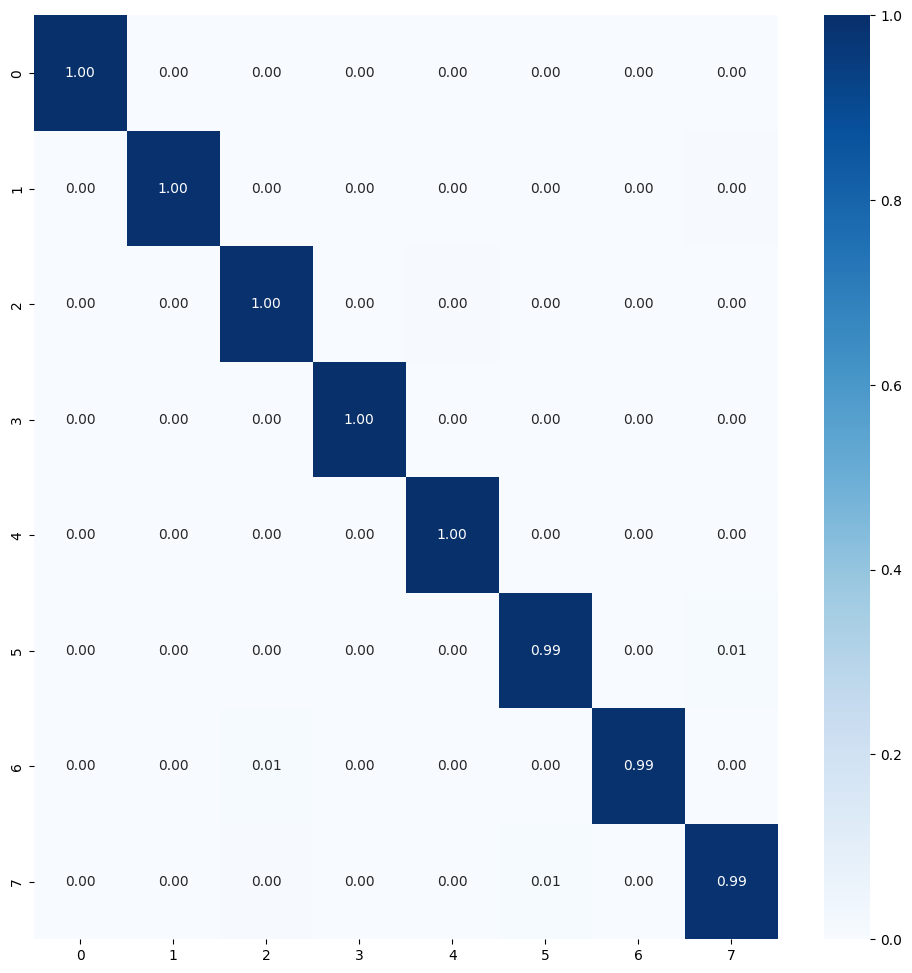

Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9959821462631225
/nTest Metrics
test_acc_list: [0.995555579662323, 0.9950000047683716, 0.9927777647972107, 0.9972222447395325, 0.9950000047683716]
Average Test Accuracy with 5-fold: 0.9951111197471618
test_loss_list: [0.7509095668792725, 0.6092591881752014, 0.04066993668675423, 0.5667057037353516, 0.2746908664703369]
Average Test Log Loss with 5-fold: 0.4484470523893833

Precision List: [0.9955871203708444, 0.9950218616639741, 0.9928188100592413, 0.9972393211139081, 0.9950171424982348]
Average Precision List with 5-fold: 0.9951368511412404
Recall List: [0.9955555555555555, 0.995, 0.9927777777777778, 0.9972222222222222, 0.995]
Average Recall List with 5-fold: 0.9951111111111111
F1 Score List: [0.9955541864360313, 0.9949999094632729, 0.9927763542590072, 0.9972221838493464, 0.9950024335186177]
Average F1 Score List with 5-fold: 0.995111013505255

Metrics List Store

test_acc_list_all = [0.9991111040115357, 

In [20]:
%%time

num_classes = 8
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/9
name_save_model: fusion_MobileNet_tf_optimized 9
Found 9450 images belonging to 9 classes.
Found 2025 images belonging to 9 classes.
Found 2025 images belonging to 9 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3822537
Trainable params: 1645321
Non-trainable params: 2177216
Epoch 1/50
295/295 [==============================] - 75s 220ms/step - loss: 1.2245 - accuracy: 0.8919 - val_loss: 0.9382 - val_accuracy: 0.9856 - lr: 1.0000e-04
Epoch 2/50
295/295 [==============================] - 49s 165ms/step - loss: 0.9398 - accuracy: 0.9780 - val_loss: 0.8808 - val_accuracy: 0.9936 - lr: 1.0000e-04
Epoch 3/50
295/295 [==============================] - 55s 184ms/step - loss: 0.8813 - accuracy: 0.9882 - val_loss: 0.8587 - val_accuracy: 0.9916 - lr: 1.0000e-04
Epoch 4/50
295/29

Model and History saved...
296/296 [==============================] - 40s 134ms/step - loss: 0.0184 - accuracy: 0.9967
Train Accuracy: 0.9967195987701416
Train Log Loss: 0.01839134469628334
64/64 [==============================] - 9s 135ms/step - loss: 0.0659 - accuracy: 0.9896
Validation Accuracy: 0.9896296262741089
Validation Log Loss: 0.0659136101603508
64/64 [==============================] - 10s 137ms/step - loss: 0.0637 - accuracy: 0.9896
Test Accuracy: 0.9896296262741089
Test Log Loss: 0.06368816643953323
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   1   0   0   0]
 [  0   0   0 222   0   3   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 225   0   0]
 [  0   0   0   2   0   0   0 223   0]
 [  0  

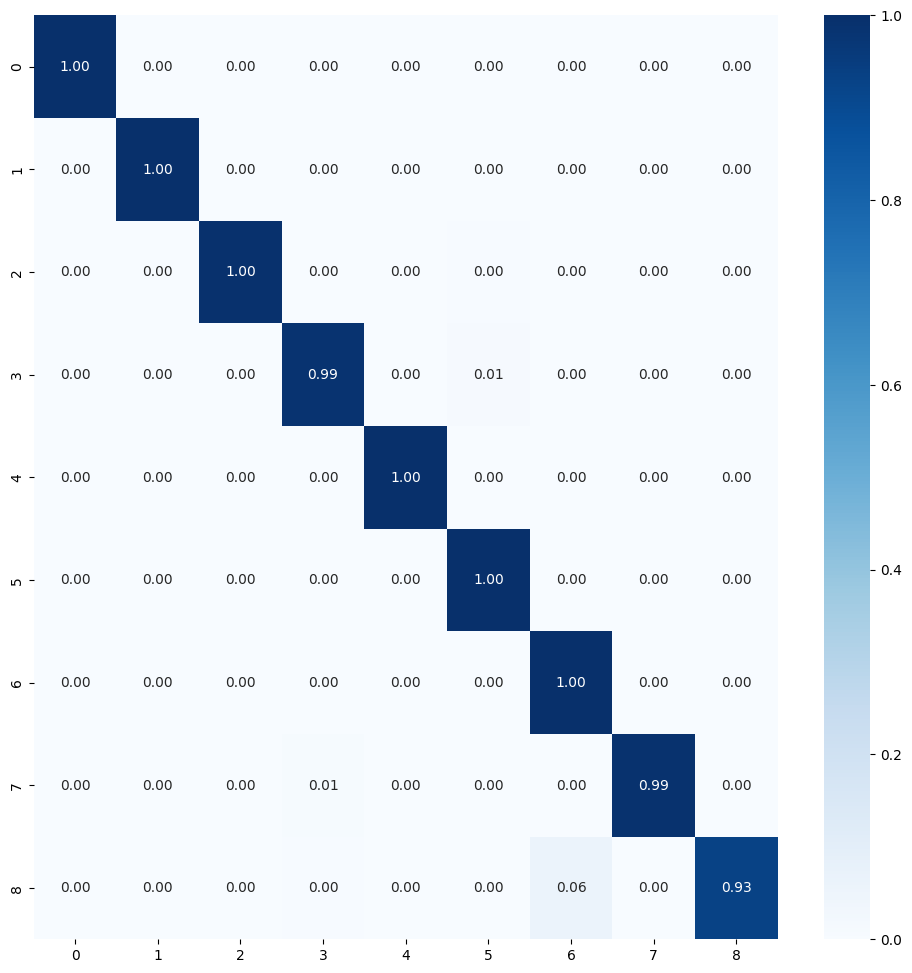


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3822537
Trainable params: 1645321
Non-trainable params: 2177216
Epoch 1/50
295/295 [==============================] - 63s 175ms/step - loss: 1.2722 - accuracy: 0.8820 - val_loss: 0.9551 - val_accuracy: 0.9767 - lr: 1.0000e-04
Epoch 2/50
295/295 [==============================] - 47s 160ms/step - loss: 0.9541 - accuracy: 0.9726 - val_loss: 0.8914 - val_accuracy: 0.9906 - lr: 1.0000e-04
Epoch 3/50
295/295 [==============================] - 52s 176ms/step - loss: 0.8854 - accuracy: 0.9875 - val_loss: 0.8598 - val_accuracy: 0.9936 - lr: 1.0000e-04
Epoch 4/50
295/295 [==============================] - 46s 156ms/step - loss: 0.8502 - accuracy: 0.9894 - val_loss: 0.8269 - val_accuracy: 0.9945 - lr: 1.0000e-04
Epoch 5/50
295/295 [==============================] - 51s 171ms/step - loss: 0.8059 - accuracy: 0.9948 - val_loss: 0.7950 - val_accuracy: 0.9950 - lr: 1.0000e-04
Epoch 6/50
295/295 [==============================] - 47s 160ms/step - los

Model and History saved...
296/296 [==============================] - 36s 122ms/step - loss: 0.0108 - accuracy: 0.9988
Train Accuracy: 0.9988359808921814
Train Log Loss: 0.010751540772616863
64/64 [==============================] - 8s 126ms/step - loss: 0.0293 - accuracy: 0.9946
Validation Accuracy: 0.9945679306983948
Validation Log Loss: 0.029285525903105736
64/64 [==============================] - 9s 136ms/step - loss: 0.0491 - accuracy: 0.9946
Test Accuracy: 0.9945679306983948
Test Log Loss: 0.049052298069000244
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 225   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 224   0   1]
 [  0   0   0   2   0   0   0 223   0]
 [  

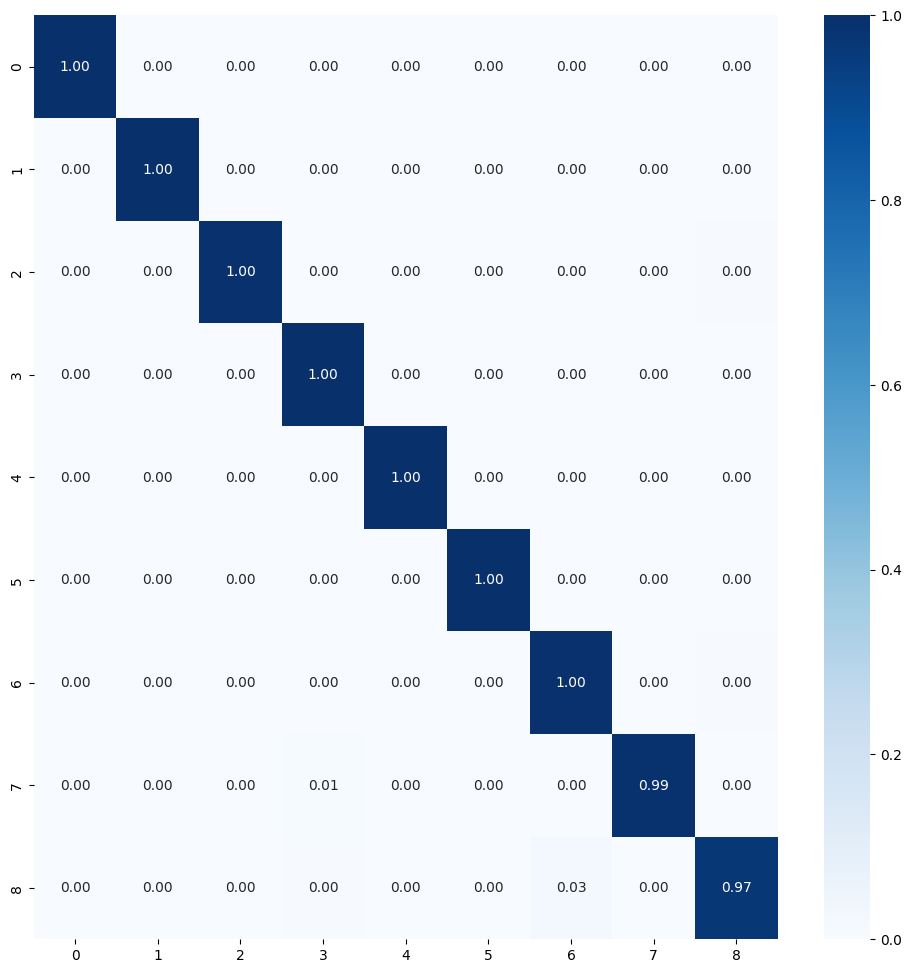


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3822537
Trainable params: 1645321
Non-trainable params: 2177216
Epoch 1/50
295/295 [==============================] - 64s 181ms/step - loss: 1.3021 - accuracy: 0.8698 - val_loss: 0.9573 - val_accuracy: 0.9762 - lr: 1.0000e-04
Epoch 2/50
295/295 [==============================] - 53s 178ms/step - loss: 0.9483 - accuracy: 0.9750 - val_loss: 0.8960 - val_accuracy: 0.9881 - lr: 1.0000e-04
Epoch 3/50
295/295 [==============================] - 51s 172ms/step - loss: 0.8926 - accuracy: 0.9861 - val_loss: 0.8594 - val_accuracy: 0.9940 - lr: 1.0000e-04
Epoch 4/50
295/295 [==============================] - 49s 166ms/step - loss: 0.8509 - accuracy: 0.9918 - val_loss: 0.8281 - val_accuracy: 0.9936 - lr: 1.0000e-04
Epoch 5/50
295/295 [==============================] - 50s 170ms/step - loss: 0.8106 - accuracy: 0.9937 - val_loss: 0.7987 - val_accuracy: 0.9916 - lr: 1.0000e-04
Epoch 6/50
295/295 [==============================] - 49s 164ms/step - los

Model and History saved...
296/296 [==============================] - 40s 132ms/step - loss: 0.0062 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.006160365883260965
64/64 [==============================] - 9s 134ms/step - loss: 0.0317 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.031676214188337326
64/64 [==============================] - 9s 127ms/step - loss: 0.0309 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.03087444044649601
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 223   1   1   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 225   0   0]
 [  0   0   0   2   0   0   0 223   0]
 [  0   0   0   1   0 

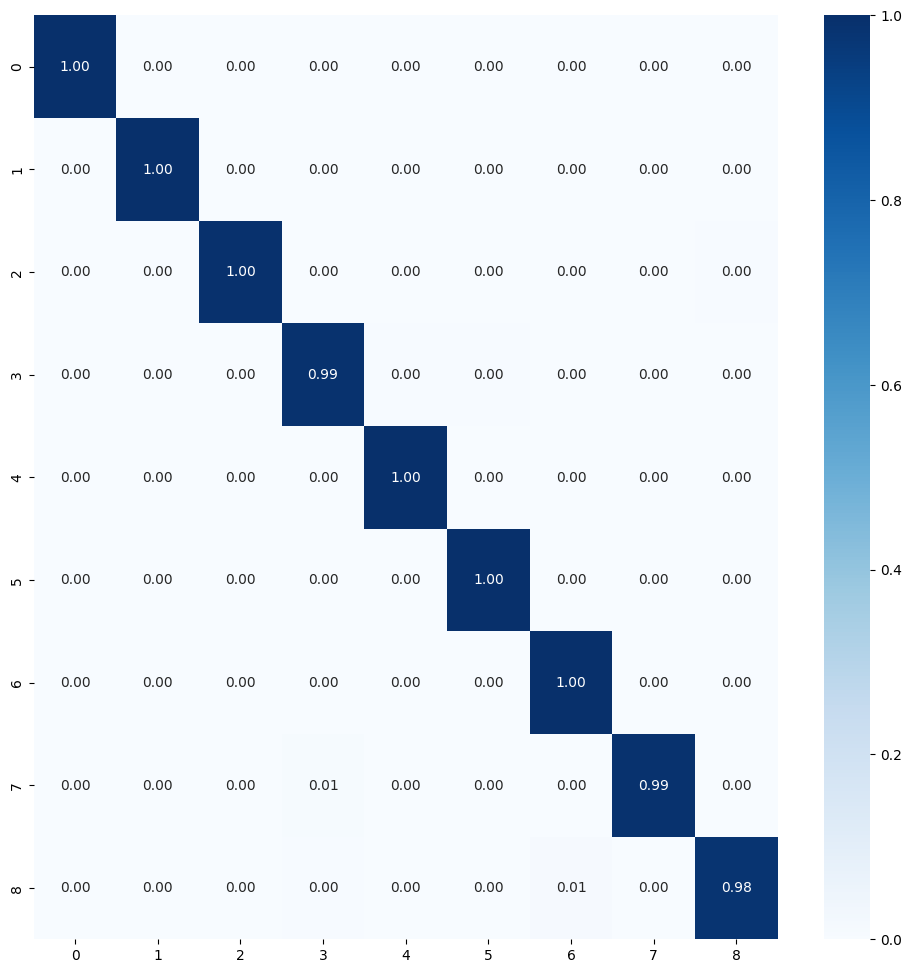


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3822537
Trainable params: 1645321
Non-trainable params: 2177216
Epoch 1/50
295/295 [==============================] - 65s 188ms/step - loss: 1.2389 - accuracy: 0.8874 - val_loss: 0.9577 - val_accuracy: 0.9767 - lr: 1.0000e-04
Epoch 2/50
295/295 [==============================] - 50s 169ms/step - loss: 0.9456 - accuracy: 0.9752 - val_loss: 0.8870 - val_accuracy: 0.9921 - lr: 1.0000e-04
Epoch 3/50
295/295 [==============================] - 50s 171ms/step - loss: 0.8854 - accuracy: 0.9869 - val_loss: 0.8577 - val_accuracy: 0.9936 - lr: 1.0000e-04
Epoch 4/50
295/295 [==============================] - 51s 169ms/step - loss: 0.8430 - accuracy: 0.9913 - val_loss: 0.8239 - val_accuracy: 0.9950 - lr: 1.0000e-04
Epoch 5/50
295/295 [==============================] - 52s 176ms/step - loss: 0.8004 - accuracy: 0.9956 - val_loss: 0.7884 - val_accuracy: 0.9945 - lr: 1.0000e-04
Epoch 6/50
295/295 [==============================] - 47s 159ms/step - los

Model and History saved...
296/296 [==============================] - 40s 134ms/step - loss: 0.4736 - accuracy: 0.9999
Train Accuracy: 0.9998942017555237
Train Log Loss: 0.4736388027667999
64/64 [==============================] - 9s 140ms/step - loss: 0.4976 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.4975694715976715
64/64 [==============================] - 9s 137ms/step - loss: 0.5003 - accuracy: 0.9960
Test Accuracy: 0.9960494041442871
Test Log Loss: 0.5003127455711365
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 224   0   0   0   1   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 224   0   1]
 [  0   0   0   2   0   0   0 223   0]
 [  0   0  

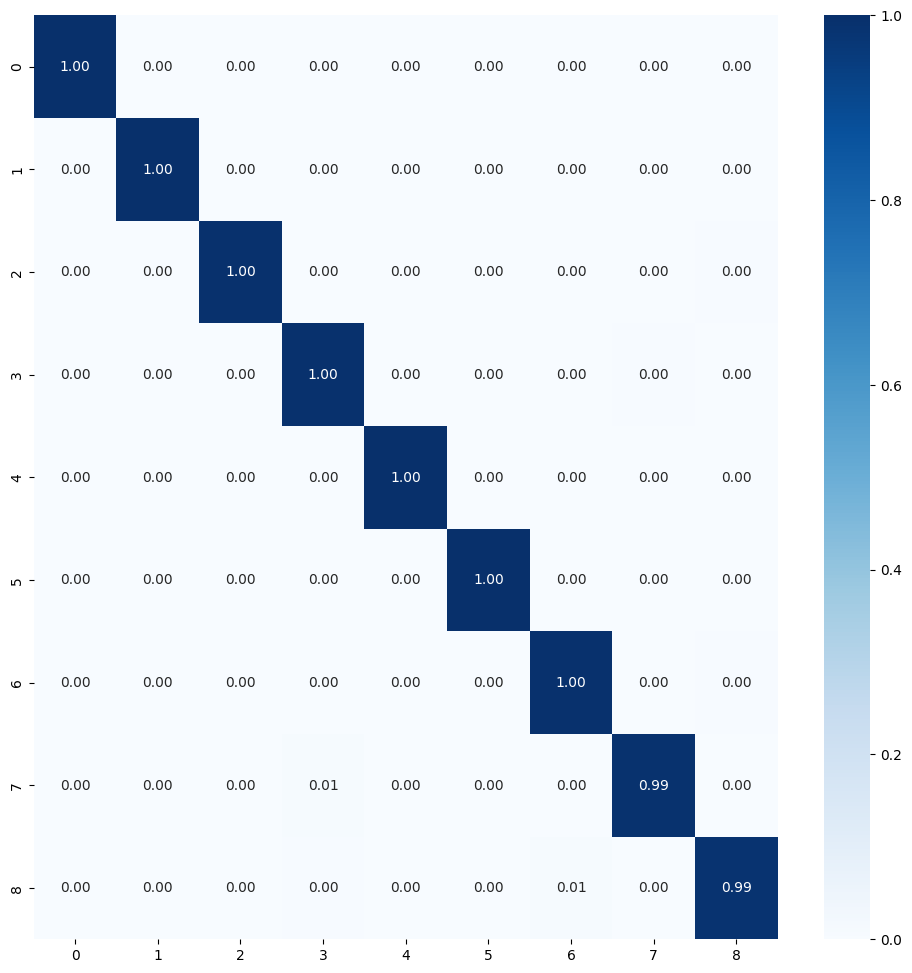


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3822537
Trainable params: 1645321
Non-trainable params: 2177216
Epoch 1/50
295/295 [==============================] - 60s 169ms/step - loss: 1.2749 - accuracy: 0.8817 - val_loss: 0.9478 - val_accuracy: 0.9836 - lr: 1.0000e-04
Epoch 2/50
295/295 [==============================] - 49s 165ms/step - loss: 0.9393 - accuracy: 0.9775 - val_loss: 0.9105 - val_accuracy: 0.9841 - lr: 1.0000e-04
Epoch 3/50
295/295 [==============================] - 49s 167ms/step - loss: 0.8836 - accuracy: 0.9878 - val_loss: 0.8628 - val_accuracy: 0.9931 - lr: 1.0000e-04
Epoch 4/50
295/295 [==============================] - 49s 167ms/step - loss: 0.8482 - accuracy: 0.9915 - val_loss: 0.8381 - val_accuracy: 0.9911 - lr: 1.0000e-04
Epoch 5/50
295/295 [==============================] - 49s 166ms/step - loss: 0.8082 - accuracy: 0.9941 - val_loss: 0.7971 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 6/50
295/295 [==============================] - 49s 166ms/step - los

Model and History saved...
296/296 [==============================] - 39s 126ms/step - loss: 0.0101 - accuracy: 0.9998
Train Accuracy: 0.9997883439064026
Train Log Loss: 0.010140897706151009
64/64 [==============================] - 9s 126ms/step - loss: 0.0374 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.03743629902601242
64/64 [==============================] - 9s 124ms/step - loss: 0.0373 - accuracy: 0.9951
Test Accuracy: 0.9950617551803589
Test Log Loss: 0.03733054921030998
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 221   1   3   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 224   0   1]
 [  0   0   0   2   0   0   0 223   0]
 [  0  

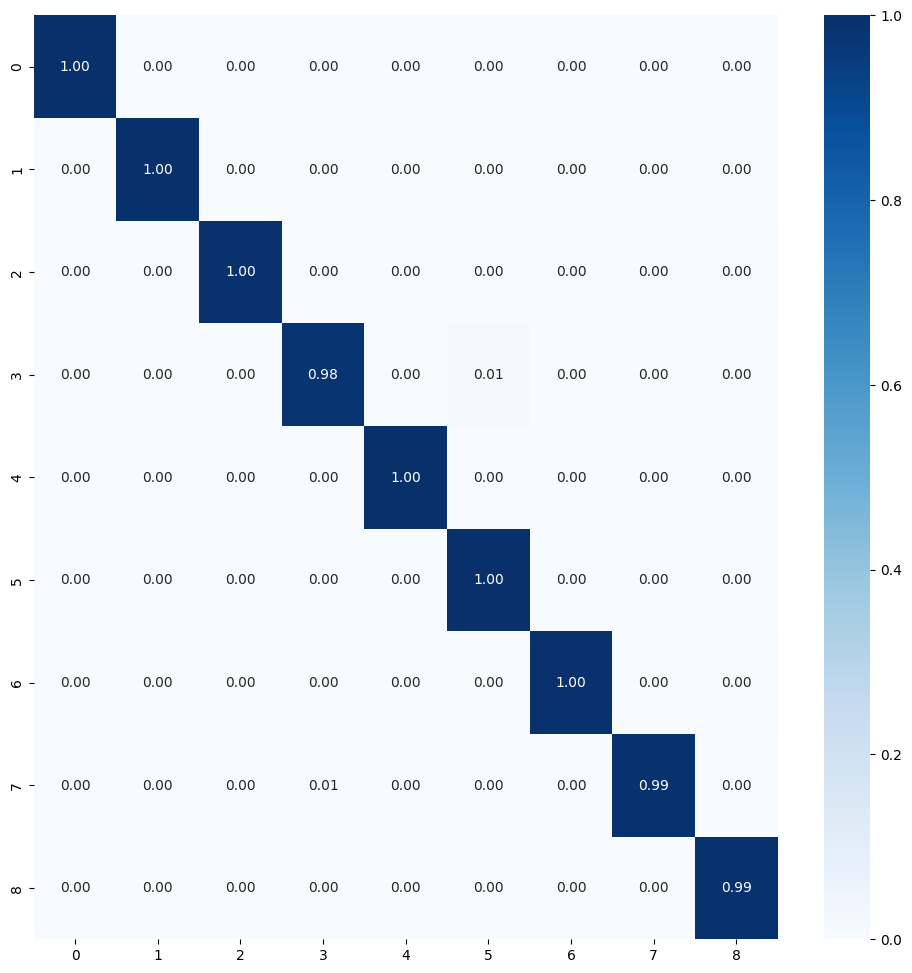

Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.996230173110962
/nTest Metrics
test_acc_list: [0.9896296262741089, 0.9945679306983948, 0.995555579662323, 0.9960494041442871, 0.9950617551803589]
Average Test Accuracy with 5-fold: 0.9941728591918946
test_loss_list: [0.06368816643953323, 0.049052298069000244, 0.03087444044649601, 0.5003127455711365, 0.03733054921030998]
Average Test Log Loss with 5-fold: 0.1362516399472952

Precision List: [0.9900691124334033, 0.9946293599611677, 0.9955793007725937, 0.9960601918115758, 0.9950767928917672]
Average Precision List with 5-fold: 0.9942829515741016
Recall List: [0.9896296296296296, 0.9945679012345681, 0.9955555555555556, 0.9960493827160494, 0.9950617283950618]
Average Recall List with 5-fold: 0.9941728395061729
F1 Score List: [0.989612162706573, 0.9945640768612756, 0.9955532532898937, 0.9960504460385962, 0.9950605775064698]
Average F1 Score List with 5-fold: 0.9941681032805617

Metrics List Store

test_acc_lis

In [21]:
%%time

num_classes = 9
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/10
name_save_model: fusion_MobileNet_tf_optimized 10
Found 10500 images belonging to 10 classes.
Found 2250 images belonging to 10 classes.
Found 2250 images belonging to 10 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3822666
Trainable params: 1645450
Non-trainable params: 2177216
Epoch 1/50
328/328 [==============================] - 71s 173ms/step - loss: 1.4624 - accuracy: 0.8119 - val_loss: 1.0690 - val_accuracy: 0.9371 - lr: 1.0000e-04
Epoch 2/50
328/328 [==============================] - 53s 161ms/step - loss: 1.0987 - accuracy: 0.9204 - val_loss: 1.0061 - val_accuracy: 0.9438 - lr: 1.0000e-04
Epoch 3/50
328/328 [==============================] - 53s 161ms/step - loss: 1.0142 - accuracy: 0.9435 - val_loss: 0.9524 - val_accuracy: 0.9629 - lr: 1.0000e-04
E

Model and History saved...
329/329 [==============================] - 44s 134ms/step - loss: 0.0420 - accuracy: 0.9994
Train Accuracy: 0.9994285702705383
Train Log Loss: 0.0419699028134346
71/71 [==============================] - 10s 138ms/step - loss: 0.1883 - accuracy: 0.9733
Validation Accuracy: 0.9733333587646484
Validation Log Loss: 0.18826845288276672
71/71 [==============================] - 10s 139ms/step - loss: 0.1867 - accuracy: 0.9711
Test Accuracy: 0.9711111187934875
Test Log Loss: 0.18673181533813477
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[224   0   0   0   0   0   0   0   0   1]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1]
 [  0   0   0 223   1   0   0   0   0   1]
 [  0   0   0   0 218   0   0   0   0   7]
 [  0   0   0   0   0 224   0   0   0   1]
 [  0   0   0   0   0   0 219   0   1   5]
 [ 

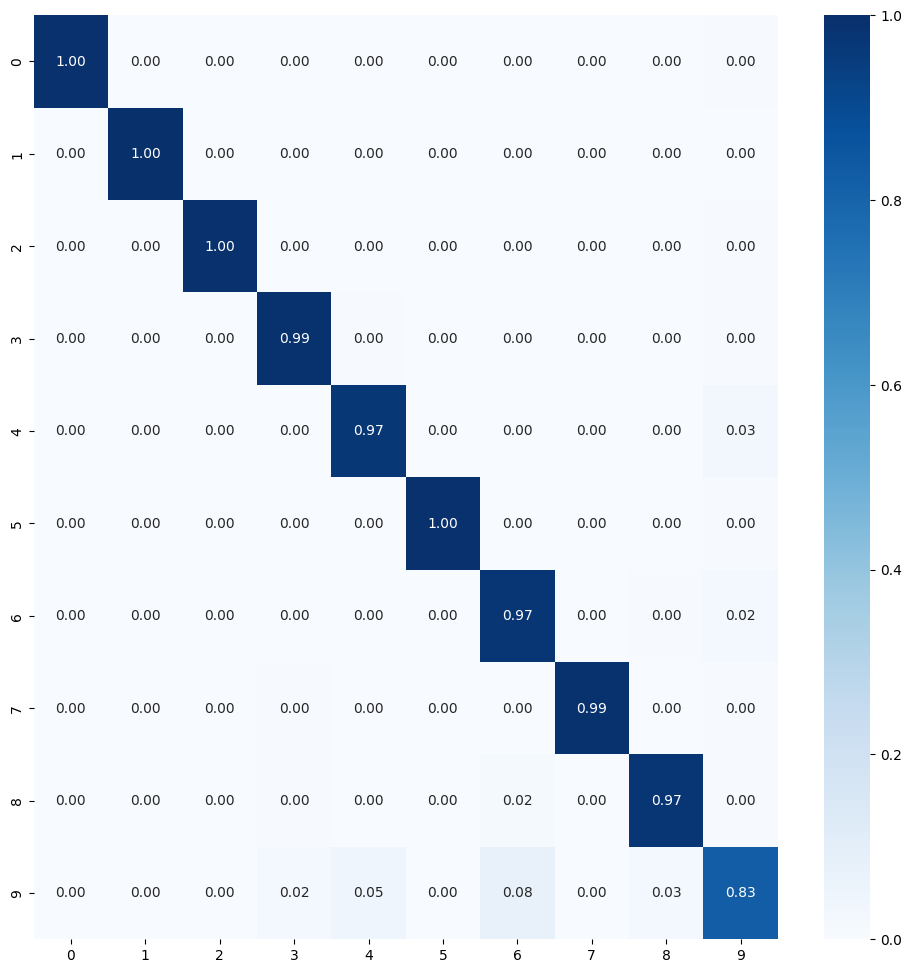


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3822666
Trainable params: 1645450
Non-trainable params: 2177216
Epoch 1/50
328/328 [==============================] - 69s 176ms/step - loss: 1.4928 - accuracy: 0.8142 - val_loss: 1.0694 - val_accuracy: 0.9429 - lr: 1.0000e-04
Epoch 2/50
328/328 [==============================] - 58s 174ms/step - loss: 1.1043 - accuracy: 0.9208 - val_loss: 0.9966 - val_accuracy: 0.9478 - lr: 1.0000e-04
Epoch 3/50
328/328 [==============================] - 56s 169ms/step - loss: 1.0254 - accuracy: 0.9425 - val_loss: 0.9581 - val_accuracy: 0.9580 - lr: 1.0000e-04
Epoch 4/50
328/328 [==============================] - 55s 166ms/step - loss: 0.9618 - accuracy: 0.9536 - val_loss: 0.9377 - val_accuracy: 0.9594 - lr: 1.0000e-04
Epoch 5/50
328/328 [==============================] - 56s 171ms/step - loss: 0.9207 - accuracy: 0.9576 - val_loss: 0.9016 - val_accuracy: 0.9643 - lr: 1.0000e-04
Epoch 6/50
328/328 [==============================] - 52s 157ms/step - los

Model and History saved...
329/329 [==============================] - 42s 126ms/step - loss: 0.0434 - accuracy: 0.9999
Train Accuracy: 0.9999047517776489
Train Log Loss: 0.04337802156805992
71/71 [==============================] - 11s 134ms/step - loss: 0.2009 - accuracy: 0.9684
Validation Accuracy: 0.9684444665908813
Validation Log Loss: 0.2008918970823288
71/71 [==============================] - 10s 123ms/step - loss: 0.1814 - accuracy: 0.9720
Test Accuracy: 0.972000002861023
Test Log Loss: 0.18141068518161774
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 224   0   0   0   0   0   1]
 [  0   0   0   0 219   0   0   0   0   6]
 [  0   0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0   0 212   0   2  11]
 [  

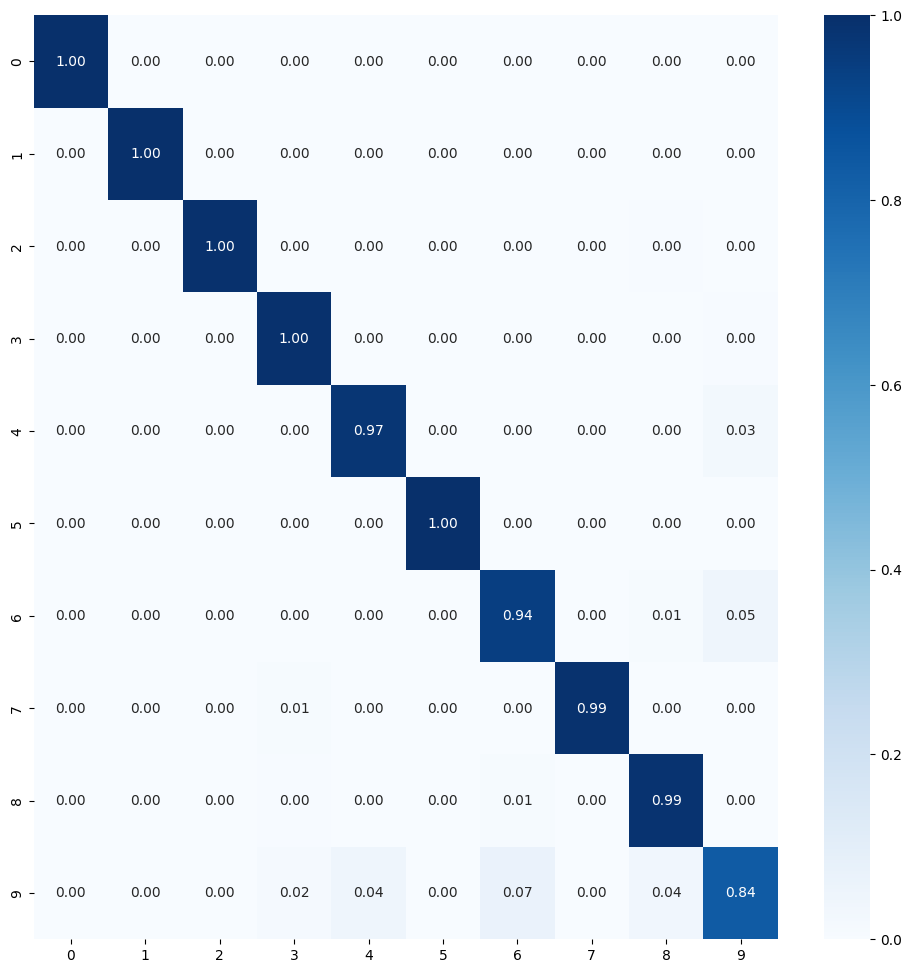


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3822666
Trainable params: 1645450
Non-trainable params: 2177216
Epoch 1/50
328/328 [==============================] - 67s 169ms/step - loss: 1.5063 - accuracy: 0.8027 - val_loss: 1.0730 - val_accuracy: 0.9308 - lr: 1.0000e-04
Epoch 2/50
328/328 [==============================] - 54s 164ms/step - loss: 1.1023 - accuracy: 0.9226 - val_loss: 1.0006 - val_accuracy: 0.9487 - lr: 1.0000e-04
Epoch 3/50
328/328 [==============================] - 51s 154ms/step - loss: 1.0098 - accuracy: 0.9452 - val_loss: 0.9925 - val_accuracy: 0.9379 - lr: 1.0000e-04
Epoch 4/50
328/328 [==============================] - 52s 158ms/step - loss: 0.9655 - accuracy: 0.9529 - val_loss: 0.9272 - val_accuracy: 0.9638 - lr: 1.0000e-04
Epoch 5/50
328/328 [==============================] - 53s 161ms/step - loss: 0.9137 - accuracy: 0.9645 - val_loss: 0.8966 - val_accuracy: 0.9665 - lr: 1.0000e-04
Epoch 6/50
328/328 [==============================] - 52s 157ms/step - los

Model and History saved...
329/329 [==============================] - 38s 115ms/step - loss: 0.0468 - accuracy: 0.9995
Train Accuracy: 0.9995238184928894
Train Log Loss: 0.04681017994880676
71/71 [==============================] - 9s 114ms/step - loss: 0.1939 - accuracy: 0.9684
Validation Accuracy: 0.9684444665908813
Validation Log Loss: 0.19388704001903534
71/71 [==============================] - 9s 119ms/step - loss: 0.1715 - accuracy: 0.9707
Test Accuracy: 0.9706666469573975
Test Log Loss: 0.1714710295200348
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 223   0   0   0   0   0   2]
 [  0   0   0   0 217   0   0   0   0   8]
 [  0   0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0   0 207   0   2  16]
 [  0

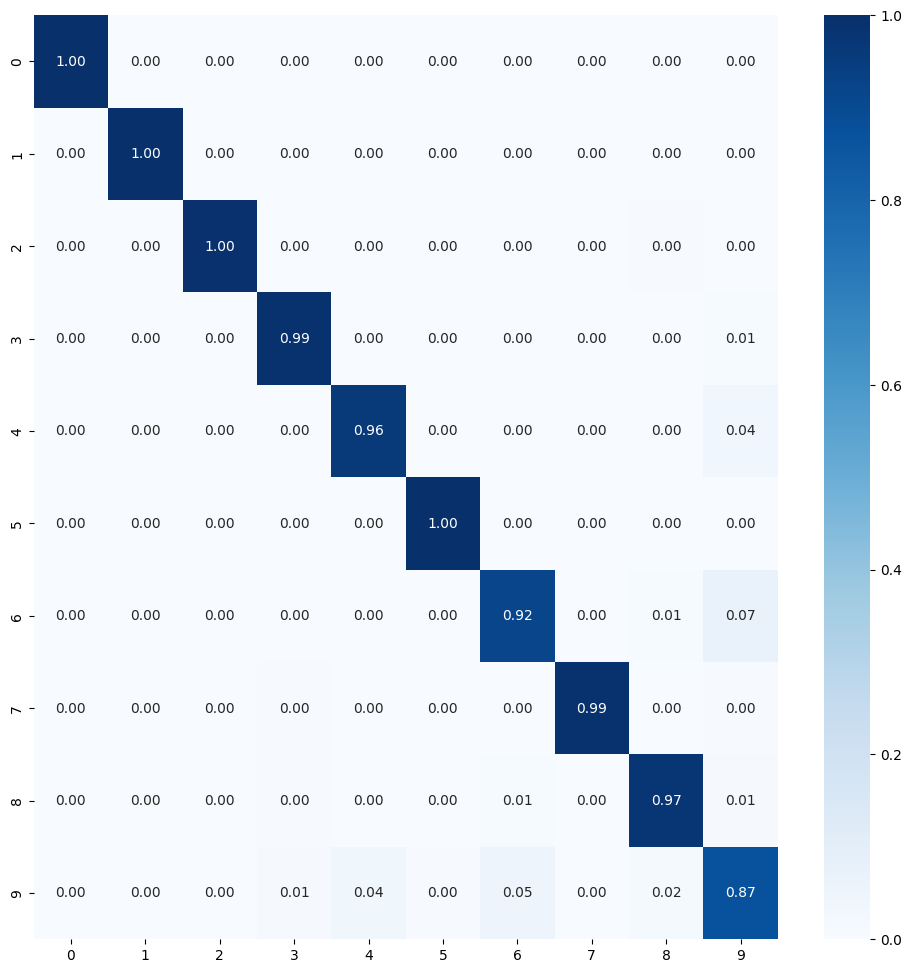


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3822666
Trainable params: 1645450
Non-trainable params: 2177216
Epoch 1/50
328/328 [==============================] - 58s 150ms/step - loss: 1.4850 - accuracy: 0.8071 - val_loss: 1.0667 - val_accuracy: 0.9442 - lr: 1.0000e-04
Epoch 2/50
328/328 [==============================] - 48s 145ms/step - loss: 1.0973 - accuracy: 0.9228 - val_loss: 1.0078 - val_accuracy: 0.9522 - lr: 1.0000e-04
Epoch 3/50
328/328 [==============================] - 45s 136ms/step - loss: 1.0230 - accuracy: 0.9412 - val_loss: 0.9674 - val_accuracy: 0.9576 - lr: 1.0000e-04
Epoch 4/50
328/328 [==============================] - 44s 135ms/step - loss: 0.9702 - accuracy: 0.9503 - val_loss: 0.9584 - val_accuracy: 0.9527 - lr: 1.0000e-04
Epoch 5/50
328/328 [==============================] - 46s 139ms/step - loss: 0.9150 - accuracy: 0.9615 - val_loss: 0.9278 - val_accuracy: 0.9621 - lr: 1.0000e-04
Epoch 6/50
328/328 [==============================] - 45s 138ms/step - los

Model and History saved...
329/329 [==============================] - 40s 119ms/step - loss: 0.0563 - accuracy: 0.9942
Train Accuracy: 0.9941904544830322
Train Log Loss: 0.056343600153923035
71/71 [==============================] - 8s 117ms/step - loss: 0.2400 - accuracy: 0.9707
Validation Accuracy: 0.9706666469573975
Validation Log Loss: 0.24002902209758759
71/71 [==============================] - 9s 119ms/step - loss: 0.2417 - accuracy: 0.9698
Test Accuracy: 0.9697777628898621
Test Log Loss: 0.24169932305812836
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 222   1   0   0   0   0   2]
 [  0   0   0   0 219   0   0   0   0   6]
 [  0   0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0   0 224   0   1   0]
 [ 

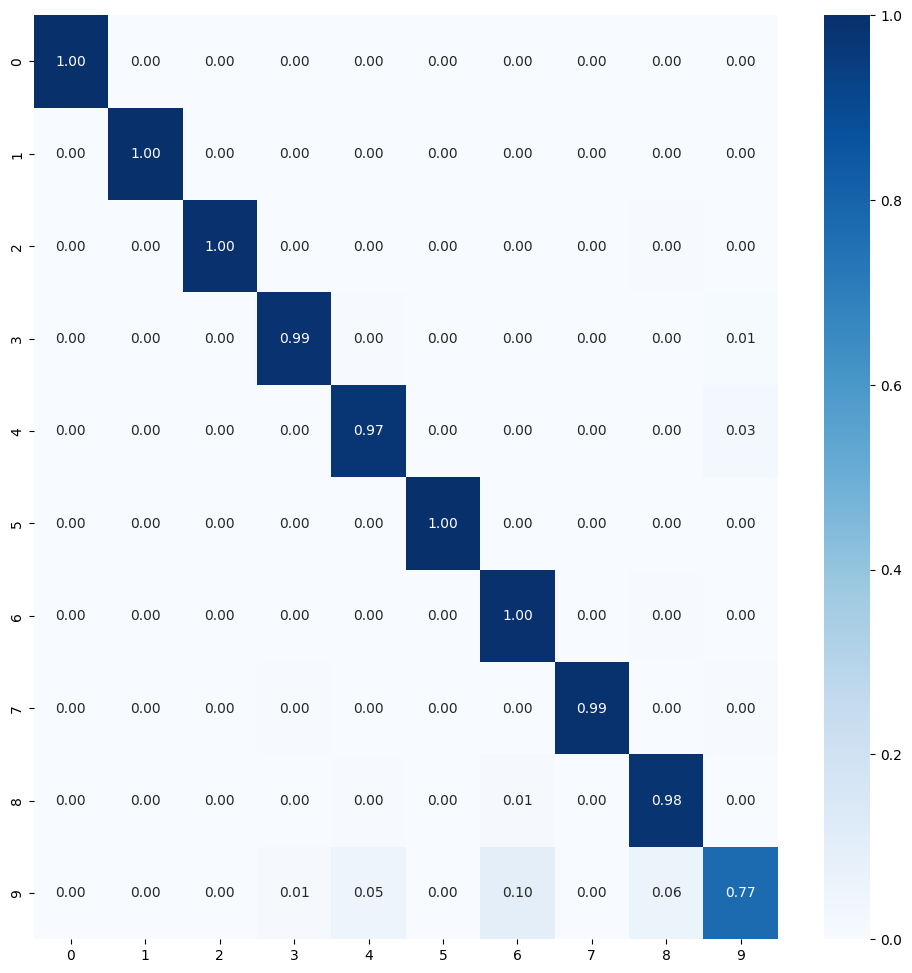


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3822666
Trainable params: 1645450
Non-trainable params: 2177216
Epoch 1/50
328/328 [==============================] - 57s 147ms/step - loss: 1.5059 - accuracy: 0.8043 - val_loss: 1.0743 - val_accuracy: 0.9259 - lr: 1.0000e-04
Epoch 2/50
328/328 [==============================] - 49s 148ms/step - loss: 1.0986 - accuracy: 0.9201 - val_loss: 0.9952 - val_accuracy: 0.9536 - lr: 1.0000e-04
Epoch 3/50
328/328 [==============================] - 49s 148ms/step - loss: 1.0130 - accuracy: 0.9414 - val_loss: 0.9601 - val_accuracy: 0.9621 - lr: 1.0000e-04
Epoch 4/50
328/328 [==============================] - 48s 145ms/step - loss: 0.9615 - accuracy: 0.9529 - val_loss: 0.9259 - val_accuracy: 0.9625 - lr: 1.0000e-04
Epoch 5/50
328/328 [==============================] - 49s 149ms/step - loss: 0.9145 - accuracy: 0.9606 - val_loss: 0.8915 - val_accuracy: 0.9629 - lr: 1.0000e-04
Epoch 6/50
328/328 [==============================] - 49s 149ms/step - los

Model and History saved...
329/329 [==============================] - 37s 111ms/step - loss: 0.6463 - accuracy: 0.9929
Train Accuracy: 0.9928571581840515
Train Log Loss: 0.6463221907615662
71/71 [==============================] - 9s 113ms/step - loss: 0.7207 - accuracy: 0.9716
Validation Accuracy: 0.9715555310249329
Validation Log Loss: 0.7207219004631042
71/71 [==============================] - 8s 113ms/step - loss: 0.7174 - accuracy: 0.9693
Test Accuracy: 0.9693333506584167
Test Log Loss: 0.7173749804496765
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 221   1   0   0   0   0   3]
 [  0   0   0   0 218   0   0   0   0   7]
 [  0   0   0   0   0 223   0   0   0   2]
 [  0   0   0   0   0   0 213   0   1  11]
 [  0  

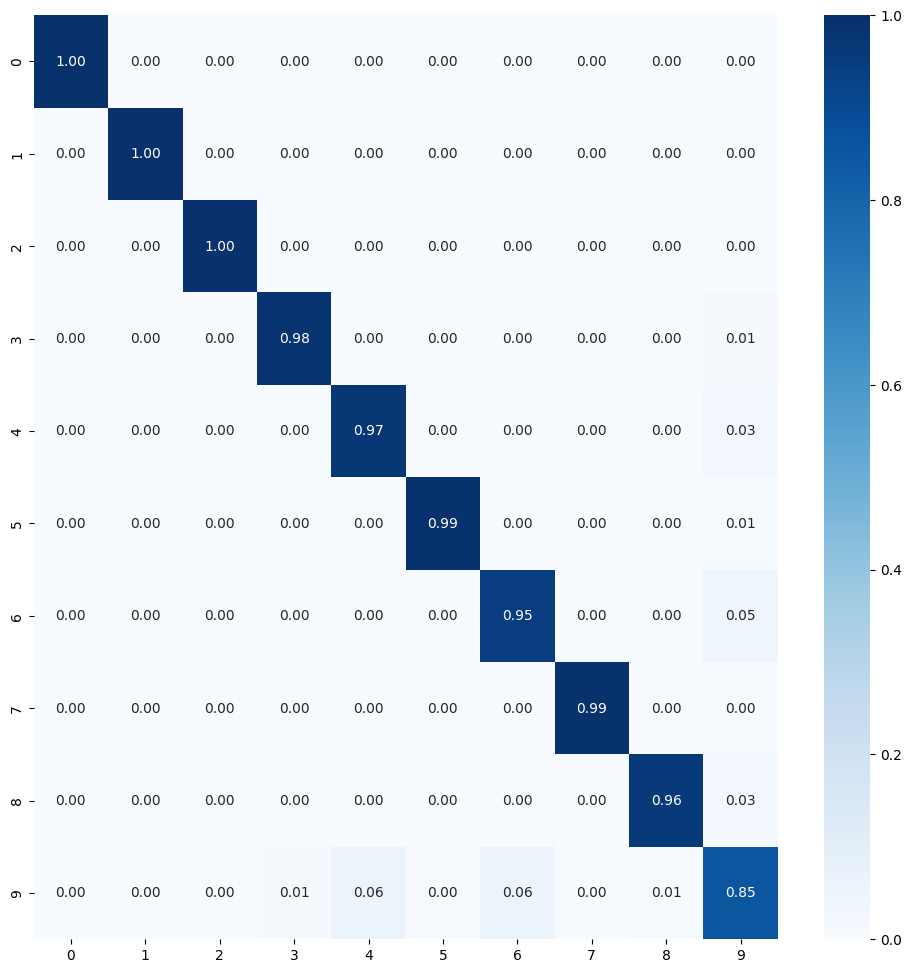

Average training accuracy in 5-fold: 0.9978983640670777
Average validation precision in 5-fold: 0.9725892782211304
/nTest Metrics
test_acc_list: [0.9711111187934875, 0.972000002861023, 0.9706666469573975, 0.9697777628898621, 0.9693333506584167]
Average Test Accuracy with 5-fold: 0.9705777764320374
test_loss_list: [0.18673181533813477, 0.18141068518161774, 0.1714710295200348, 0.24169932305812836, 0.7173749804496765]
Average Test Log Loss with 5-fold: 0.29973756670951845

Precision List: [0.9710682558902745, 0.9717204098360082, 0.9706757157379092, 0.9705122565228119, 0.969404283656354]
Average Precision List with 5-fold: 0.9706761843286718
Recall List: [0.971111111111111, 0.9719999999999999, 0.9706666666666666, 0.9697777777777778, 0.9693333333333334]
Average Recall List with 5-fold: 0.9705777777777778
F1 Score List: [0.9707559255571591, 0.9716265202835078, 0.9706550584218441, 0.9688918168726655, 0.9693271438340192]
Average F1 Score List with 5-fold: 0.9702512929938392

Metrics List Store

In [22]:
%%time

num_classes = 10
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/11
name_save_model: fusion_MobileNet_tf_optimized 11
Found 11550 images belonging to 11 classes.
Found 2475 images belonging to 11 classes.
Found 2475 images belonging to 11 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3822795
Trainable params: 1645579
Non-trainable params: 2177216
Epoch 1/50
360/360 [==============================] - 57s 136ms/step - loss: 1.6659 - accuracy: 0.7554 - val_loss: 1.1650 - val_accuracy: 0.8957 - lr: 1.0000e-04
Epoch 2/50
360/360 [==============================] - 53s 148ms/step - loss: 1.2097 - accuracy: 0.8799 - val_loss: 1.0761 - val_accuracy: 0.9172 - lr: 1.0000e-04
Epoch 3/50
360/360 [==============================] - 52s 143ms/step - loss: 1.1073 - accuracy: 0.9084 - val_loss: 1.0366 - val_accuracy: 0.9200 - lr: 1.0

Model and History saved...
361/361 [==============================] - 45s 124ms/step - loss: 0.0630 - accuracy: 0.9952
Train Accuracy: 0.9952380657196045
Train Log Loss: 0.0630459189414978
78/78 [==============================] - 11s 125ms/step - loss: 0.3086 - accuracy: 0.9430
Validation Accuracy: 0.9430302977561951
Validation Log Loss: 0.30863866209983826
78/78 [==============================] - 13s 162ms/step - loss: 0.2958 - accuracy: 0.9471
Test Accuracy: 0.9470707178115845
Test Log Loss: 0.29584020376205444
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 223   0   0   0   0   0   0   2]
 [  0   0   0   0 190  10   0   0   0   0  25]
 [  0   0   0   0  11 206   0   0   0   0   8]
 [  0   

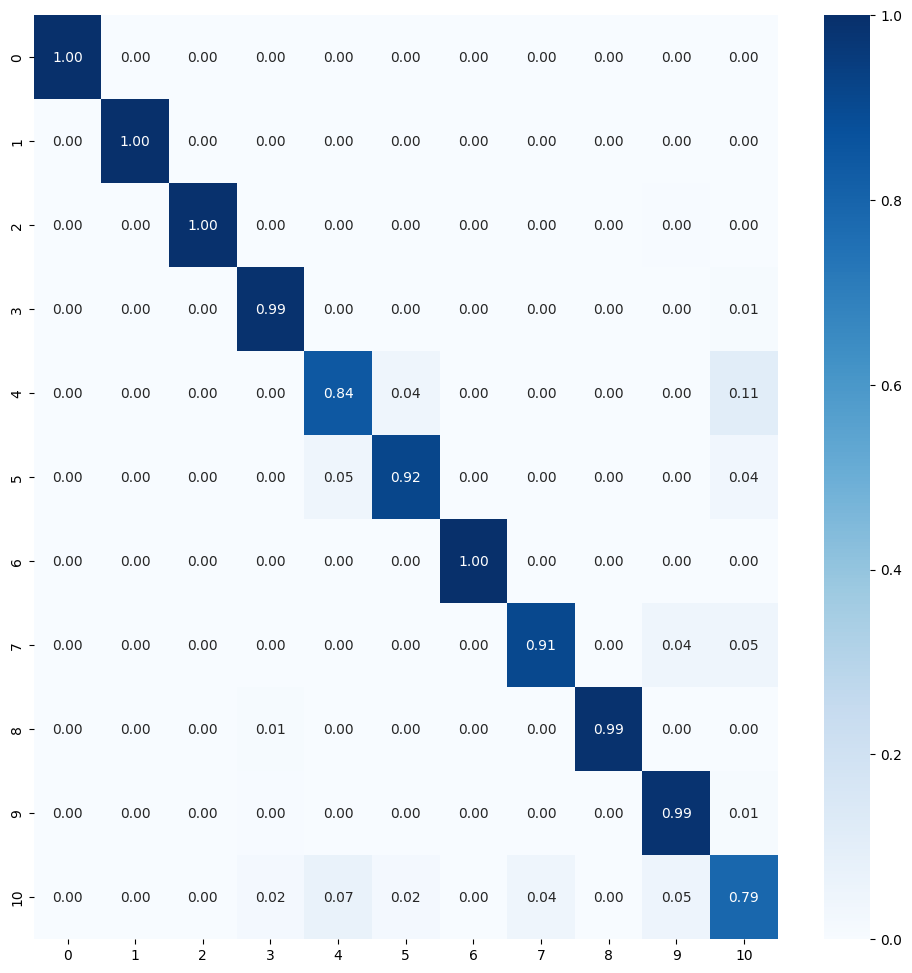


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3822795
Trainable params: 1645579
Non-trainable params: 2177216
Epoch 1/50
360/360 [==============================] - 67s 158ms/step - loss: 1.6167 - accuracy: 0.7668 - val_loss: 1.1755 - val_accuracy: 0.8965 - lr: 1.0000e-04
Epoch 2/50
360/360 [==============================] - 57s 158ms/step - loss: 1.2108 - accuracy: 0.8733 - val_loss: 1.0850 - val_accuracy: 0.9168 - lr: 1.0000e-04
Epoch 3/50
360/360 [==============================] - 56s 154ms/step - loss: 1.1096 - accuracy: 0.9039 - val_loss: 1.0426 - val_accuracy: 0.9229 - lr: 1.0000e-04
Epoch 4/50
360/360 [==============================] - 55s 150ms/step - loss: 1.0432 - accuracy: 0.9196 - val_loss: 1.0025 - val_accuracy: 0.9261 - lr: 1.0000e-04
Epoch 5/50
360/360 [==============================] - 54s 151ms/step - loss: 0.9809 - accuracy: 0.9346 - val_loss: 0.9676 - val_accuracy: 0.9298 - lr: 1.0000e-04
Epoch 6/50
360/360 [==============================] - 58s 160ms/step - los

Model and History saved...
361/361 [==============================] - 52s 143ms/step - loss: 0.0756 - accuracy: 0.9892
Train Accuracy: 0.9891774654388428
Train Log Loss: 0.0755552425980568
78/78 [==============================] - 11s 139ms/step - loss: 0.3769 - accuracy: 0.9430
Validation Accuracy: 0.9430302977561951
Validation Log Loss: 0.3768710196018219
78/78 [==============================] - 11s 141ms/step - loss: 0.3784 - accuracy: 0.9499
Test Accuracy: 0.9498990178108215
Test Log Loss: 0.37843766808509827
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 222   1   0   0   1   0   0   1]
 [  0   0   0   0 204   9   0   1   0   0  11]
 [  0   0   0   0  11 210   0   0   0   0   4]
 [  0   0

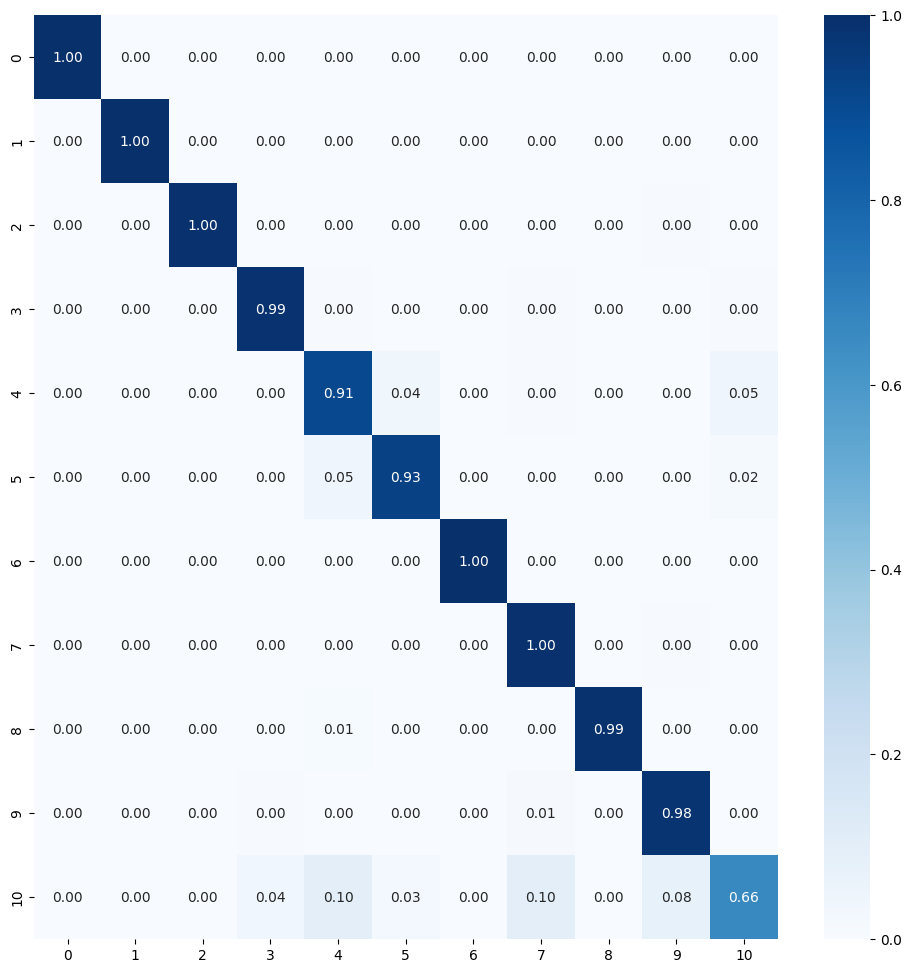


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3822795
Trainable params: 1645579
Non-trainable params: 2177216
Epoch 1/50
360/360 [==============================] - 86s 206ms/step - loss: 1.6219 - accuracy: 0.7592 - val_loss: 1.1930 - val_accuracy: 0.8754 - lr: 1.0000e-04
Epoch 2/50
360/360 [==============================] - 70s 194ms/step - loss: 1.2039 - accuracy: 0.8745 - val_loss: 1.0780 - val_accuracy: 0.9180 - lr: 1.0000e-04
Epoch 3/50
360/360 [==============================] - 61s 169ms/step - loss: 1.1085 - accuracy: 0.9023 - val_loss: 1.0441 - val_accuracy: 0.9278 - lr: 1.0000e-04
Epoch 4/50
360/360 [==============================] - 61s 170ms/step - loss: 1.0391 - accuracy: 0.9182 - val_loss: 1.0004 - val_accuracy: 0.9282 - lr: 1.0000e-04
Epoch 5/50
360/360 [==============================] - 74s 205ms/step - loss: 0.9964 - accuracy: 0.9292 - val_loss: 0.9668 - val_accuracy: 0.9338 - lr: 1.0000e-04
Epoch 6/50
360/360 [==============================] - 62s 172ms/step - los

Model and History saved...
361/361 [==============================] - 45s 124ms/step - loss: 0.0882 - accuracy: 0.9852
Train Accuracy: 0.9851948022842407
Train Log Loss: 0.08817236125469208
78/78 [==============================] - 10s 122ms/step - loss: 0.3657 - accuracy: 0.9301
Validation Accuracy: 0.9301010370254517
Validation Log Loss: 0.36572960019111633
78/78 [==============================] - 11s 136ms/step - loss: 0.3293 - accuracy: 0.9398
Test Accuracy: 0.9397979974746704
Test Log Loss: 0.3292778730392456
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 221   1   0   1   0   0   0   2]
 [  0   0   0   0 197   6   0   0   0   0  22]
 [  0   0   0   0  12 209   0   0   0   0   4]
 [  0   

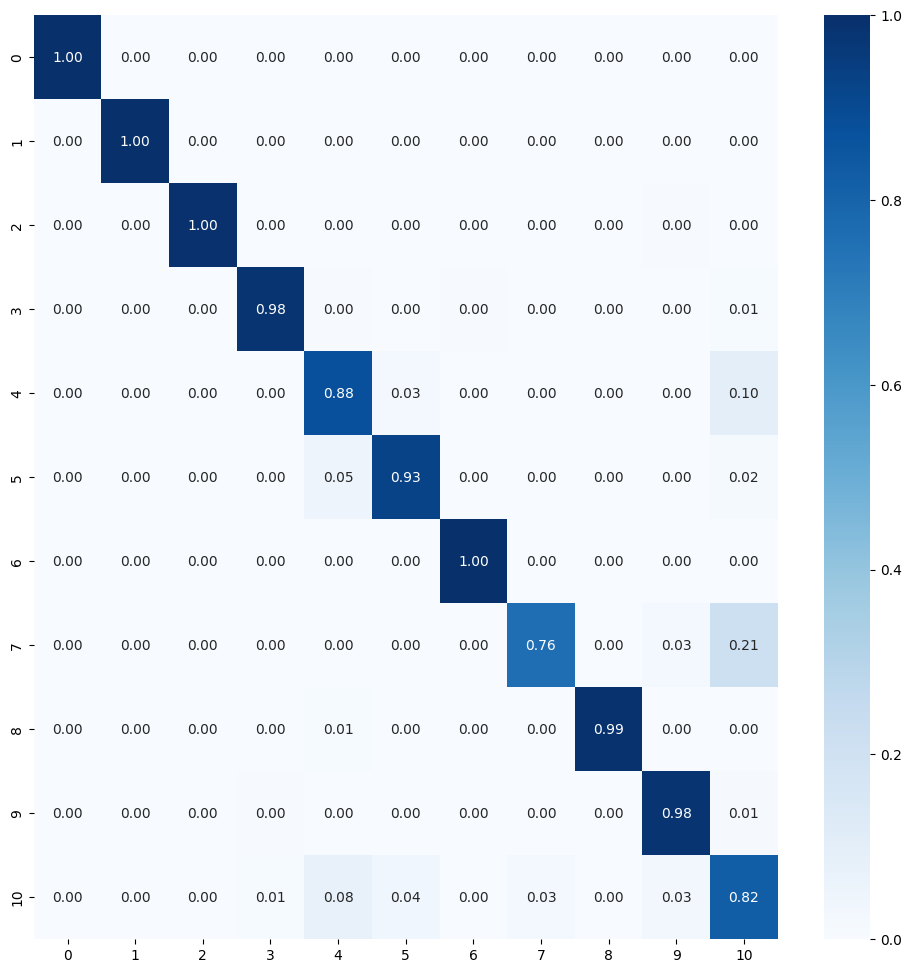


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3822795
Trainable params: 1645579
Non-trainable params: 2177216
Epoch 1/50
360/360 [==============================] - 64s 152ms/step - loss: 1.6258 - accuracy: 0.7645 - val_loss: 1.1776 - val_accuracy: 0.8920 - lr: 1.0000e-04
Epoch 2/50
360/360 [==============================] - 43s 119ms/step - loss: 1.2123 - accuracy: 0.8763 - val_loss: 1.1016 - val_accuracy: 0.9127 - lr: 1.0000e-04
Epoch 3/50
360/360 [==============================] - 28s 79ms/step - loss: 1.1046 - accuracy: 0.9060 - val_loss: 1.0509 - val_accuracy: 0.9184 - lr: 1.0000e-04
Epoch 4/50
360/360 [==============================] - 55s 152ms/step - loss: 1.0421 - accuracy: 0.9208 - val_loss: 1.0061 - val_accuracy: 0.9306 - lr: 1.0000e-04
Epoch 5/50
360/360 [==============================] - 53s 148ms/step - loss: 0.9928 - accuracy: 0.9299 - val_loss: 0.9834 - val_accuracy: 0.9338 - lr: 1.0000e-04
Epoch 6/50
360/360 [==============================] - 54s 150ms/step - loss

Model and History saved...
361/361 [==============================] - 41s 112ms/step - loss: 0.0629 - accuracy: 0.9949
Train Accuracy: 0.9948917627334595
Train Log Loss: 0.06293945759534836
78/78 [==============================] - 7s 93ms/step - loss: 0.3207 - accuracy: 0.9446
Validation Accuracy: 0.9446464776992798
Validation Log Loss: 0.32070207595825195
78/78 [==============================] - 13s 161ms/step - loss: 0.2881 - accuracy: 0.9507
Test Accuracy: 0.9507070779800415
Test Log Loss: 0.2881024181842804
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1]
 [  0   0   0 221   0   0   1   0   0   0   3]
 [  0   0   0   0 196  12   0   0   0   0  17]
 [  0   0   0   0  11 208   0   0   0   0   6]
 [  0   0 

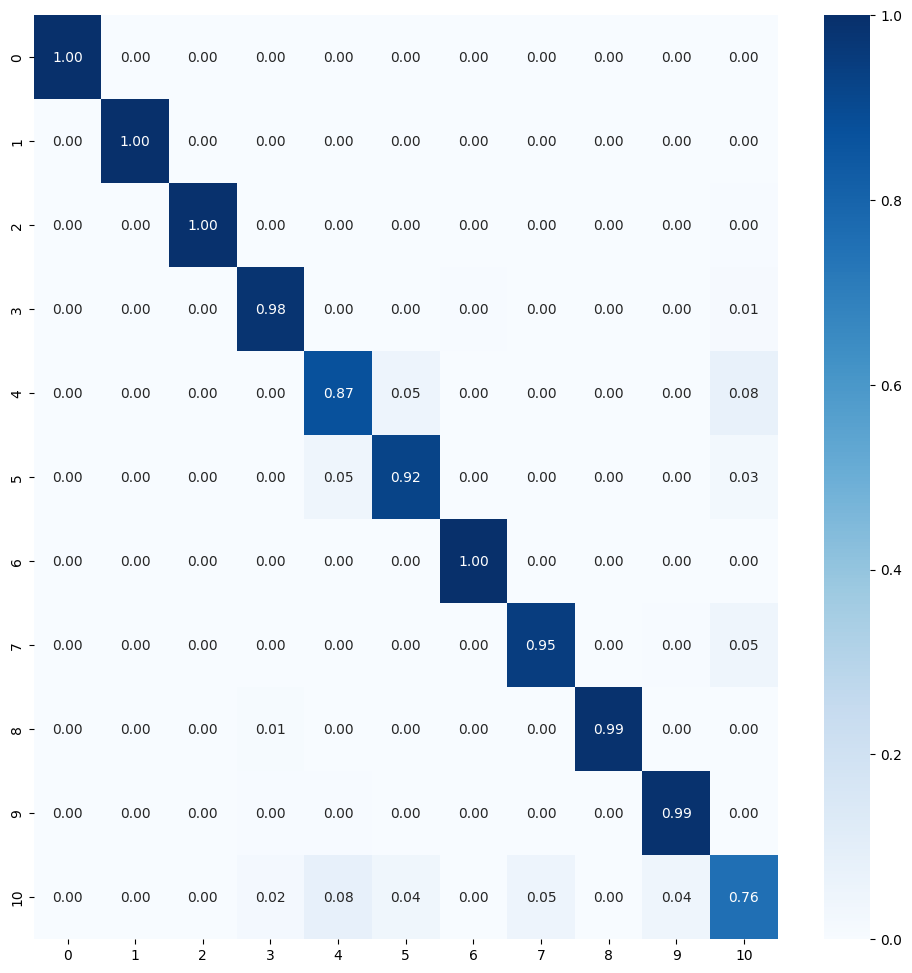


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3822795
Trainable params: 1645579
Non-trainable params: 2177216
Epoch 1/50
360/360 [==============================] - 67s 157ms/step - loss: 1.6414 - accuracy: 0.7641 - val_loss: 1.1873 - val_accuracy: 0.8985 - lr: 1.0000e-04
Epoch 2/50
360/360 [==============================] - 56s 157ms/step - loss: 1.2130 - accuracy: 0.8797 - val_loss: 1.0957 - val_accuracy: 0.9095 - lr: 1.0000e-04
Epoch 3/50
360/360 [==============================] - 51s 142ms/step - loss: 1.1085 - accuracy: 0.9070 - val_loss: 1.0368 - val_accuracy: 0.9233 - lr: 1.0000e-04
Epoch 4/50
360/360 [==============================] - 42s 118ms/step - loss: 1.0407 - accuracy: 0.9188 - val_loss: 1.0016 - val_accuracy: 0.9269 - lr: 1.0000e-04
Epoch 5/50
360/360 [==============================] - 66s 180ms/step - loss: 0.9846 - accuracy: 0.9334 - val_loss: 0.9647 - val_accuracy: 0.9290 - lr: 1.0000e-04
Epoch 6/50
360/360 [==============================] - 67s 186ms/step - los

Model and History saved...
361/361 [==============================] - 60s 165ms/step - loss: 0.0687 - accuracy: 0.9913
Train Accuracy: 0.9913420081138611
Train Log Loss: 0.06871338188648224
78/78 [==============================] - 13s 164ms/step - loss: 0.3555 - accuracy: 0.9434
Validation Accuracy: 0.9434343576431274
Validation Log Loss: 0.35552099347114563
78/78 [==============================] - 13s 162ms/step - loss: 0.3130 - accuracy: 0.9519
Test Accuracy: 0.9519191980361938
Test Log Loss: 0.31299635767936707
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1]
 [  0   0   0 222   0   0   1   0   0   0   2]
 [  0   0   0   0 206   9   0   0   0   0  10]
 [  0   0   0   0  14 206   0   0   0   0   5]
 [  0  

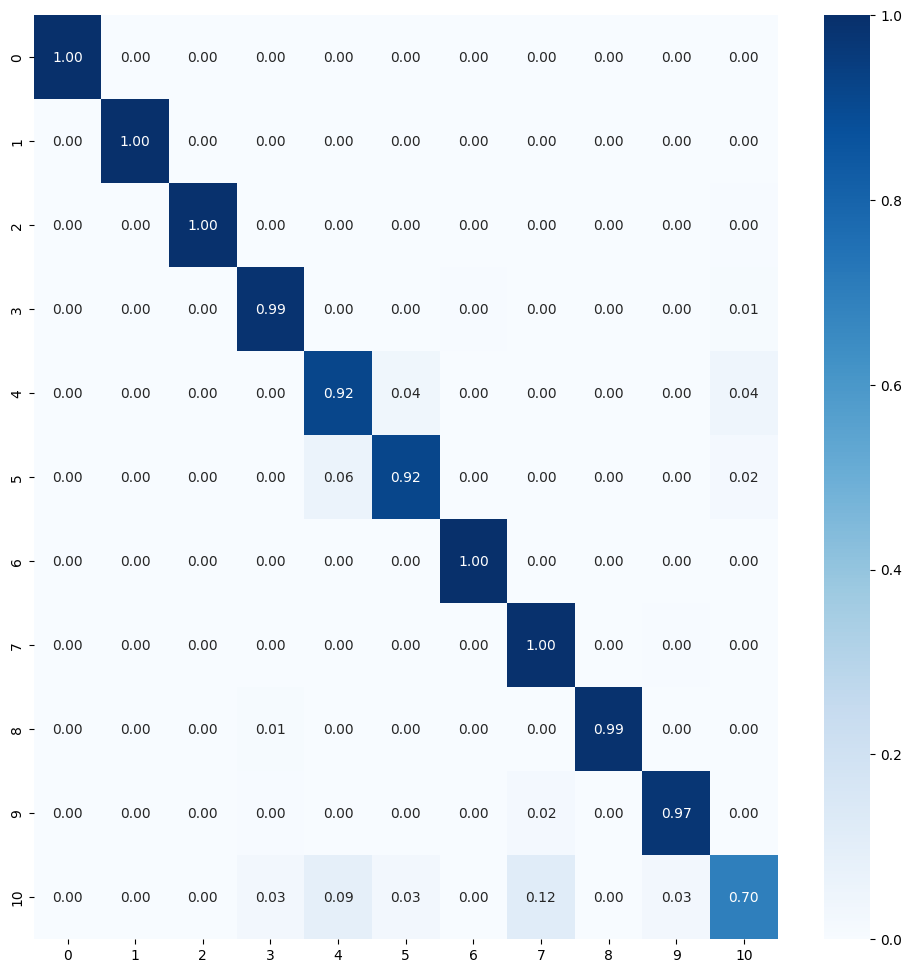

Average training accuracy in 5-fold: 0.9932106256484985
Average validation precision in 5-fold: 0.9468344211578369
/nTest Metrics
test_acc_list: [0.9470707178115845, 0.9498990178108215, 0.9397979974746704, 0.9507070779800415, 0.9519191980361938]
Average Test Accuracy with 5-fold: 0.9478788018226624
test_loss_list: [0.29584020376205444, 0.37843766808509827, 0.3292778730392456, 0.2881024181842804, 0.31299635767936707]
Average Test Log Loss with 5-fold: 0.32093090415000913

Precision List: [0.9471937129773224, 0.9502479158932203, 0.9442680823962849, 0.9499399638152376, 0.9523184930969406]
Average Precision List with 5-fold: 0.9487936336358012
Recall List: [0.9470707070707072, 0.94989898989899, 0.93979797979798, 0.9507070707070707, 0.9519191919191919]
Average Recall List with 5-fold: 0.947878787878788
F1 Score List: [0.9468733204295332, 0.9478602128978916, 0.9404218383698383, 0.9501617593262498, 0.950529557799085]
Average F1 Score List with 5-fold: 0.9471693377645195

Metrics List Store

t

In [23]:
%%time

num_classes = 11
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/12
name_save_model: fusion_MobileNet_tf_optimized 12
Found 12600 images belonging to 12 classes.
Found 2700 images belonging to 12 classes.
Found 2700 images belonging to 12 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3822924
Trainable params: 1645708
Non-trainable params: 2177216
Epoch 1/50
393/393 [==============================] - 91s 197ms/step - loss: 1.6669 - accuracy: 0.7547 - val_loss: 1.1816 - val_accuracy: 0.8832 - lr: 1.0000e-04
Epoch 2/50
393/393 [==============================] - 60s 153ms/step - loss: 1.2090 - accuracy: 0.8815 - val_loss: 1.0824 - val_accuracy: 0.9204 - lr: 1.0000e-04
Epoch 3/50
393/393 [==============================] - 62s 156ms/step - loss: 1.0978 - accuracy: 0.9098 - val_loss: 1.0434 - val_accuracy: 0.924

Model and History saved...
394/394 [==============================] - 56s 142ms/step - loss: 0.0599 - accuracy: 0.9927
Train Accuracy: 0.9926984310150146
Train Log Loss: 0.05990910157561302
85/85 [==============================] - 13s 145ms/step - loss: 0.3410 - accuracy: 0.9367
Validation Accuracy: 0.9366666674613953
Validation Log Loss: 0.3410455882549286
85/85 [==============================] - 12s 139ms/step - loss: 0.2879 - accuracy: 0.9470
Test Accuracy: 0.9470370411872864
Test Log Loss: 0.28787872195243835
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1]
 [  0   0   0 220   2   0   0   0   2   0   0   1]
 [  0   0   0   0 224   0   0   0   0   0   0   1]
 [  0   0   0   0  

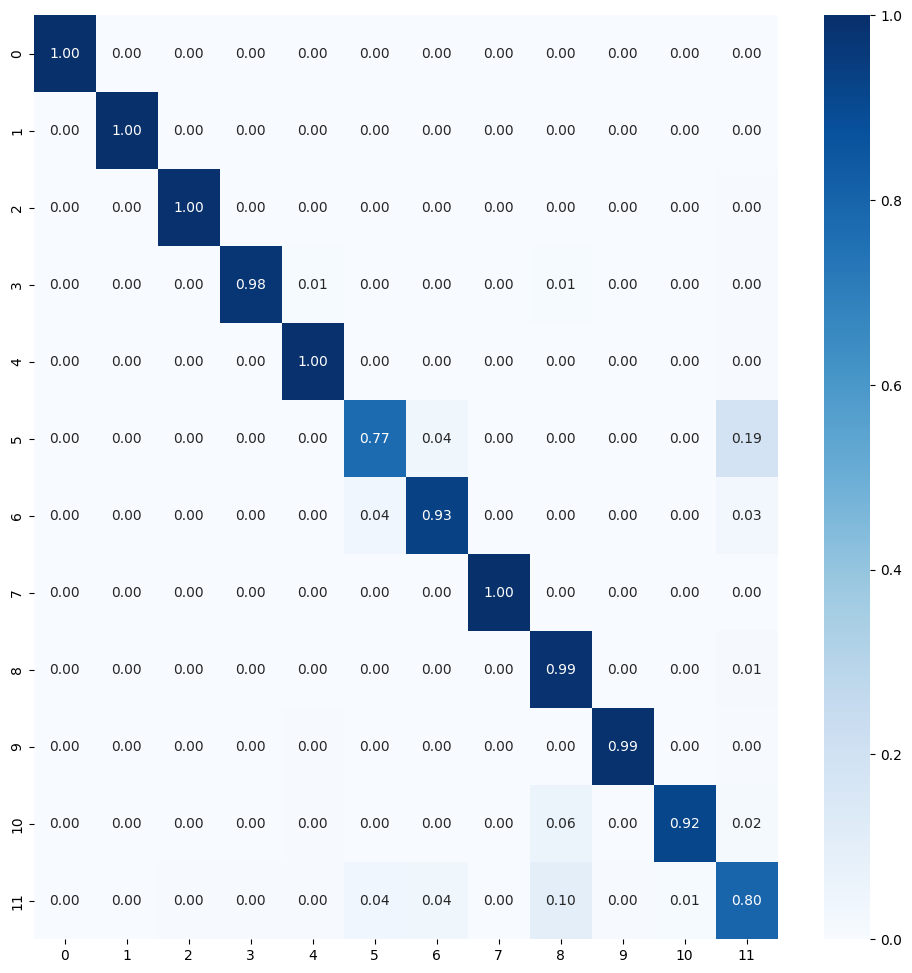


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3822924
Trainable params: 1645708
Non-trainable params: 2177216
Epoch 1/50
393/393 [==============================] - 82s 180ms/step - loss: 1.6170 - accuracy: 0.7673 - val_loss: 1.1793 - val_accuracy: 0.8955 - lr: 1.0000e-04
Epoch 2/50
393/393 [==============================] - 67s 170ms/step - loss: 1.2037 - accuracy: 0.8793 - val_loss: 1.0735 - val_accuracy: 0.9174 - lr: 1.0000e-04
Epoch 3/50
393/393 [==============================] - 63s 158ms/step - loss: 1.0940 - accuracy: 0.9095 - val_loss: 1.0217 - val_accuracy: 0.9245 - lr: 1.0000e-04
Epoch 4/50
393/393 [==============================] - 60s 152ms/step - loss: 1.0249 - accuracy: 0.9254 - val_loss: 0.9810 - val_accuracy: 0.9319 - lr: 1.0000e-04
Epoch 5/50
393/393 [==============================] - 62s 157ms/step - loss: 0.9733 - accuracy: 0.9334 - val_loss: 0.9384 - val_accuracy: 0.9382 - lr: 1.0000e-04
Epoch 6/50
393/393 [==============================] - 63s 158ms/step - los

Model and History saved...
394/394 [==============================] - 58s 145ms/step - loss: 0.0505 - accuracy: 0.9975
Train Accuracy: 0.9974603056907654
Train Log Loss: 0.05053631588816643
85/85 [==============================] - 13s 147ms/step - loss: 0.2990 - accuracy: 0.9511
Validation Accuracy: 0.9511111378669739
Validation Log Loss: 0.29897749423980713
85/85 [==============================] - 14s 147ms/step - loss: 0.2733 - accuracy: 0.9548
Test Accuracy: 0.9548147916793823
Test Log Loss: 0.27331292629241943
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 222   1   1   0   0   0   0   1   0]
 [  0   0   0   0 222   1   0   0   0   0   0   2]
 [  0   0   0   0 

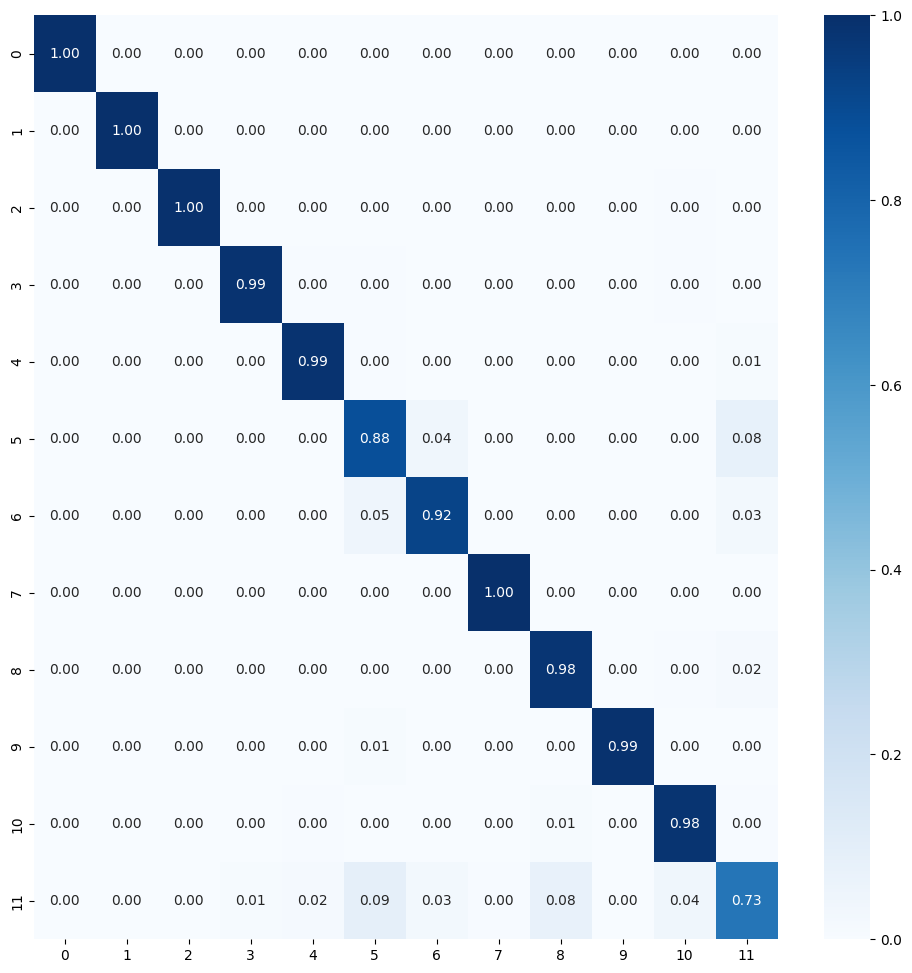


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3822924
Trainable params: 1645708
Non-trainable params: 2177216
Epoch 1/50
393/393 [==============================] - 92s 186ms/step - loss: 1.6556 - accuracy: 0.7604 - val_loss: 1.1790 - val_accuracy: 0.8966 - lr: 1.0000e-04
Epoch 2/50
393/393 [==============================] - 79s 200ms/step - loss: 1.1996 - accuracy: 0.8855 - val_loss: 1.0874 - val_accuracy: 0.9152 - lr: 1.0000e-04
Epoch 3/50
393/393 [==============================] - 74s 186ms/step - loss: 1.0968 - accuracy: 0.9106 - val_loss: 1.0313 - val_accuracy: 0.9289 - lr: 1.0000e-04
Epoch 4/50
393/393 [==============================] - 79s 200ms/step - loss: 1.0303 - accuracy: 0.9246 - val_loss: 0.9982 - val_accuracy: 0.9286 - lr: 1.0000e-04
Epoch 5/50
393/393 [==============================] - 72s 179ms/step - loss: 0.9765 - accuracy: 0.9340 - val_loss: 0.9650 - val_accuracy: 0.9371 - lr: 1.0000e-04
Epoch 6/50
393/393 [==============================] - 71s 180ms/step - los

Model and History saved...
394/394 [==============================] - 49s 123ms/step - loss: 0.0776 - accuracy: 0.9849
Train Accuracy: 0.9849206209182739
Train Log Loss: 0.07764344662427902
85/85 [==============================] - 12s 132ms/step - loss: 0.4005 - accuracy: 0.9367
Validation Accuracy: 0.9366666674613953
Validation Log Loss: 0.40053296089172363
85/85 [==============================] - 12s 137ms/step - loss: 0.3578 - accuracy: 0.9474
Test Accuracy: 0.9474074244499207
Test Log Loss: 0.35781311988830566
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   1   1   0   0   1   0   1   0]
 [  0   0   0   0 223   1   0   0   0   0   0   1]
 [  0   0   0   0 

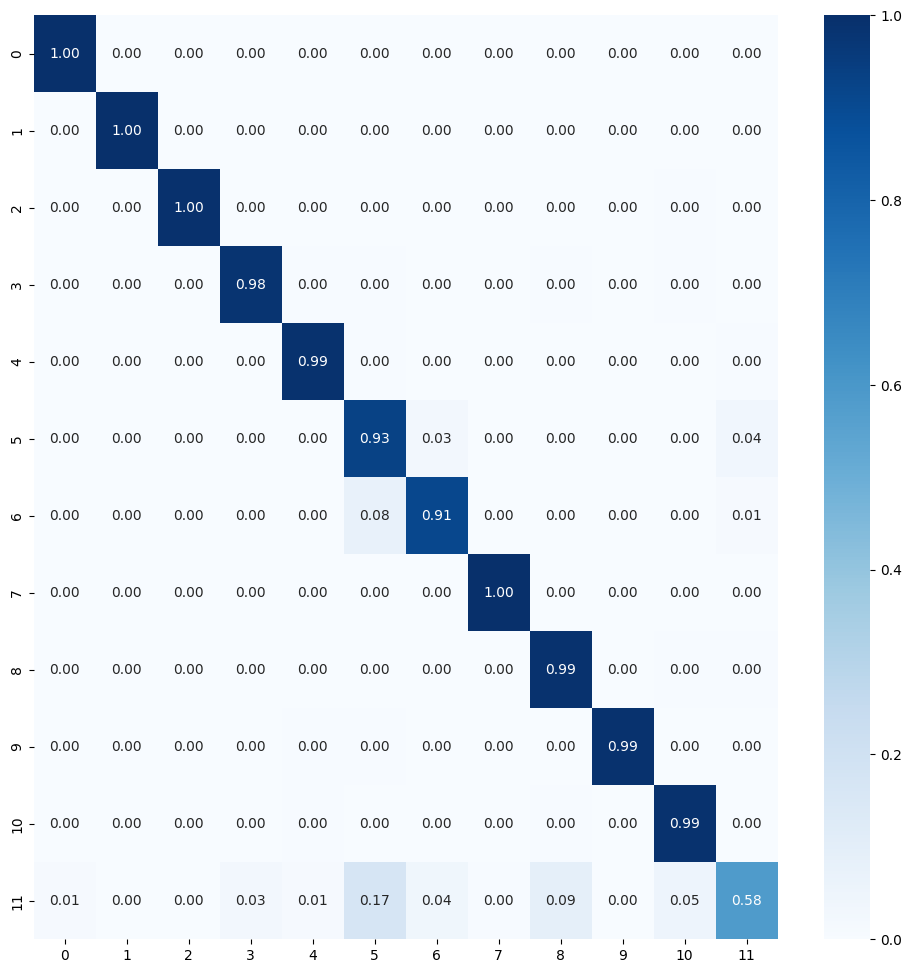


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3822924
Trainable params: 1645708
Non-trainable params: 2177216
Epoch 1/50
393/393 [==============================] - 60s 129ms/step - loss: 1.6231 - accuracy: 0.7681 - val_loss: 1.1669 - val_accuracy: 0.8943 - lr: 1.0000e-04
Epoch 2/50
393/393 [==============================] - 59s 150ms/step - loss: 1.2106 - accuracy: 0.8787 - val_loss: 1.0762 - val_accuracy: 0.9159 - lr: 1.0000e-04
Epoch 3/50
393/393 [==============================] - 69s 176ms/step - loss: 1.0956 - accuracy: 0.9095 - val_loss: 1.0279 - val_accuracy: 0.9256 - lr: 1.0000e-04
Epoch 4/50
393/393 [==============================] - 60s 154ms/step - loss: 1.0348 - accuracy: 0.9243 - val_loss: 0.9833 - val_accuracy: 0.9345 - lr: 1.0000e-04
Epoch 5/50
393/393 [==============================] - 65s 164ms/step - loss: 0.9710 - accuracy: 0.9350 - val_loss: 0.9467 - val_accuracy: 0.9338 - lr: 1.0000e-04
Epoch 6/50
393/393 [==============================] - 66s 167ms/step - los

Model and History saved...
394/394 [==============================] - 51s 128ms/step - loss: 0.0531 - accuracy: 0.9952
Train Accuracy: 0.9952380657196045
Train Log Loss: 0.05311767756938934
85/85 [==============================] - 11s 131ms/step - loss: 0.2815 - accuracy: 0.9463
Validation Accuracy: 0.9462962746620178
Validation Log Loss: 0.2815006375312805
85/85 [==============================] - 11s 125ms/step - loss: 0.2547 - accuracy: 0.9530
Test Accuracy: 0.9529629349708557
Test Log Loss: 0.25466203689575195
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1]
 [  0   0   0 219   2   0   0   0   1   0   0   3]
 [  0   0   0   0 218   0   0   1   0   0   0   6]
 [  0   0   0   0  

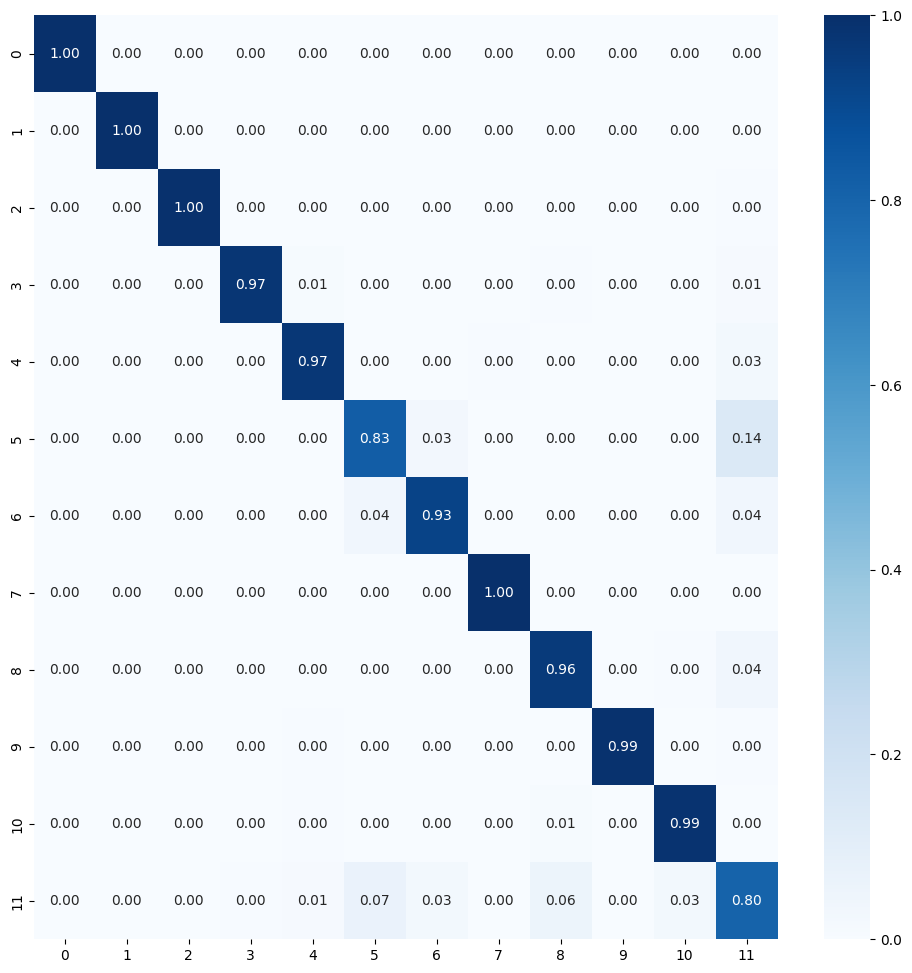


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3822924
Trainable params: 1645708
Non-trainable params: 2177216
Epoch 1/50
393/393 [==============================] - 73s 162ms/step - loss: 1.6330 - accuracy: 0.7635 - val_loss: 1.1816 - val_accuracy: 0.8917 - lr: 1.0000e-04
Epoch 2/50
393/393 [==============================] - 61s 155ms/step - loss: 1.2023 - accuracy: 0.8856 - val_loss: 1.0776 - val_accuracy: 0.9193 - lr: 1.0000e-04
Epoch 3/50
393/393 [==============================] - 62s 157ms/step - loss: 1.0943 - accuracy: 0.9105 - val_loss: 1.0302 - val_accuracy: 0.9293 - lr: 1.0000e-04
Epoch 4/50
393/393 [==============================] - 63s 159ms/step - loss: 1.0305 - accuracy: 0.9270 - val_loss: 0.9853 - val_accuracy: 0.9301 - lr: 1.0000e-04
Epoch 5/50
393/393 [==============================] - 63s 160ms/step - loss: 0.9749 - accuracy: 0.9341 - val_loss: 0.9466 - val_accuracy: 0.9364 - lr: 1.0000e-04
Epoch 6/50
393/393 [==============================] - 63s 161ms/step - los

Model and History saved...
394/394 [==============================] - 51s 128ms/step - loss: 0.0529 - accuracy: 0.9975
Train Accuracy: 0.9975396990776062
Train Log Loss: 0.052877288311719894
85/85 [==============================] - 11s 122ms/step - loss: 0.3030 - accuracy: 0.9533
Validation Accuracy: 0.95333331823349
Validation Log Loss: 0.30301547050476074
85/85 [==============================] - 11s 123ms/step - loss: 0.2848 - accuracy: 0.9559
Test Accuracy: 0.9559259414672852
Test Log Loss: 0.2848260700702667
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   2   0   0   0   1   0   0   1]
 [  0   0   0   0 220   0   1   0   1   0   0   3]
 [  0   0   0   0   

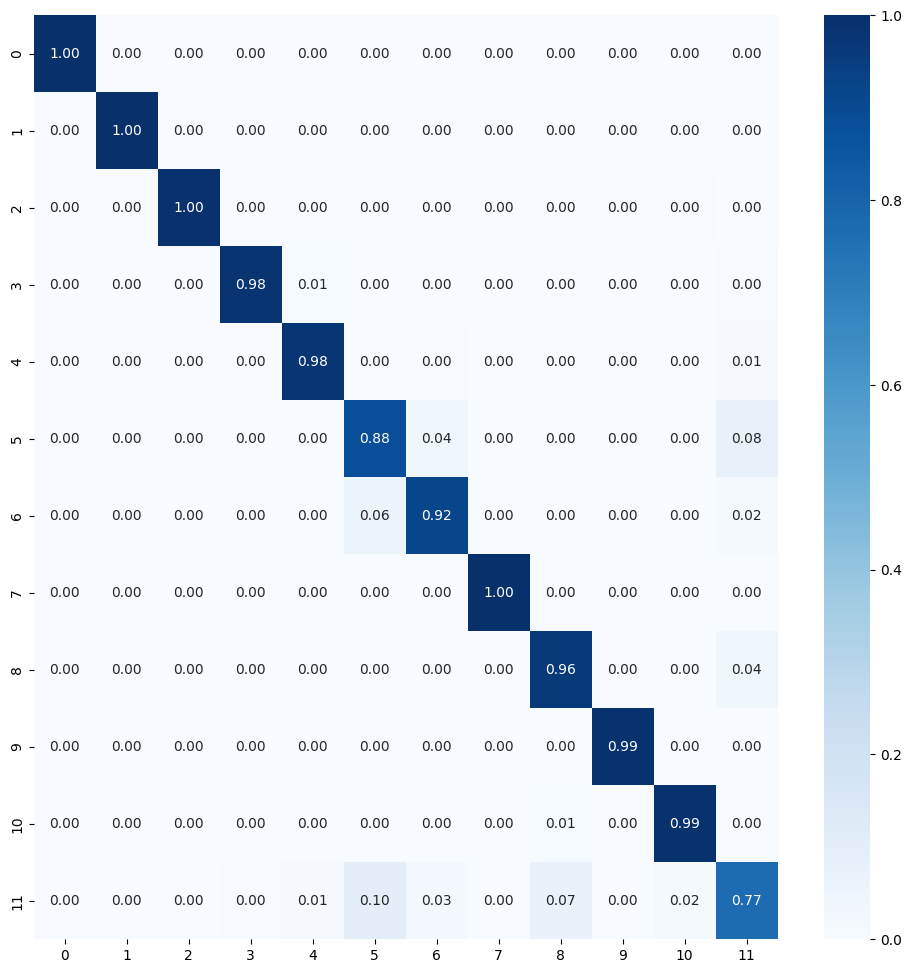

Average training accuracy in 5-fold: 0.9946371793746949
Average validation precision in 5-fold: 0.9526041626930237
/nTest Metrics
test_acc_list: [0.9470370411872864, 0.9548147916793823, 0.9474074244499207, 0.9529629349708557, 0.9559259414672852]
Average Test Accuracy with 5-fold: 0.9516296267509461
test_loss_list: [0.28787872195243835, 0.27331292629241943, 0.35781311988830566, 0.25466203689575195, 0.2848260700702667]
Average Test Log Loss with 5-fold: 0.2916985750198364

Precision List: [0.94929064416791, 0.9541714011100698, 0.9491583062866261, 0.9538288094974692, 0.9557909573321391]
Average Precision List with 5-fold: 0.9524480236788427
Recall List: [0.9470370370370369, 0.9548148148148149, 0.9474074074074075, 0.9529629629629629, 0.9559259259259258]
Average Recall List with 5-fold: 0.9516296296296296
F1 Score List: [0.9470454106486738, 0.9540494760520025, 0.944500499627273, 0.9531899413419859, 0.9556455821829634]
Average F1 Score List with 5-fold: 0.9508861819705798

Metrics List Store

In [24]:
%%time

num_classes = 12
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/13
name_save_model: fusion_MobileNet_tf_optimized 13
Found 13650 images belonging to 13 classes.
Found 2925 images belonging to 13 classes.
Found 2925 images belonging to 13 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3823053
Trainable params: 1645837
Non-trainable params: 2177216
Epoch 1/50
426/426 [==============================] - 78s 162ms/step - loss: 1.6241 - accuracy: 0.7691 - val_loss: 1.1645 - val_accuracy: 0.9032 - lr: 1.0000e-04
Epoch 2/50
426/426 [==============================] - 66s 153ms/step - loss: 1.1923 - accuracy: 0.8853 - val_loss: 1.0557 - val_accuracy: 0.9279 - lr: 1.0000e-04
Epoch 3/50
426/426 [==============================] - 64s 151ms/step - loss: 1.0816 - accuracy: 0.9136 - val_loss: 1.0280 - val_accura

Model and History saved...
427/427 [==============================] - 55s 126ms/step - loss: 0.0517 - accuracy: 0.9939
Train Accuracy: 0.9939194321632385
Train Log Loss: 0.05172266066074371
92/92 [==============================] - 13s 129ms/step - loss: 0.2774 - accuracy: 0.9422
Validation Accuracy: 0.9422222375869751
Validation Log Loss: 0.2774050533771515
92/92 [==============================] - 12s 127ms/step - loss: 0.2518 - accuracy: 0.9491
Test Accuracy: 0.9490598440170288
Test Log Loss: 0.2517774701118469
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 219   1   0   2   0   0   0   0   0   3]
 [  0   0   0   1 219   0   1   0   0   1

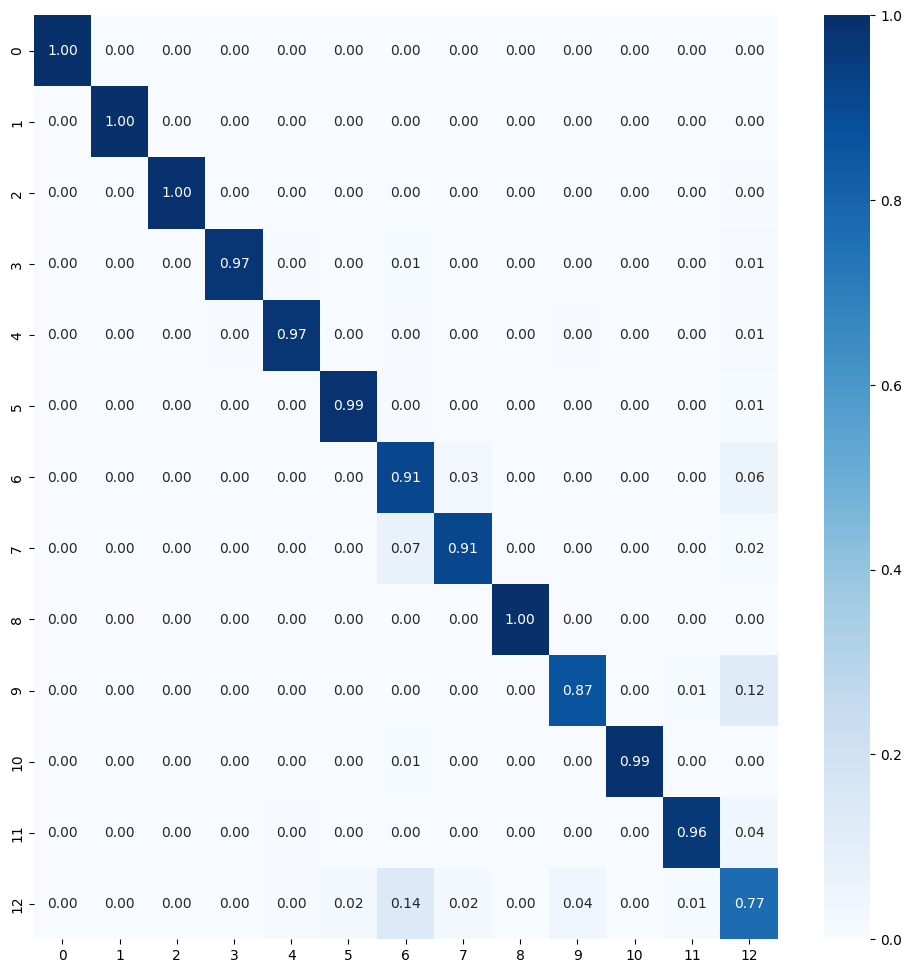


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3823053
Trainable params: 1645837
Non-trainable params: 2177216
Epoch 1/50
426/426 [==============================] - 78s 159ms/step - loss: 1.6580 - accuracy: 0.7665 - val_loss: 1.1546 - val_accuracy: 0.9052 - lr: 1.0000e-04
Epoch 2/50
426/426 [==============================] - 66s 153ms/step - loss: 1.1938 - accuracy: 0.8874 - val_loss: 1.0628 - val_accuracy: 0.9258 - lr: 1.0000e-04
Epoch 3/50
426/426 [==============================] - 66s 155ms/step - loss: 1.0867 - accuracy: 0.9126 - val_loss: 1.0069 - val_accuracy: 0.9358 - lr: 1.0000e-04
Epoch 4/50
426/426 [==============================] - 65s 153ms/step - loss: 1.0105 - accuracy: 0.9297 - val_loss: 0.9696 - val_accuracy: 0.9341 - lr: 1.0000e-04
Epoch 5/50
426/426 [==============================] - 65s 152ms/step - loss: 0.9533 - accuracy: 0.9376 - val_loss: 0.9306 - val_accuracy: 0.9354 - lr: 1.0000e-04
Epoch 6/50
426/426 [==============================] - 65s 153ms/step - los

Model and History saved...
427/427 [==============================] - 58s 135ms/step - loss: 0.5677 - accuracy: 0.9847
Train Accuracy: 0.9846886396408081
Train Log Loss: 0.5677065253257751
92/92 [==============================] - 14s 139ms/step - loss: 0.6788 - accuracy: 0.9528
Validation Accuracy: 0.9528205394744873
Validation Log Loss: 0.6788046956062317
92/92 [==============================] - 13s 138ms/step - loss: 0.6692 - accuracy: 0.9566
Test Accuracy: 0.956581175327301
Test Log Loss: 0.6692273616790771
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 222   1   0   0   0   0   1   0   1   0]
 [  0   0   0   0 220   0   1   0   1   0  

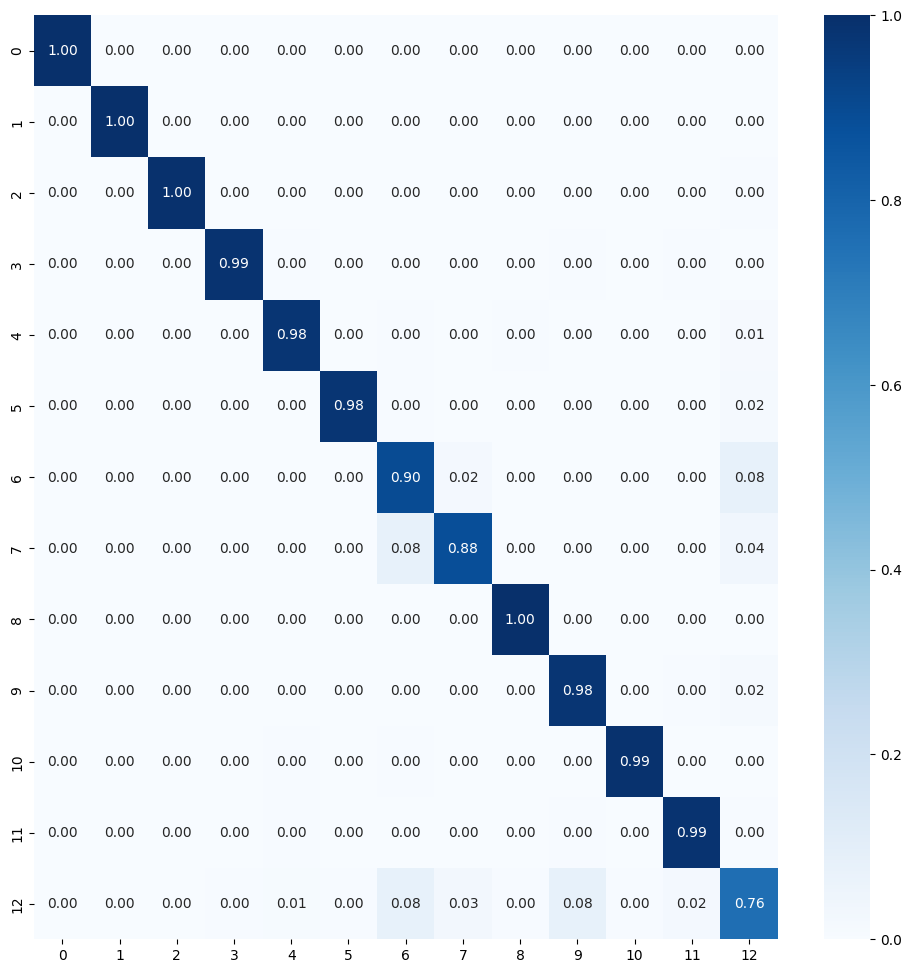


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3823053
Trainable params: 1645837
Non-trainable params: 2177216
Epoch 1/50
426/426 [==============================] - 86s 173ms/step - loss: 1.6878 - accuracy: 0.7576 - val_loss: 1.1712 - val_accuracy: 0.8963 - lr: 1.0000e-04
Epoch 2/50
426/426 [==============================] - 74s 172ms/step - loss: 1.2013 - accuracy: 0.8840 - val_loss: 1.0587 - val_accuracy: 0.9248 - lr: 1.0000e-04
Epoch 3/50
426/426 [==============================] - 73s 172ms/step - loss: 1.0952 - accuracy: 0.9135 - val_loss: 1.0131 - val_accuracy: 0.9341 - lr: 1.0000e-04
Epoch 4/50
426/426 [==============================] - 70s 164ms/step - loss: 1.0189 - accuracy: 0.9279 - val_loss: 0.9778 - val_accuracy: 0.9354 - lr: 1.0000e-04
Epoch 5/50
426/426 [==============================] - 71s 164ms/step - loss: 0.9632 - accuracy: 0.9391 - val_loss: 0.9564 - val_accuracy: 0.9296 - lr: 1.0000e-04
Epoch 6/50
426/426 [==============================] - 71s 167ms/step - los

Model and History saved...
427/427 [==============================] - 56s 130ms/step - loss: 0.0499 - accuracy: 0.9953
Train Accuracy: 0.9953113794326782
Train Log Loss: 0.04989267513155937
92/92 [==============================] - 12s 127ms/step - loss: 0.3109 - accuracy: 0.9415
Validation Accuracy: 0.9415384531021118
Validation Log Loss: 0.31085005402565
92/92 [==============================] - 12s 126ms/step - loss: 0.2728 - accuracy: 0.9480
Test Accuracy: 0.9480341672897339
Test Log Loss: 0.27284106612205505
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 220   2   0   0   0   0   0   0   0   3]
 [  0   0   0   0 222   0   1   0   1   0 

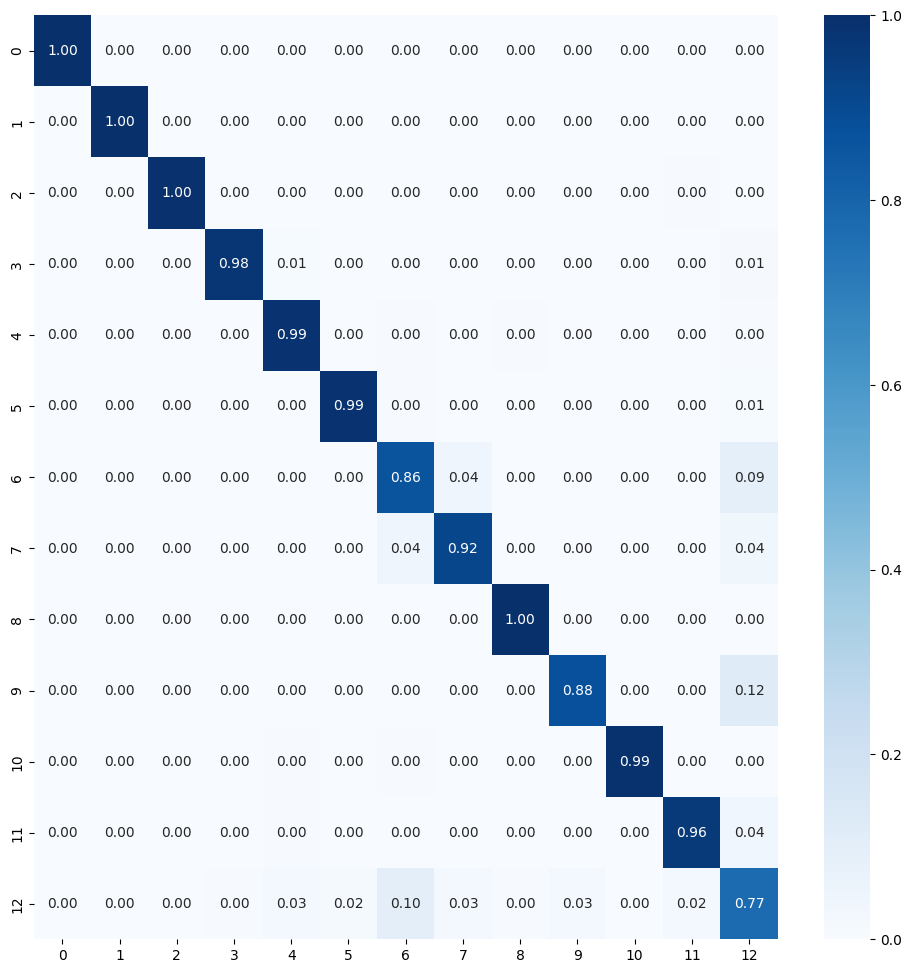


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3823053
Trainable params: 1645837
Non-trainable params: 2177216
Epoch 1/50
426/426 [==============================] - 79s 161ms/step - loss: 1.6224 - accuracy: 0.7718 - val_loss: 1.1453 - val_accuracy: 0.9059 - lr: 1.0000e-04
Epoch 2/50
426/426 [==============================] - 67s 157ms/step - loss: 1.1964 - accuracy: 0.8861 - val_loss: 1.0633 - val_accuracy: 0.9286 - lr: 1.0000e-04
Epoch 3/50
426/426 [==============================] - 68s 158ms/step - loss: 1.0896 - accuracy: 0.9150 - val_loss: 1.0112 - val_accuracy: 0.9320 - lr: 1.0000e-04
Epoch 4/50
426/426 [==============================] - 77s 180ms/step - loss: 1.0185 - accuracy: 0.9279 - val_loss: 0.9846 - val_accuracy: 0.9330 - lr: 1.0000e-04
Epoch 5/50
426/426 [==============================] - 68s 159ms/step - loss: 0.9634 - accuracy: 0.9378 - val_loss: 0.9423 - val_accuracy: 0.9375 - lr: 1.0000e-04
Epoch 6/50
426/426 [==============================] - 67s 157ms/step - los

Model and History saved...
427/427 [==============================] - 61s 141ms/step - loss: 0.0513 - accuracy: 0.9947
Train Accuracy: 0.9947252869606018
Train Log Loss: 0.051311664283275604
92/92 [==============================] - 13s 141ms/step - loss: 0.2999 - accuracy: 0.9508
Validation Accuracy: 0.9507692456245422
Validation Log Loss: 0.29986053705215454
92/92 [==============================] - 13s 141ms/step - loss: 0.2820 - accuracy: 0.9562
Test Accuracy: 0.9562393426895142
Test Log Loss: 0.28199806809425354
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 220   1   0   1   0   0   0   0   2   1]
 [  0   0   0   0 222   0   0   0   1 

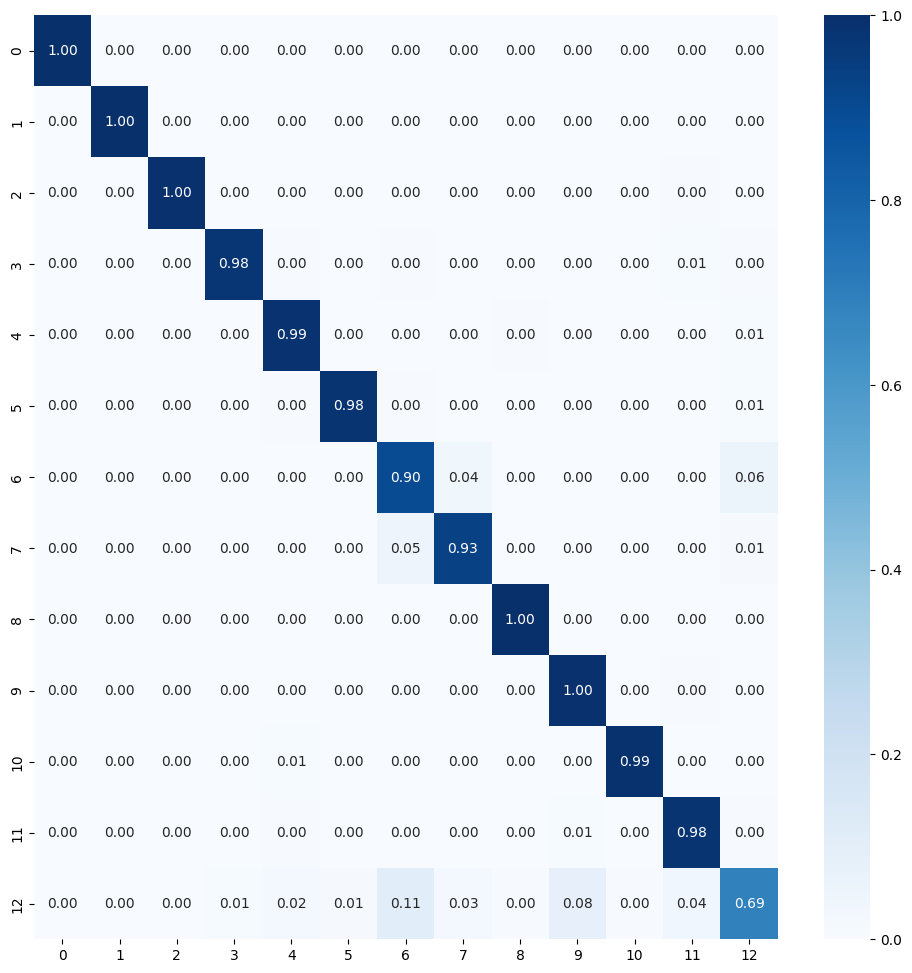


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3823053
Trainable params: 1645837
Non-trainable params: 2177216
Epoch 1/50
426/426 [==============================] - 90s 183ms/step - loss: 1.6407 - accuracy: 0.7635 - val_loss: 1.1565 - val_accuracy: 0.8977 - lr: 1.0000e-04
Epoch 2/50
426/426 [==============================] - 76s 179ms/step - loss: 1.1962 - accuracy: 0.8852 - val_loss: 1.0531 - val_accuracy: 0.9279 - lr: 1.0000e-04
Epoch 3/50
426/426 [==============================] - 76s 177ms/step - loss: 1.0836 - accuracy: 0.9158 - val_loss: 1.0104 - val_accuracy: 0.9313 - lr: 1.0000e-04
Epoch 4/50
426/426 [==============================] - 75s 175ms/step - loss: 1.0192 - accuracy: 0.9268 - val_loss: 0.9639 - val_accuracy: 0.9378 - lr: 1.0000e-04
Epoch 5/50
426/426 [==============================] - 75s 173ms/step - loss: 0.9524 - accuracy: 0.9376 - val_loss: 0.9211 - val_accuracy: 0.9430 - lr: 1.0000e-04
Epoch 6/50
426/426 [==============================] - 75s 175ms/step - los

Model and History saved...
427/427 [==============================] - 57s 132ms/step - loss: 0.0486 - accuracy: 0.9948
Train Accuracy: 0.9947985410690308
Train Log Loss: 0.04857539385557175
92/92 [==============================] - 12s 130ms/step - loss: 0.2844 - accuracy: 0.9460
Validation Accuracy: 0.9459829330444336
Validation Log Loss: 0.28435850143432617
92/92 [==============================] - 12s 133ms/step - loss: 0.2722 - accuracy: 0.9525
Test Accuracy: 0.9524786472320557
Test Log Loss: 0.27219343185424805
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 220   2   0   1   0   0   1   0   0   1]
 [  0   0   0   0 222   0   1   0   0  

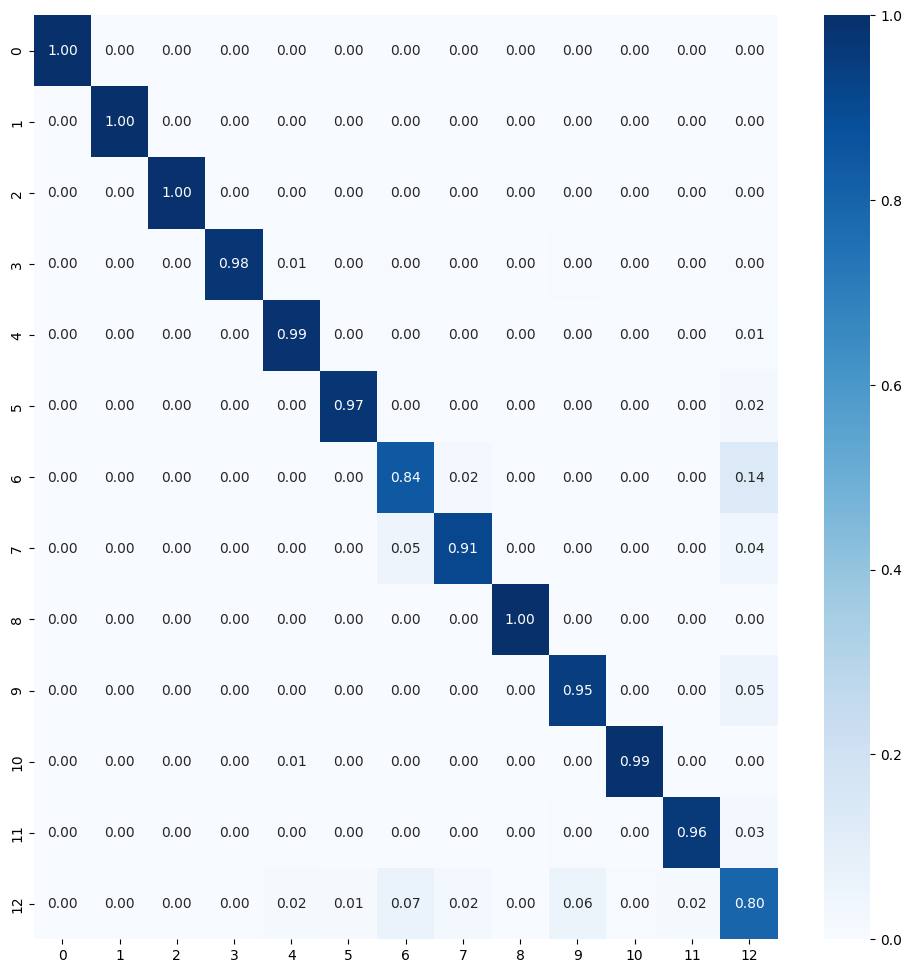

Average training accuracy in 5-fold: 0.9934792160987854
Average validation precision in 5-fold: 0.9541895627975464
/nTest Metrics
test_acc_list: [0.9490598440170288, 0.956581175327301, 0.9480341672897339, 0.9562393426895142, 0.9524786472320557]
Average Test Accuracy with 5-fold: 0.9524786353111268
test_loss_list: [0.2517774701118469, 0.6692273616790771, 0.27284106612205505, 0.28199806809425354, 0.27219343185424805]
Average Test Log Loss with 5-fold: 0.34960747957229615

Precision List: [0.9517738039991255, 0.9567062045286765, 0.9501296056148127, 0.9558690399676858, 0.9540159180221368]
Average Precision List with 5-fold: 0.9536989144264874
Recall List: [0.949059829059829, 0.9565811965811964, 0.9480341880341882, 0.9562393162393162, 0.9524786324786325]
Average Recall List with 5-fold: 0.9524786324786325
F1 Score List: [0.9498660996207425, 0.956328975168568, 0.9487420287445238, 0.9549802979907291, 0.9530536279796553]
Average F1 Score List with 5-fold: 0.9525942059008438

Metrics List Store

In [25]:
%%time

num_classes = 13
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/14
name_save_model: fusion_MobileNet_tf_optimized 14
Found 14700 images belonging to 14 classes.
Found 3150 images belonging to 14 classes.
Found 3150 images belonging to 14 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew
- small

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3823182
Trainable params: 1645966
Non-trainable params: 2177216
Epoch 1/50
459/459 [==============================] - 89s 169ms/step - loss: 1.7616 - accuracy: 0.7113 - val_loss: 1.2274 - val_accuracy: 0.8581 - lr: 1.0000e-04
Epoch 2/50
459/459 [==============================] - 73s 159ms/step - loss: 1.2803 - accuracy: 0.8374 - val_loss: 1.1368 - val_accuracy: 0.8916 - lr: 1.0000e-04
Epoch 3/50
459/459 [==============================] - 76s 165ms/step - loss: 1.1912 - accuracy: 0.8603 - val_loss: 1.0908 - va

Model and History saved...
460/460 [==============================] - 57s 122ms/step - loss: 0.1111 - accuracy: 0.9693
Train Accuracy: 0.9692516922950745
Train Log Loss: 0.11106371134519577
99/99 [==============================] - 13s 128ms/step - loss: 0.3397 - accuracy: 0.9238
Validation Accuracy: 0.9238095283508301
Validation Log Loss: 0.3396669924259186
99/99 [==============================] - 13s 124ms/step - loss: 0.3305 - accuracy: 0.9235
Test Accuracy: 0.9234920740127563
Test Log Loss: 0.3305320739746094
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   1   0   0   0   0   3   0   0   0   0]
 [  0   0   

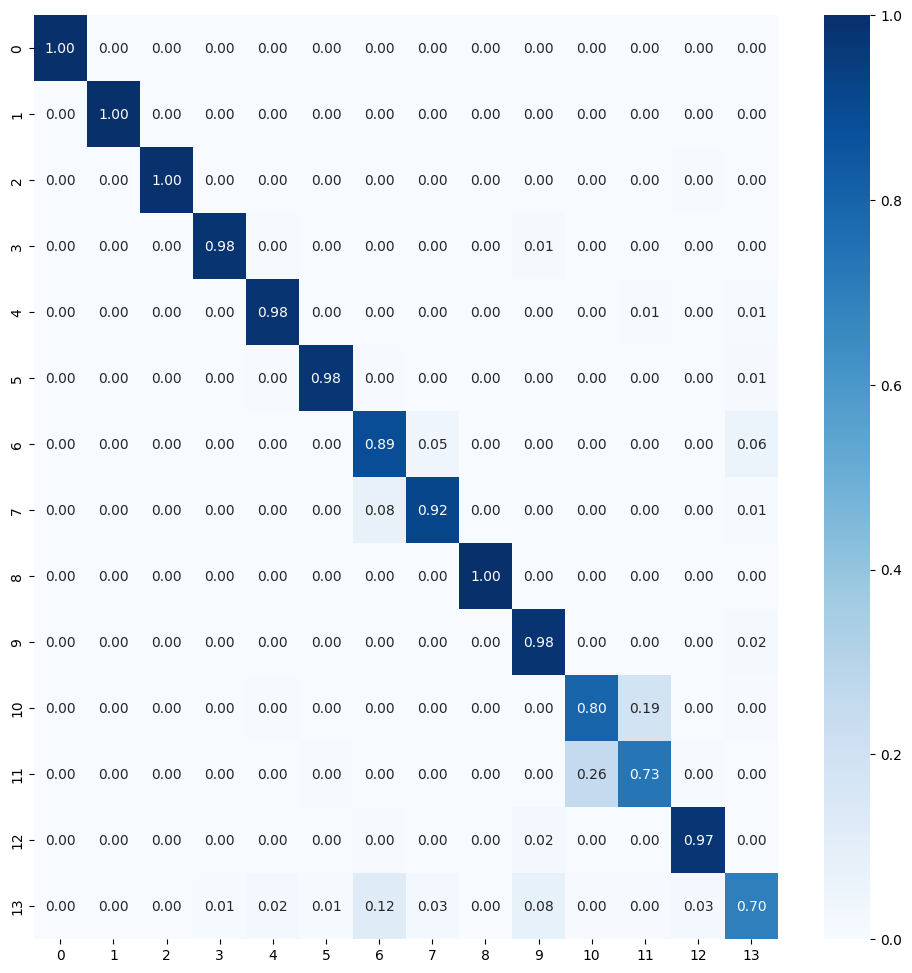


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3823182
Trainable params: 1645966
Non-trainable params: 2177216
Epoch 1/50
459/459 [==============================] - 83s 159ms/step - loss: 1.7621 - accuracy: 0.7158 - val_loss: 1.2542 - val_accuracy: 0.8447 - lr: 1.0000e-04
Epoch 2/50
459/459 [==============================] - 78s 170ms/step - loss: 1.2996 - accuracy: 0.8337 - val_loss: 1.1412 - val_accuracy: 0.8744 - lr: 1.0000e-04
Epoch 3/50
459/459 [==============================] - 60s 130ms/step - loss: 1.1754 - accuracy: 0.8691 - val_loss: 1.1096 - val_accuracy: 0.8820 - lr: 1.0000e-04
Epoch 4/50
459/459 [==============================] - 68s 148ms/step - loss: 1.1049 - accuracy: 0.8794 - val_loss: 1.0499 - val_accuracy: 0.8897 - lr: 1.0000e-04
Epoch 5/50
459/459 [==============================] - 76s 166ms/step - loss: 1.0445 - accuracy: 0.8882 - val_loss: 1.0202 - val_accuracy: 0.9002 - lr: 1.0000e-04
Epoch 6/50
459/459 [==============================] - 78s 170ms/step - los

Model and History saved...
460/460 [==============================] - 63s 137ms/step - loss: 0.1150 - accuracy: 0.9654
Train Accuracy: 0.9653741717338562
Train Log Loss: 0.11500763148069382
99/99 [==============================] - 13s 133ms/step - loss: 0.3546 - accuracy: 0.9165
Validation Accuracy: 0.9165079593658447
Validation Log Loss: 0.3545507490634918
99/99 [==============================] - 15s 137ms/step - loss: 0.3290 - accuracy: 0.9241
Test Accuracy: 0.9241269826889038
Test Log Loss: 0.32900628447532654
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   2   0   1   0   0   0   0   0   0   1]
 [  0   0  

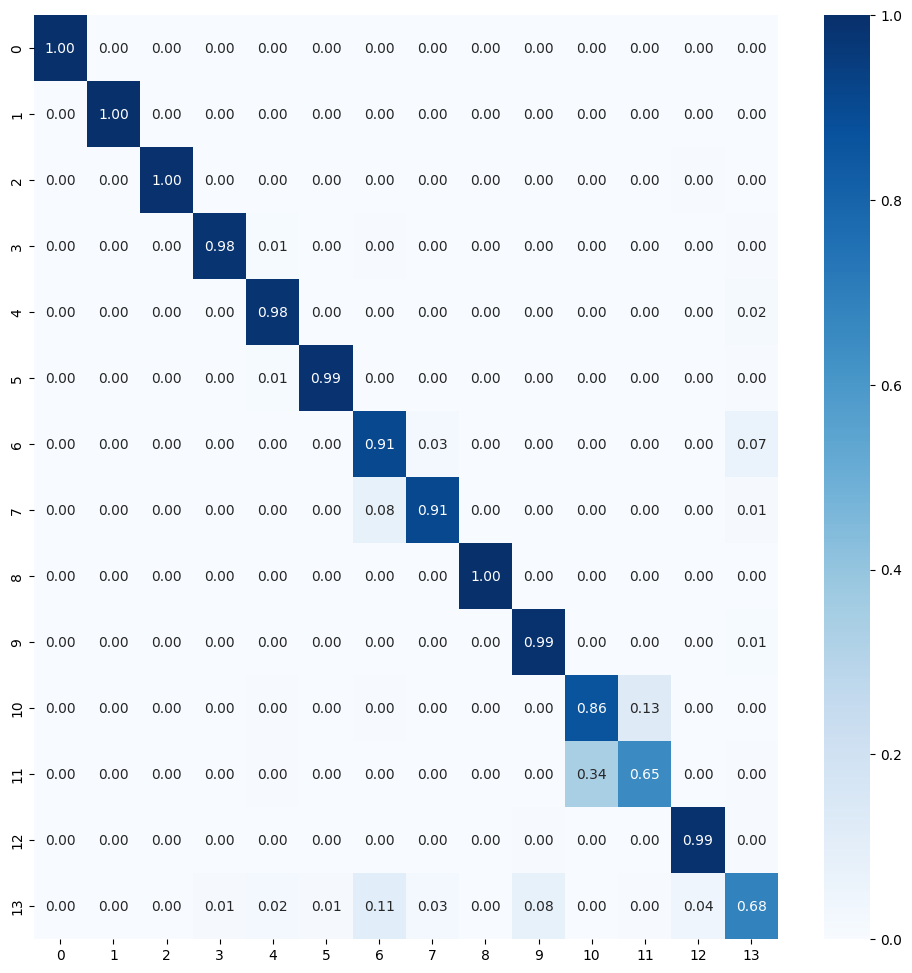


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3823182
Trainable params: 1645966
Non-trainable params: 2177216
Epoch 1/50
459/459 [==============================] - 91s 173ms/step - loss: 1.7176 - accuracy: 0.7225 - val_loss: 1.2441 - val_accuracy: 0.8364 - lr: 1.0000e-04
Epoch 2/50
459/459 [==============================] - 79s 172ms/step - loss: 1.2737 - accuracy: 0.8416 - val_loss: 1.1475 - val_accuracy: 0.8827 - lr: 1.0000e-04
Epoch 3/50
459/459 [==============================] - 80s 175ms/step - loss: 1.1675 - accuracy: 0.8641 - val_loss: 1.0898 - val_accuracy: 0.8849 - lr: 1.0000e-04
Epoch 4/50
459/459 [==============================] - 78s 170ms/step - loss: 1.0943 - accuracy: 0.8813 - val_loss: 1.0608 - val_accuracy: 0.8833 - lr: 1.0000e-04
Epoch 5/50
459/459 [==============================] - 79s 171ms/step - loss: 1.0350 - accuracy: 0.8913 - val_loss: 1.0119 - val_accuracy: 0.8970 - lr: 1.0000e-04
Epoch 6/50
459/459 [==============================] - 70s 152ms/step - los

Model and History saved...
460/460 [==============================] - 60s 131ms/step - loss: 0.1760 - accuracy: 0.9444
Train Accuracy: 0.9443537592887878
Train Log Loss: 0.17601990699768066
99/99 [==============================] - 14s 134ms/step - loss: 0.4811 - accuracy: 0.8930
Validation Accuracy: 0.8930158615112305
Validation Log Loss: 0.48110705614089966
99/99 [==============================] - 12s 125ms/step - loss: 0.4410 - accuracy: 0.9029
Test Accuracy: 0.9028571248054504
Test Log Loss: 0.4410000145435333
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[222   0   0   0   0   0   0   0   0   0   0   0   0   3]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 219   1   0   2   0   0   0   0   0   0   3]
 [  0   0  

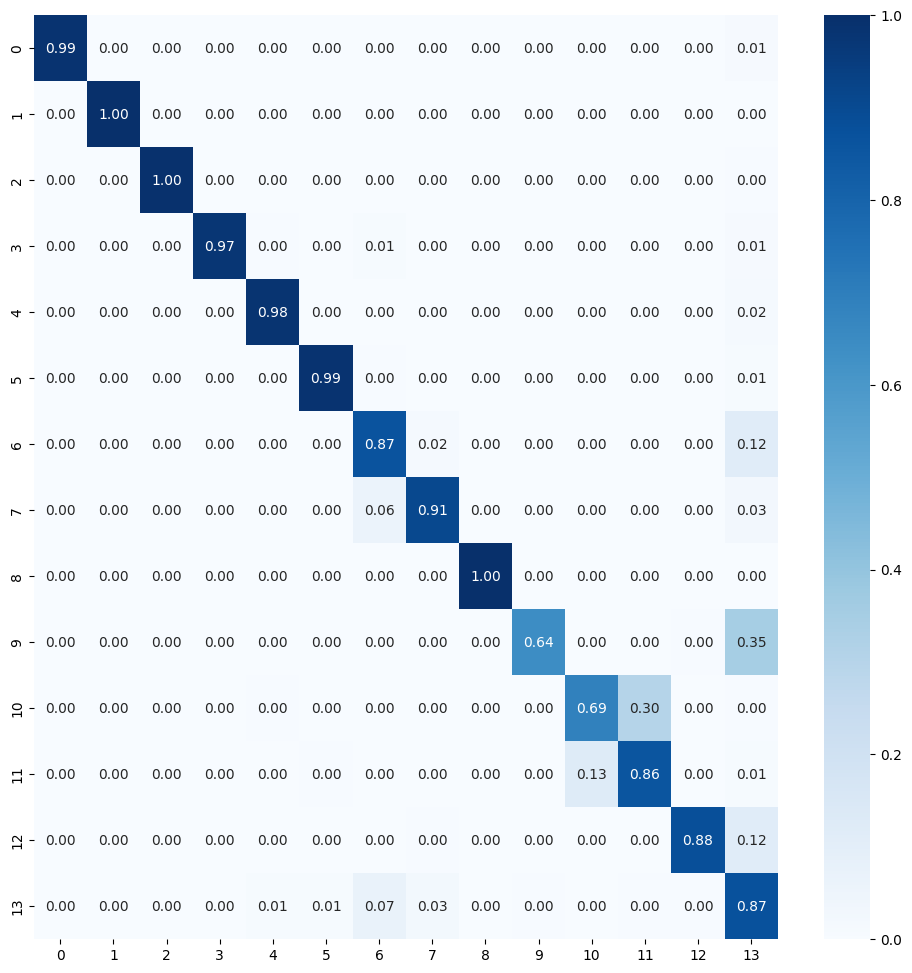


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3823182
Trainable params: 1645966
Non-trainable params: 2177216
Epoch 1/50
459/459 [==============================] - 85s 164ms/step - loss: 1.7644 - accuracy: 0.7139 - val_loss: 1.2520 - val_accuracy: 0.8559 - lr: 1.0000e-04
Epoch 2/50
459/459 [==============================] - 72s 156ms/step - loss: 1.2844 - accuracy: 0.8403 - val_loss: 1.1606 - val_accuracy: 0.8721 - lr: 1.0000e-04
Epoch 3/50
459/459 [==============================] - 82s 177ms/step - loss: 1.1821 - accuracy: 0.8632 - val_loss: 1.1031 - val_accuracy: 0.8788 - lr: 1.0000e-04
Epoch 4/50
459/459 [==============================] - 70s 153ms/step - loss: 1.1040 - accuracy: 0.8748 - val_loss: 1.0470 - val_accuracy: 0.8887 - lr: 1.0000e-04
Epoch 5/50
459/459 [==============================] - 72s 158ms/step - loss: 1.0374 - accuracy: 0.8902 - val_loss: 1.0124 - val_accuracy: 0.8951 - lr: 1.0000e-04
Epoch 6/50
459/459 [==============================] - 72s 158ms/step - los

Model and History saved...
460/460 [==============================] - 61s 132ms/step - loss: 0.1135 - accuracy: 0.9611
Train Accuracy: 0.9610884189605713
Train Log Loss: 0.11348536610603333
99/99 [==============================] - 14s 133ms/step - loss: 0.3177 - accuracy: 0.9168
Validation Accuracy: 0.9168254137039185
Validation Log Loss: 0.3176605999469757
99/99 [==============================] - 14s 127ms/step - loss: 0.2864 - accuracy: 0.9222
Test Accuracy: 0.9222221970558167
Test Log Loss: 0.28635653853416443
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 220   1   0   1   0   0   0   0   1   0   2]
 [  0   0  

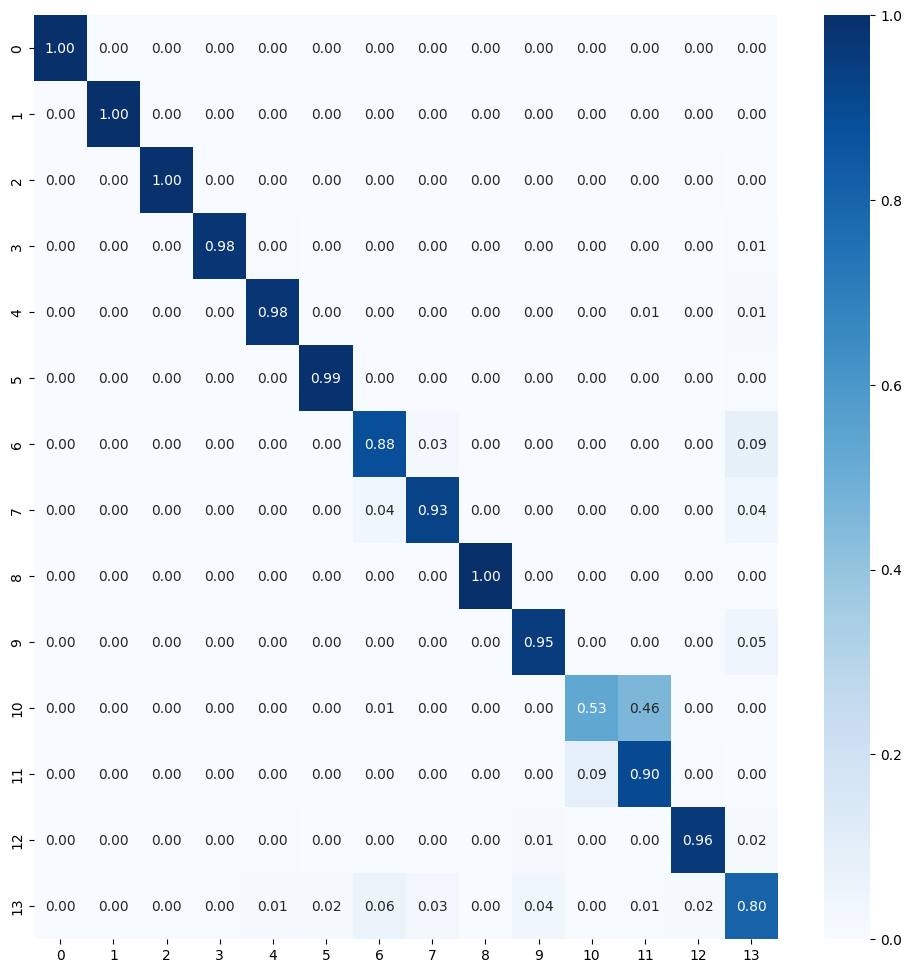


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3823182
Trainable params: 1645966
Non-trainable params: 2177216
Epoch 1/50
459/459 [==============================] - 88s 170ms/step - loss: 1.7829 - accuracy: 0.7134 - val_loss: 1.2511 - val_accuracy: 0.8434 - lr: 1.0000e-04
Epoch 2/50
459/459 [==============================] - 79s 173ms/step - loss: 1.2967 - accuracy: 0.8289 - val_loss: 1.1409 - val_accuracy: 0.8913 - lr: 1.0000e-04
Epoch 3/50
459/459 [==============================] - 74s 161ms/step - loss: 1.1798 - accuracy: 0.8605 - val_loss: 1.0935 - val_accuracy: 0.8839 - lr: 1.0000e-04
Epoch 4/50
459/459 [==============================] - 80s 172ms/step - loss: 1.1039 - accuracy: 0.8822 - val_loss: 1.0505 - val_accuracy: 0.9008 - lr: 1.0000e-04
Epoch 5/50
459/459 [==============================] - 74s 160ms/step - loss: 1.0395 - accuracy: 0.8900 - val_loss: 1.0030 - val_accuracy: 0.9056 - lr: 1.0000e-04
Epoch 6/50
459/459 [==============================] - 74s 162ms/step - los

Model and History saved...
460/460 [==============================] - 59s 127ms/step - loss: 0.1093 - accuracy: 0.9676
Train Accuracy: 0.9675509929656982
Train Log Loss: 0.10933779925107956
99/99 [==============================] - 13s 124ms/step - loss: 0.3098 - accuracy: 0.9263
Validation Accuracy: 0.9263492226600647
Validation Log Loss: 0.30984702706336975
99/99 [==============================] - 13s 129ms/step - loss: 0.2957 - accuracy: 0.9279
Test Accuracy: 0.9279364943504333
Test Log Loss: 0.29572412371635437
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 221   1   0   0   0   0   1   0   0   1   1]
 [  0   0 

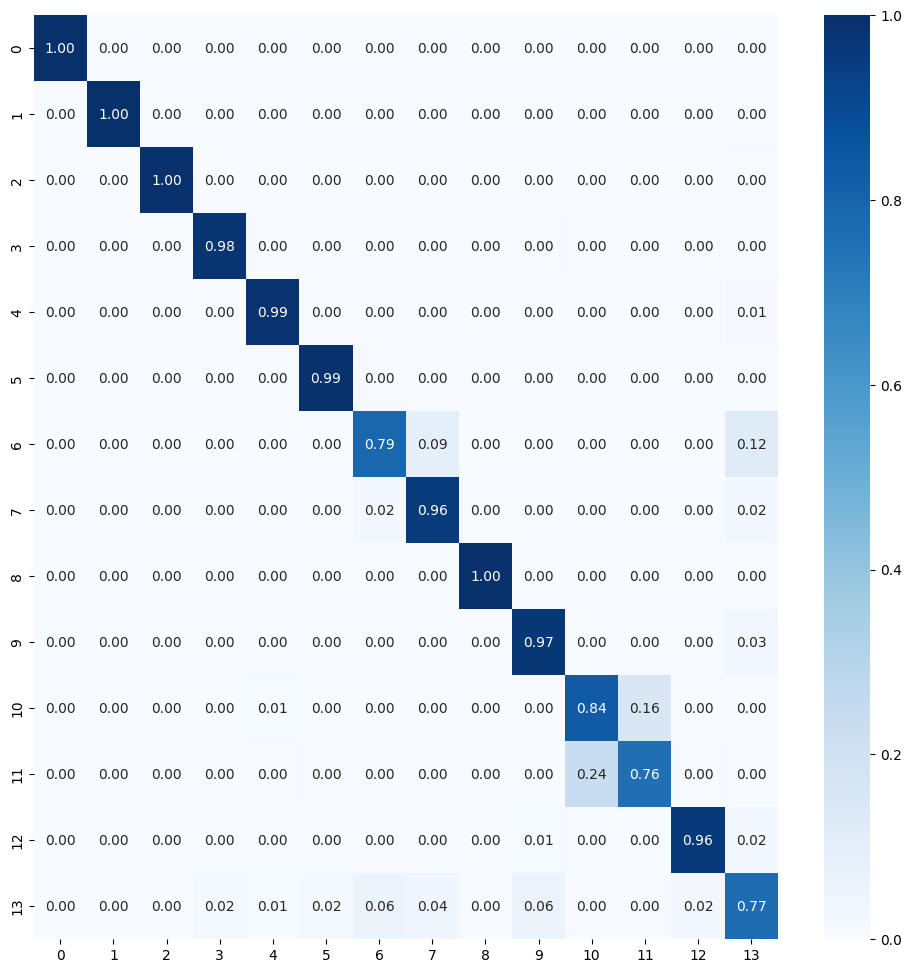

Average training accuracy in 5-fold: 0.963403332233429
Average validation precision in 5-fold: 0.9241709113121033
/nTest Metrics
test_acc_list: [0.9234920740127563, 0.9241269826889038, 0.9028571248054504, 0.9222221970558167, 0.9279364943504333]
Average Test Accuracy with 5-fold: 0.9201269745826721
test_loss_list: [0.3305320739746094, 0.32900628447532654, 0.4410000145435333, 0.28635653853416443, 0.29572412371635437]
Average Test Log Loss with 5-fold: 0.3365238070487976

Precision List: [0.9237118263578195, 0.9254019346404763, 0.9210837476242378, 0.9280191376556898, 0.9280344231479061]
Average Precision List with 5-fold: 0.9252502138852259
Recall List: [0.9234920634920636, 0.9241269841269842, 0.9028571428571429, 0.9222222222222223, 0.927936507936508]
Average Recall List with 5-fold: 0.9201269841269841
F1 Score List: [0.9226291957491205, 0.9225614393955575, 0.9057404058977345, 0.9210677033241937, 0.9273654755348167]
Average F1 Score List with 5-fold: 0.9198728439802846

Metrics List Store

In [26]:
%%time

num_classes = 14
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/15
name_save_model: fusion_MobileNet_tf_optimized 15
Found 15750 images belonging to 15 classes.
Found 3375 images belonging to 15 classes.
Found 3375 images belonging to 15 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew
- small
- upatre

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3823311
Trainable params: 1646095
Non-trainable params: 2177216
Epoch 1/50
492/492 [==============================] - 77s 145ms/step - loss: 1.7904 - accuracy: 0.7100 - val_loss: 1.2442 - val_accuracy: 0.8646 - lr: 1.0000e-04
Epoch 2/50
492/492 [==============================] - 75s 152ms/step - loss: 1.2950 - accuracy: 0.8397 - val_loss: 1.1473 - val_accuracy: 0.8815 - lr: 1.0000e-04
Epoch 3/50
492/492 [==============================] - 79s 161ms/step - loss: 1.1912 - accuracy: 0.8603 - val_loss: 1.

Model and History saved...
493/493 [==============================] - 61s 122ms/step - loss: 0.1494 - accuracy: 0.9540
Train Accuracy: 0.9539682269096375
Train Log Loss: 0.1493721902370453
106/106 [==============================] - 14s 127ms/step - loss: 0.4248 - accuracy: 0.9147
Validation Accuracy: 0.9146666526794434
Validation Log Loss: 0.4247751832008362
106/106 [==============================] - 14s 128ms/step - loss: 0.4235 - accuracy: 0.9212
Test Accuracy: 0.9211851954460144
Test Log Loss: 0.4235323369503021
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   1   0   1   0   0   1 

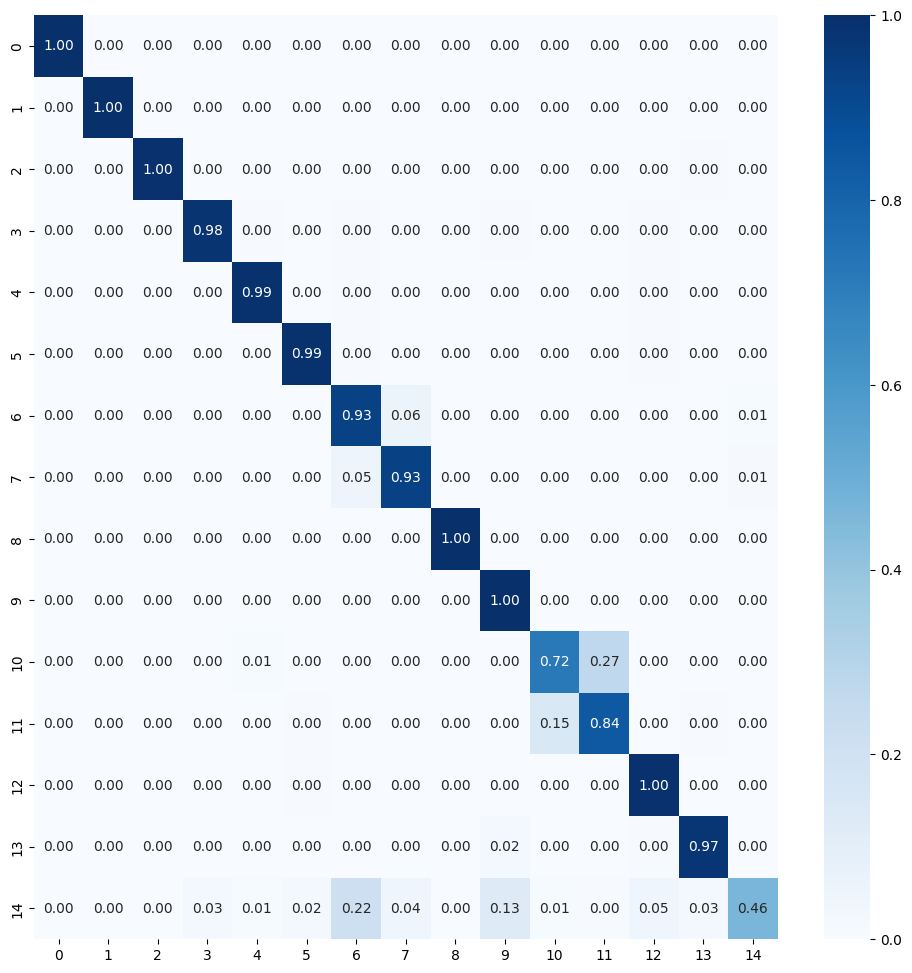


TRAINING AND EVALUATING FOLD 2/5...

Total params: 3823311
Trainable params: 1646095
Non-trainable params: 2177216
Epoch 1/50
492/492 [==============================] - 71s 126ms/step - loss: 1.7525 - accuracy: 0.7159 - val_loss: 1.2272 - val_accuracy: 0.8595 - lr: 1.0000e-04
Epoch 2/50
492/492 [==============================] - 76s 154ms/step - loss: 1.2909 - accuracy: 0.8357 - val_loss: 1.1343 - val_accuracy: 0.8929 - lr: 1.0000e-04
Epoch 3/50
492/492 [==============================] - 75s 153ms/step - loss: 1.1686 - accuracy: 0.8656 - val_loss: 1.0804 - val_accuracy: 0.8955 - lr: 1.0000e-04
Epoch 4/50
492/492 [==============================] - 77s 157ms/step - loss: 1.0971 - accuracy: 0.8817 - val_loss: 1.0421 - val_accuracy: 0.8881 - lr: 1.0000e-04
Epoch 5/50
492/492 [==============================] - 76s 153ms/step - loss: 1.0358 - accuracy: 0.8910 - val_loss: 0.9961 - val_accuracy: 0.9089 - lr: 1.0000e-04
Epoch 6/50
492/492 [==============================] - 82s 166ms/step - los

Model and History saved...
493/493 [==============================] - 60s 120ms/step - loss: 0.1175 - accuracy: 0.9582
Train Accuracy: 0.9581587314605713
Train Log Loss: 0.11753103882074356
106/106 [==============================] - 14s 125ms/step - loss: 0.3312 - accuracy: 0.9117
Validation Accuracy: 0.9117037057876587
Validation Log Loss: 0.33124738931655884
106/106 [==============================] - 13s 117ms/step - loss: 0.3204 - accuracy: 0.9141
Test Accuracy: 0.9140740633010864
Test Log Loss: 0.3203558027744293
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 220   1   0   1   0   0   

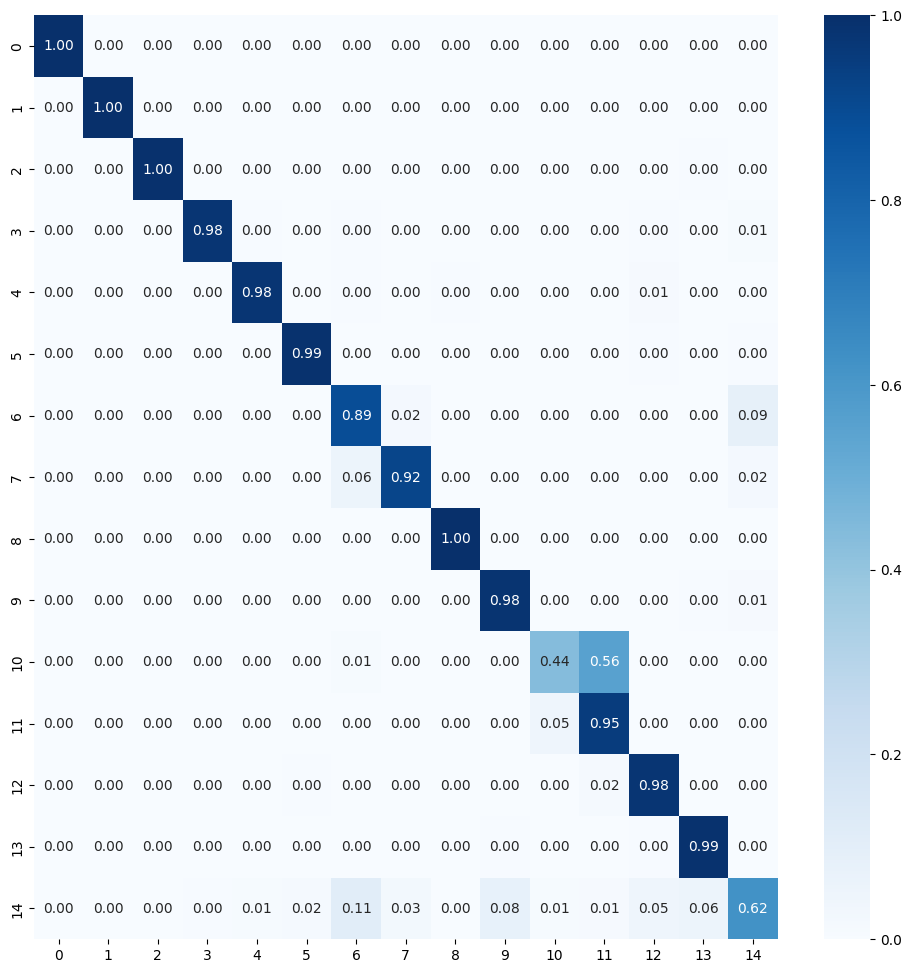


TRAINING AND EVALUATING FOLD 3/5...

Total params: 3823311
Trainable params: 1646095
Non-trainable params: 2177216
Epoch 1/50
492/492 [==============================] - 84s 152ms/step - loss: 1.7385 - accuracy: 0.7269 - val_loss: 1.2381 - val_accuracy: 0.8542 - lr: 1.0000e-04
Epoch 2/50
492/492 [==============================] - 83s 167ms/step - loss: 1.3040 - accuracy: 0.8330 - val_loss: 1.1450 - val_accuracy: 0.8878 - lr: 1.0000e-04
Epoch 3/50
492/492 [==============================] - 76s 153ms/step - loss: 1.1802 - accuracy: 0.8670 - val_loss: 1.0888 - val_accuracy: 0.8958 - lr: 1.0000e-04
Epoch 4/50
492/492 [==============================] - 75s 152ms/step - loss: 1.1071 - accuracy: 0.8791 - val_loss: 1.0553 - val_accuracy: 0.8940 - lr: 1.0000e-04
Epoch 5/50
492/492 [==============================] - 73s 148ms/step - loss: 1.0385 - accuracy: 0.8909 - val_loss: 1.0154 - val_accuracy: 0.8917 - lr: 1.0000e-04
Epoch 6/50
492/492 [==============================] - 79s 161ms/step - los

Model and History saved...
493/493 [==============================] - 59s 118ms/step - loss: 0.1633 - accuracy: 0.9474
Train Accuracy: 0.9474285840988159
Train Log Loss: 0.1633443683385849
106/106 [==============================] - 13s 120ms/step - loss: 0.4158 - accuracy: 0.9007
Validation Accuracy: 0.9007407426834106
Validation Log Loss: 0.4158322215080261
106/106 [==============================] - 13s 119ms/step - loss: 0.3960 - accuracy: 0.9043
Test Accuracy: 0.9042962789535522
Test Log Loss: 0.39604440331459045
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 219   1   0   0   0   0   0

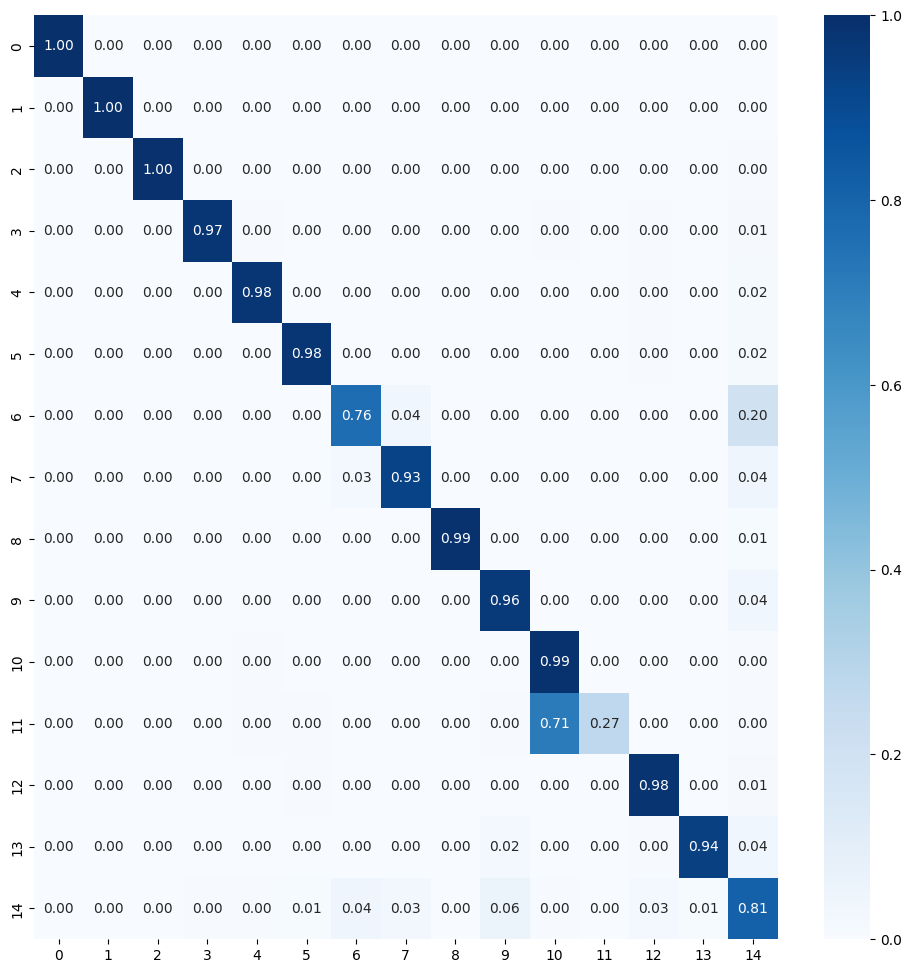


TRAINING AND EVALUATING FOLD 4/5...

Total params: 3823311
Trainable params: 1646095
Non-trainable params: 2177216
Epoch 1/50
492/492 [==============================] - 91s 165ms/step - loss: 1.7610 - accuracy: 0.7232 - val_loss: 1.2276 - val_accuracy: 0.8610 - lr: 1.0000e-04
Epoch 2/50
492/492 [==============================] - 73s 148ms/step - loss: 1.3053 - accuracy: 0.8371 - val_loss: 1.1465 - val_accuracy: 0.8857 - lr: 1.0000e-04
Epoch 3/50
492/492 [==============================] - 71s 145ms/step - loss: 1.1812 - accuracy: 0.8671 - val_loss: 1.0902 - val_accuracy: 0.8863 - lr: 1.0000e-04
Epoch 4/50
492/492 [==============================] - 76s 154ms/step - loss: 1.0979 - accuracy: 0.8815 - val_loss: 1.0444 - val_accuracy: 0.8940 - lr: 1.0000e-04
Epoch 5/50
492/492 [==============================] - 72s 147ms/step - loss: 1.0432 - accuracy: 0.8899 - val_loss: 1.0195 - val_accuracy: 0.8869 - lr: 1.0000e-04
Epoch 6/50
492/492 [==============================] - 82s 166ms/step - los

Model and History saved...
493/493 [==============================] - 64s 129ms/step - loss: 0.1206 - accuracy: 0.9497
Train Accuracy: 0.949650764465332
Train Log Loss: 0.12058381736278534
106/106 [==============================] - 14s 127ms/step - loss: 0.3197 - accuracy: 0.9058
Validation Accuracy: 0.9057777523994446
Validation Log Loss: 0.31968793272972107
106/106 [==============================] - 14s 126ms/step - loss: 0.3119 - accuracy: 0.9067
Test Accuracy: 0.9066666960716248
Test Log Loss: 0.3119439482688904
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 220   2   0   1   0   0   0

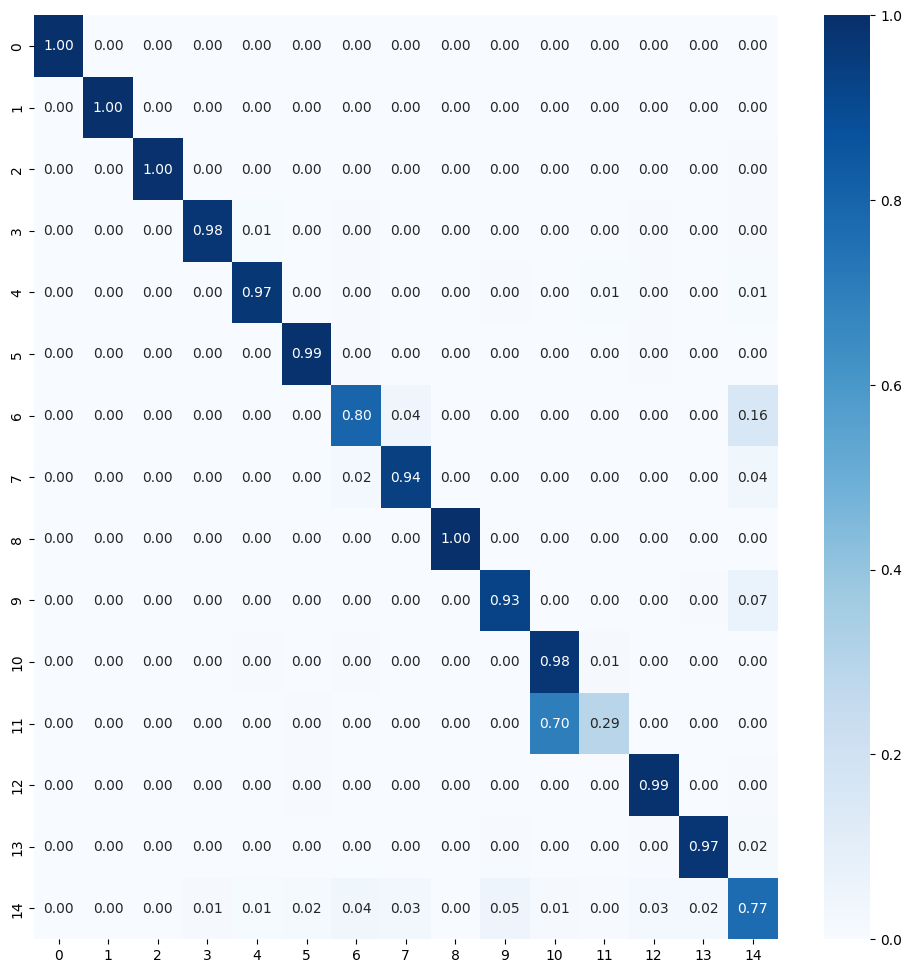


TRAINING AND EVALUATING FOLD 5/5...

Total params: 3823311
Trainable params: 1646095
Non-trainable params: 2177216
Epoch 1/50
492/492 [==============================] - 87s 157ms/step - loss: 1.7448 - accuracy: 0.7208 - val_loss: 1.2216 - val_accuracy: 0.8679 - lr: 1.0000e-04
Epoch 2/50
492/492 [==============================] - 75s 153ms/step - loss: 1.3008 - accuracy: 0.8340 - val_loss: 1.1444 - val_accuracy: 0.8729 - lr: 1.0000e-04
Epoch 3/50
492/492 [==============================] - 75s 152ms/step - loss: 1.1900 - accuracy: 0.8618 - val_loss: 1.0822 - val_accuracy: 0.8896 - lr: 1.0000e-04
Epoch 4/50
492/492 [==============================] - 76s 153ms/step - loss: 1.1056 - accuracy: 0.8764 - val_loss: 1.0474 - val_accuracy: 0.8967 - lr: 1.0000e-04
Epoch 5/50
492/492 [==============================] - 77s 157ms/step - loss: 1.0439 - accuracy: 0.8903 - val_loss: 1.0039 - val_accuracy: 0.9092 - lr: 1.0000e-04
Epoch 6/50
492/492 [==============================] - 76s 155ms/step - los

Model and History saved...
493/493 [==============================] - 80s 162ms/step - loss: 0.1358 - accuracy: 0.9500
Train Accuracy: 0.9499682784080505
Train Log Loss: 0.13584254682064056
106/106 [==============================] - 18s 170ms/step - loss: 0.3746 - accuracy: 0.9037
Validation Accuracy: 0.9037036895751953
Validation Log Loss: 0.37462982535362244
106/106 [==============================] - 18s 159ms/step - loss: 0.3577 - accuracy: 0.9073
Test Accuracy: 0.9072592854499817
Test Log Loss: 0.3577343821525574
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   1   0   0   2   0   

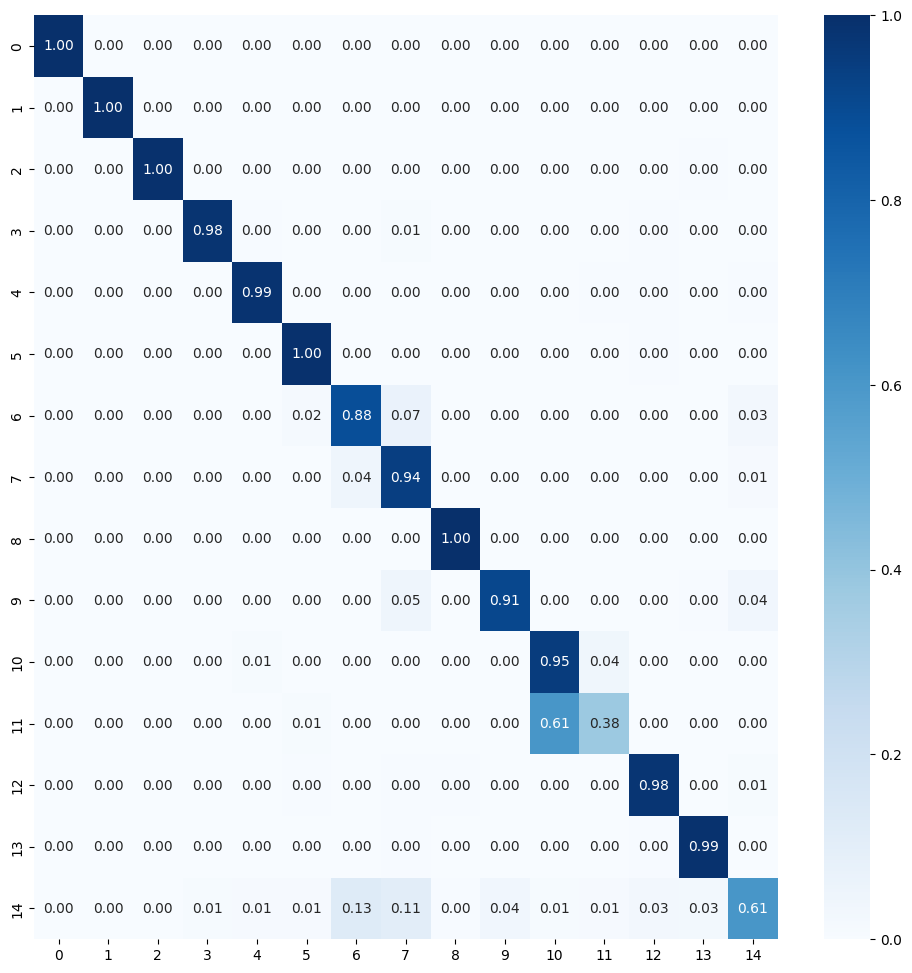

Average training accuracy in 5-fold: 0.9635195255279541
Average validation precision in 5-fold: 0.9246428489685059
/nTest Metrics
test_acc_list: [0.9211851954460144, 0.9140740633010864, 0.9042962789535522, 0.9066666960716248, 0.9072592854499817]
Average Test Accuracy with 5-fold: 0.9106963038444519
test_loss_list: [0.4235323369503021, 0.3203558027744293, 0.39604440331459045, 0.3119439482688904, 0.3577343821525574]
Average Test Log Loss with 5-fold: 0.36192217469215393

Precision List: [0.9254395807198433, 0.922521784589478, 0.9281879885399359, 0.9232398570585006, 0.9178996615616917]
Average Precision List with 5-fold: 0.92345777449389
Recall List: [0.9211851851851852, 0.9140740740740741, 0.9042962962962964, 0.9066666666666665, 0.9072592592592592]
Average Recall List with 5-fold: 0.9106962962962962
F1 Score List: [0.9162892358129028, 0.9097352645872268, 0.897712810264273, 0.9004667980466522, 0.9016724241632185]
Average F1 Score List with 5-fold: 0.9051753065748546

Metrics List Store

t

In [27]:
%%time

num_classes = 15
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

In [28]:
print(f"test_acc_list_all = {test_acc_list_all}")
print(f"test_loss_list_all = {test_loss_list_all}")
print(f"precision_list_all = {precision_list_all}")
print(f"recall_list_all = {recall_list_all}")
print(f"f1_score_list_all = {f1_score_list_all}")

test_acc_list_all = [0.9991111040115357, 1.0, 0.9973333239555359, 0.9909333467483521, 0.9933333396911621, 0.9861587405204773, 0.9951111197471618, 0.9941728591918946, 0.9705777764320374, 0.9478788018226624, 0.9516296267509461, 0.9524786353111268, 0.9201269745826721, 0.9106963038444519]
test_loss_list_all = [0.8588037371635437, 0.6821514368057251, 0.5548669539391995, 0.22283680140972137, 0.2057877227663994, 0.4608109675347805, 0.4484470523893833, 0.1362516399472952, 0.29973756670951845, 0.32093090415000913, 0.2916985750198364, 0.34960747957229615, 0.3365238070487976, 0.36192217469215393]
precision_list_all = [0.9991150442477876, 1.0, 0.9973470297732753, 0.9913406066634588, 0.9934064318560999, 0.9884382364001574, 0.9951368511412404, 0.9942829515741016, 0.9706761843286718, 0.9487936336358012, 0.9524480236788427, 0.9536989144264874, 0.9252502138852259, 0.92345777449389]
recall_list_all = [0.9991111111111112, 1.0, 0.9973333333333333, 0.9909333333333332, 0.9933333333333334, 0.9861587301587301

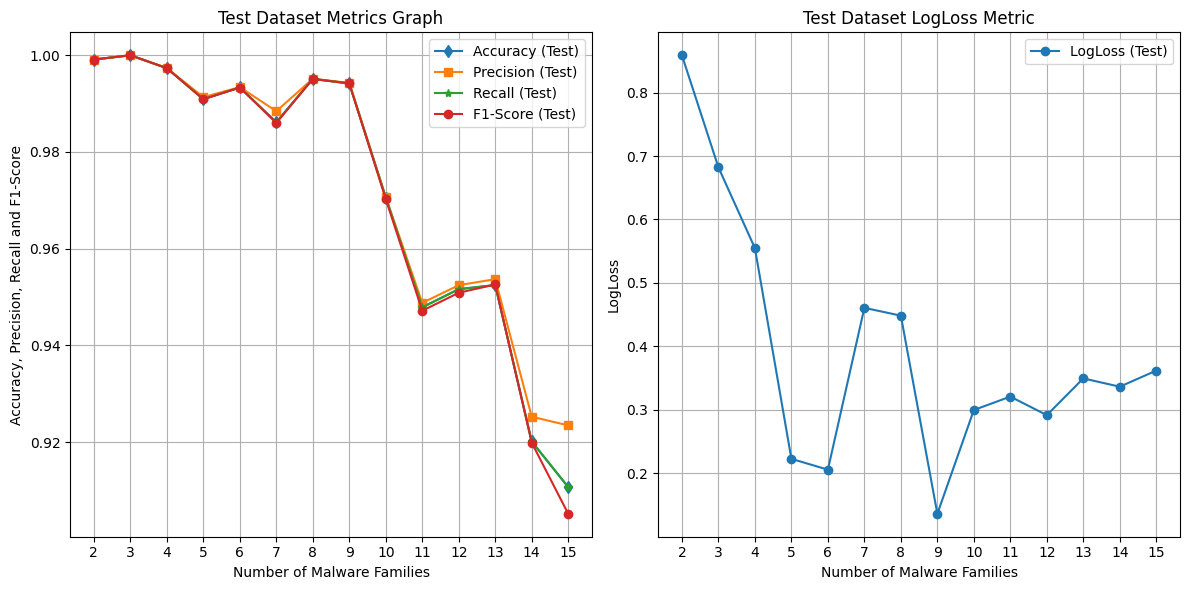

In [29]:
import matplotlib.pyplot as plt

# Datos históricos
strategies = [str(i) for i in range(2, len(test_acc_list_all) + 2)]

# Crear gráfico para Test Accuracy y Test LogLoss en una fila con dos columnas
fig, axes = plt.subplots(1, 2, figsize=(12, 6))


# Gráfico para Test Accuracy, Precision, Recall and F1-Score
axes[0].plot(strategies, test_acc_list_all, marker='d', label='Accuracy (Test)')
axes[0].plot(strategies, precision_list_all, marker='s', label='Precision (Test)')
axes[0].plot(strategies, recall_list_all, marker='*', label='Recall (Test)')
axes[0].plot(strategies, f1_score_list_all, marker='o', label='F1-Score (Test)')
axes[0].set_title('Test Dataset Metrics Graph')
axes[0].set_xlabel('Number of Malware Families')
axes[0].set_ylabel('Accuracy, Precision, Recall and F1-Score')
axes[0].legend()
axes[0].grid(True)

# Gráfico para Test LogLoss
axes[1].plot(strategies, test_loss_list_all, marker='o', label='LogLoss (Test)')
axes[1].set_title('Test Dataset LogLoss Metric')
axes[1].set_xlabel('Number of Malware Families')
axes[1].set_ylabel('LogLoss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
